# 01 - EDA y Limpieza de Datos

## 1. Validación de estructura y viabilidad del dataset


### Objetivo

Realizar una primera evaluación estructural del dataset SuperStoreOrders para determinar si posee la calidad, granularidad y variables necesarias para desarrollar los análisis del proyecto y evaluar la viabilidad de construir un sistema de recomendación.

En esta etapa se analizarán, entre otros aspectos:

- dimensiones del dataset;
- estructura y tipos de variables;
- granularidad de los registros;
- valores faltantes;
- registros duplicados;
- cobertura temporal;
- cantidad de clientes, productos y pedidos;
- historial e interacciones cliente-producto;
- variables potencialmente útiles para el sistema de recomendación.

En esta instancia no se realizarán transformaciones ni limpieza definitiva de los datos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Detectar la raíz del proyecto
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "SuperStoreOrders - SuperStoreOrders.csv"
)

print("Ruta del dataset:")
print(DATA_PATH)

print("\n¿El archivo existe?")
print(DATA_PATH.exists())

Ruta del dataset:
c:\Users\camil\OneDrive\Pictures\Desktop\Henry-PF\nexadata-superstore-recommender-eq1\data\raw\SuperStoreOrders - SuperStoreOrders.csv

¿El archivo existe?
True


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [4]:
print(f"Cantidad de filas: {df.shape[0]:,}")
print(f"Cantidad de columnas: {df.shape[1]}")

display(df.head())

Cantidad de filas: 51,290
Cantidad de columnas: 21


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [5]:
print("Columnas del dataset:\n")

for i, columna in enumerate(df.columns, start=1):
    print(f"{i:02d}. {columna}")

Columnas del dataset:

01. order_id
02. order_date
03. ship_date
04. ship_mode
05. customer_name
06. segment
07. state
08. country
09. market
10. region
11. product_id
12. category
13. sub_category
14. product_name
15. sales
16. quantity
17. discount
18. profit
19. shipping_cost
20. order_priority
21. year


## 2. Estructura, tipos de datos y granularidad


En esta sección se analiza cómo Pandas interpreta inicialmente cada variable y se evalúa
qué representa cada fila del dataset.

Comprender la granularidad es fundamental antes de realizar cualquier limpieza o
transformación, ya que permite identificar la unidad de análisis y las relaciones entre
pedidos, clientes y productos.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [7]:
estructura = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "valores_no_nulos": df.notna().sum(),
    "valores_nulos": df.isna().sum(),
    "valores_unicos": df.nunique(dropna=True)
})

display(estructura)

,tipo_dato,valores_no_nulos,valores_nulos,valores_unicos
order_id,object,51290,0,25035
order_date,object,51290,0,1430
ship_date,object,51290,0,1464
ship_mode,object,51290,0,4
customer_name,object,51290,0,795
segment,object,51290,0,3
state,object,51290,0,1094
country,object,51290,0,147
market,object,51290,0,7
region,object,51290,0,13


In [8]:
print("Entidades principales del dataset:\n")

print(f"Filas totales:            {len(df):,}")
print(f"Pedidos únicos:           {df['order_id'].nunique():,}")
print(f"Clientes únicos (nombre): {df['customer_name'].nunique():,}")
print(f"Productos únicos (ID):    {df['product_id'].nunique():,}")
print(f"Productos únicos (nombre):{df['product_name'].nunique():,}")

Entidades principales del dataset:

Filas totales:            51,290
Pedidos únicos:           25,035
Clientes únicos (nombre): 795
Productos únicos (ID):    10,292
Productos únicos (nombre):3,788


In [9]:
filas_por_pedido = df.groupby("order_id").size()

print("Cantidad de filas por pedido:\n")
display(filas_por_pedido.describe())

print(f"\nPedidos con más de una fila: {(filas_por_pedido > 1).sum():,}")
print(f"Máximo de filas en un pedido: {filas_por_pedido.max():,}")

Cantidad de filas por pedido:



count    25035.000000
mean         2.048732
std          1.469301
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         14.000000
dtype: float64


Pedidos con más de una fila: 12,778
Máximo de filas en un pedido: 14


In [10]:
duplicados_order_product = df.duplicated(
    subset=["order_id", "product_id"]
).sum()

print(
    "Filas con combinación order_id + product_id repetida:",
    f"{duplicados_order_product:,}"
)

Filas con combinación order_id + product_id repetida: 38


In [11]:
pedidos_multicliente = (
    df.groupby("order_id")["customer_name"]
      .nunique()
      .gt(1)
      .sum()
)

productos_multinombre = (
    df.groupby("product_id")["product_name"]
      .nunique()
      .gt(1)
      .sum()
)

print(f"Pedidos asociados a más de un cliente: {pedidos_multicliente:,}")
print(f"Product IDs asociados a más de un product_name: {productos_multinombre:,}")

Pedidos asociados a más de un cliente: 659
Product IDs asociados a más de un product_name: 457


### Hallazgos preliminares sobre la granularidad


La estructura observada sugiere que el dataset posee granularidad a nivel de línea de pedido:
un mismo `order_id` puede aparecer en múltiples filas correspondientes a productos incluidos
en una misma transacción.

Sin embargo, antes de confirmar esta granularidad y utilizar los identificadores para el
sistema de recomendación, se detectaron dos situaciones que requieren validación:

- existen combinaciones `order_id + product_id` repetidas;
- algunos `order_id` aparecen asociados a más de un `customer_name`;
- algunos `product_id` aparecen asociados a más de un `product_name`.

Estas situaciones serán auditadas antes de tomar decisiones de limpieza o modelado.

In [12]:
auditoria_pedidos = (
    df.groupby("order_id")
      .agg(
          clientes=("customer_name", "nunique"),
          mercados=("market", "nunique"),
          paises=("country", "nunique"),
          fechas=("order_date", "nunique"),
          filas=("order_id", "size")
      )
)

pedidos_problematicos = (
    auditoria_pedidos[auditoria_pedidos["clientes"] > 1]
    .sort_values(["clientes", "filas"], ascending=False)
)

display(pedidos_problematicos.head(10))

,clientes,mercados,paises,fechas,filas
order_id,,,,,
IT-2014-1036058,4,1,1,4,8
ES-2014-4717877,4,1,1,4,7
ES-2014-3566095,4,1,1,4,6
ES-2013-4477863,4,1,1,4,4
ES-2012-5776825,3,1,1,3,12
ES-2013-2700361,3,1,1,3,11
ES-2011-2075610,3,1,2,3,10
ES-2013-3575875,3,1,1,3,10
IT-2014-4652290,3,1,1,3,10


In [13]:
ids_pedidos_problematicos = pedidos_problematicos.head(5).index

columnas_revision = [
    "order_id",
    "order_date",
    "customer_name",
    "country",
    "market",
    "region",
    "product_id",
    "product_name"
]

display(
    df[df["order_id"].isin(ids_pedidos_problematicos)]
    [columnas_revision]
    .sort_values(["order_id", "customer_name"])
)

,order_id,order_date,customer_name,country,market,region,product_id,product_name
15399,ES-2012-5776825,11/9/2012,Penelope Sewall,Germany,EU,Central,OFF-AR-10002382,"Binney & Smith Pencil Sharpener, Water Color"
15411,ES-2012-5776825,11/9/2012,Penelope Sewall,Germany,EU,Central,OFF-ST-10002354,"Eldon Lockers, Wire Frame"
15420,ES-2012-5776825,11/9/2012,Penelope Sewall,Germany,EU,Central,FUR-FU-10002017,"Rubbermaid Door Stop, Duo Pack"
15436,ES-2012-5776825,11/9/2012,Penelope Sewall,Germany,EU,Central,OFF-BI-10003320,"Cardinal Hole Reinforcements, Recycled"
12622,ES-2012-5776825,14/06/2012,Tom Ashbrook,Germany,EU,Central,TEC-PH-10003492,"Cisco Audio Dock, Full Size"
12623,ES-2012-5776825,14/06/2012,Tom Ashbrook,Germany,EU,Central,TEC-PH-10002079,"Motorola Headset, with Caller ID"
12628,ES-2012-5776825,14/06/2012,Tom Ashbrook,Germany,EU,Central,OFF-ST-10004739,"Rogers Folders, Industrial"
12635,ES-2012-5776825,14/06/2012,Tom Ashbrook,Germany,EU,Central,OFF-LA-10004753,"Novimex Round Labels, Laser Printer Compatible"
12640,ES-2012-5776825,14/06/2012,Tom Ashbrook,Germany,EU,Central,OFF-FA-10002047,"Stockwell Push Pins, Bulk Pack"
13192,ES-2012-5776825,29/06/2012,Troy Staebel,Germany,EU,Central,TEC-CO-10004089,"Canon Copy Machine, Laser"


In [14]:
criterios_pedido = {
    "order_id": ["order_id"],
    "order_id + market": ["order_id", "market"],
    "order_id + country": ["order_id", "country"],
    "order_id + order_date": ["order_id", "order_date"],
}

print("Grupos asociados a más de un cliente:\n")

for nombre, columnas in criterios_pedido.items():
    cantidad = (
        df.groupby(columnas)["customer_name"]
          .nunique()
          .gt(1)
          .sum()
    )
    
    print(f"{nombre:<25}: {cantidad:,}")

Grupos asociados a más de un cliente:

order_id                 : 659
order_id + market        : 622
order_id + country       : 606
order_id + order_date    : 2


In [15]:
auditoria_productos = (
    df.groupby("product_id")
      .agg(
          nombres=("product_name", "nunique"),
          categorias=("category", "nunique"),
          subcategorias=("sub_category", "nunique"),
          mercados=("market", "nunique"),
          filas=("product_id", "size")
      )
)

productos_problematicos = (
    auditoria_productos[auditoria_productos["nombres"] > 1]
    .sort_values(["nombres", "filas"], ascending=False)
)

display(productos_problematicos.head(10))

,nombres,categorias,subcategorias,mercados,filas
product_id,,,,,
OFF-PA-10004673,4,1,1,1,9
OFF-AR-10003651,3,1,1,2,35
OFF-AR-10003829,3,1,1,3,31
OFF-BI-10002799,3,1,1,3,30
OFF-BI-10003708,3,1,1,2,30
OFF-BI-10004632,3,1,1,2,24
OFF-BI-10004654,3,1,1,2,22
OFF-AR-10000833,3,1,1,2,19
OFF-PA-10000357,3,1,1,2,16


In [16]:
ids_productos_problematicos = productos_problematicos.head(5).index

columnas_revision_producto = [
    "product_id",
    "product_name",
    "category",
    "sub_category",
    "market",
    "country"
]

display(
    df[df["product_id"].isin(ids_productos_problematicos)]
    [columnas_revision_producto]
    .drop_duplicates()
    .sort_values(["product_id", "product_name"])
)

,product_id,product_name,category,sub_category,market,country
2018,OFF-AR-10003651,Newell 350,Office Supplies,Art,US,United States
3172,OFF-AR-10003651,"Sanford Pencil Sharpener, Easy-Erase",Office Supplies,Art,EU,Germany
5381,OFF-AR-10003651,"Sanford Pencil Sharpener, Easy-Erase",Office Supplies,Art,EU,United Kingdom
7630,OFF-AR-10003651,"Sanford Pencil Sharpener, Easy-Erase",Office Supplies,Art,EU,Netherlands
10878,OFF-AR-10003651,"Sanford Pencil Sharpener, Easy-Erase",Office Supplies,Art,EU,France
14371,OFF-AR-10003651,"Sanford Pencil Sharpener, Easy-Erase",Office Supplies,Art,EU,Switzerland
19724,OFF-AR-10003651,"Sanford Pencil Sharpener, Easy-Erase",Office Supplies,Art,EU,Ireland
20322,OFF-AR-10003651,"Sanford Pencil Sharpener, Easy-Erase",Office Supplies,Art,EU,Austria
20888,OFF-AR-10003651,"Sanford Pencil Sharpener, Easy-Erase",Office Supplies,Art,EU,Spain
1337,OFF-AR-10003651,"Sanford Pens, Easy-Erase",Office Supplies,Art,EU,United Kingdom


In [17]:
pares_repetidos = df[
    df.duplicated(
        subset=["order_id", "product_id"],
        keep=False
    )
].sort_values(["order_id", "product_id"])

print(f"Filas involucradas en pares repetidos: {len(pares_repetidos):,}")

display(
    pares_repetidos[
        [
            "order_id",
            "customer_name",
            "product_id",
            "product_name",
            "quantity",
            "sales",
            "discount",
            "profit"
        ]
    ].head(50)
)

Filas involucradas en pares repetidos: 76


,order_id,customer_name,product_id,product_name,quantity,sales,discount,profit
42781,AG-2014-4840,Cynthia Delaney,TEC-MEM-10002524,"Memorex Mouse, USB",2,57,0.00,10.7400
42791,AG-2014-4840,Cynthia Delaney,TEC-MEM-10002524,"Memorex Mouse, USB",2,57,0.00,10.7400
13753,CA-2012-103135,Shirley Schmidt,OFF-BI-10000069,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",6,90,0.00,41.4276
13758,CA-2012-103135,Shirley Schmidt,OFF-BI-10000069,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",9,135,0.00,62.1414
27808,CA-2013-129714,Adam Bellavance,OFF-PA-10001970,Xerox 1881,2,25,0.00,11.5432
27810,CA-2013-129714,Adam Bellavance,OFF-PA-10001970,Xerox 1881,4,49,0.00,23.0864
33350,CA-2013-137043,Logan Currie,FUR-FU-10003664,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",6,573,0.00,166.1004
33353,CA-2013-137043,Logan Currie,FUR-FU-10003664,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",3,286,0.00,83.0502
21689,CA-2013-140571,Sanjit Jacobs,OFF-PA-10001954,Xerox 1964,14,320,0.00,147.0896
21694,CA-2013-140571,Sanjit Jacobs,OFF-PA-10001954,Xerox 1964,2,46,0.00,21.0128


In [18]:
pedidos_fecha_multicliente = (
    df.groupby(["order_id", "order_date"])["customer_name"]
      .nunique()
)

pedidos_fecha_multicliente = pedidos_fecha_multicliente[
    pedidos_fecha_multicliente > 1
]

display(pedidos_fecha_multicliente)

order_id         order_date
ES-2014-4794612  3/12/2014     2
ES-2014-5886915  9/8/2014      2
Name: customer_name, dtype: int64

In [19]:
claves_problematicas = pedidos_fecha_multicliente.index.tolist()

mask = pd.Series(False, index=df.index)

for order_id, order_date in claves_problematicas:
    mask |= (
        (df["order_id"] == order_id)
        & (df["order_date"] == order_date)
    )

display(
    df.loc[
        mask,
        [
            "order_id",
            "order_date",
            "customer_name",
            "country",
            "market",
            "region",
            "product_id",
            "product_name",
        ],
    ].sort_values(["order_id", "order_date", "customer_name"])
)

,order_id,order_date,customer_name,country,market,region,product_id,product_name
49339,ES-2014-4794612,3/12/2014,Bill Tyler,France,EU,Central,OFF-ST-10004695,"Fellowes File Cart, Blue"
49344,ES-2014-4794612,3/12/2014,Bill Tyler,France,EU,Central,OFF-SU-10001889,"Kleencut Letter Opener, Easy Grip"
49364,ES-2014-4794612,3/12/2014,Bill Tyler,France,EU,Central,OFF-AR-10000711,"BIC Pens, Easy-Erase"
49395,ES-2014-4794612,3/12/2014,Bill Tyler,France,EU,Central,OFF-BI-10004722,"Avery Index Tab, Clear"
49396,ES-2014-4794612,3/12/2014,Bill Tyler,France,EU,Central,OFF-FA-10001551,"Stockwell Thumb Tacks, 12 Pack"
49335,ES-2014-4794612,3/12/2014,John Castell,France,EU,Central,OFF-SU-10000906,"Fiskars Shears, High Speed"
42154,ES-2014-5886915,9/8/2014,Bobby Elias,Spain,EU,South,TEC-PH-10001070,"Samsung Headset, VoIP"
42158,ES-2014-5886915,9/8/2014,Bobby Elias,Spain,EU,South,TEC-PH-10004241,"Cisco Headset, Cordless"
42161,ES-2014-5886915,9/8/2014,Bobby Elias,Spain,EU,South,OFF-AP-10000802,"Hoover Microwave, White"
42173,ES-2014-5886915,9/8/2014,Dorothy Dickinson,Spain,EU,South,TEC-MA-10003261,"Panasonic Phone, Durable"


In [20]:
duplicados_exactos = df.duplicated().sum()

print(f"Duplicados exactos: {duplicados_exactos:,}")
print(f"Porcentaje sobre el dataset: {duplicados_exactos / len(df) * 100:.4f}%")

Duplicados exactos: 0
Porcentaje sobre el dataset: 0.0000%


In [21]:
filas_duplicadas_exactas = df[
    df.duplicated(keep=False)
].sort_values(list(df.columns))

print(
    f"Filas involucradas en duplicados exactos: "
    f"{len(filas_duplicadas_exactas):,}"
)

display(filas_duplicadas_exactas.head(30))

Filas involucradas en duplicados exactos: 0


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year


In [22]:
nombres_multi_id = (
    df.groupby("product_name")["product_id"]
      .nunique()
)

print(
    "Product names asociados a más de un product_id:",
    f"{(nombres_multi_id > 1).sum():,}"
)

print(
    "Máximo de product_id asociados a un mismo product_name:",
    f"{nombres_multi_id.max():,}"
)

Product names asociados a más de un product_id: 1,944
Máximo de product_id asociados a un mismo product_name: 46


In [23]:
display(
    nombres_multi_id[nombres_multi_id > 1]
    .sort_values(ascending=False)
    .head(20)
)

product_name
Staples                                   46
Stockwell Paper Clips, Assorted Sizes     16
Acco Index Tab, Clear                     12
Stockwell Push Pins, 12 Pack              11
Stockwell Thumb Tacks, Metal              11
Bush Stackable Bookrack, Pine             11
Stockwell Rubber Bands, Assorted Sizes    10
Stockwell Clamps, Assorted Sizes          10
Stockwell Clamps, Bulk Pack               10
Stockwell Thumb Tacks, 12 Pack            10
Avery Index Tab, Clear                    10
Motorola Smart Phone, Full Size           10
Smead File Cart, Single Width             10
Stiletto Letter Opener, Easy Grip         10
Boston Pencil Sharpener, Water Color      10
Fiskars Letter Opener, Easy Grip          10
Hewlett Copy Machine, Color               10
HP Copy Machine, Color                    10
Stockwell Clamps, 12 Pack                 10
Brother Copy Machine, Color               10
Name: product_id, dtype: int64

In [24]:
criterios_producto = {
    "product_id": ["product_id"],
    "product_id + market": ["product_id", "market"],
    "product_id + country": ["product_id", "country"],
    "product_id + market + product_name": [
        "product_id",
        "market",
        "product_name"
    ],
}

print("Grupos asociados a más de un product_name:\n")

for nombre, columnas in criterios_producto.items():
    cantidad = (
        df.groupby(columnas)["product_name"]
          .nunique()
          .gt(1)
          .sum()
    )

    print(f"{nombre:<35}: {cantidad:,}")

Grupos asociados a más de un product_name:

product_id                         : 457
product_id + market                : 137
product_id + country               : 148
product_id + market + product_name : 0


### Conclusiones de la auditoría de identificadores


La auditoría reveló que los identificadores disponibles no poseen unicidad global estricta.

- `order_id` aparece asociado a múltiples clientes.
- La combinación `order_id + order_date` reduce considerablemente las inconsistencias,
  aunque persisten dos casos asociados a clientes diferentes.
- No se encontraron duplicados exactos en las 21 variables del dataset.
- `product_id` no identifica de manera inequívoca un producto: 457 IDs se encuentran
  asociados a más de un `product_name`.
- La incorporación de `market` o `country` reduce, pero no elimina, esta inconsistencia.
- En sentido inverso, 1.944 nombres de producto aparecen asociados a múltiples
  `product_id`, con un máximo de 46 IDs para un mismo nombre.

Por lo tanto, no se realizarán eliminaciones ni se utilizarán estos identificadores como claves globales hasta completar la auditoría de clientes y productos.

## 3. Auditoría de identidad de clientes

El dataset no dispone de un identificador explícito `customer_id`; únicamente contiene
`customer_name`.

Dado que un sistema de recomendación necesita distinguir usuarios de forma consistente, se evaluará si `customer_name` puede utilizarse como identificador aproximado o si existen indicios de homónimos o reutilización del mismo nombre en diferentes contextos geográficos.

In [25]:
auditoria_clientes = (
    df.groupby("customer_name")
      .agg(
          pedidos=("order_id", "nunique"),
          fechas=("order_date", "nunique"),
          paises=("country", "nunique"),
          mercados=("market", "nunique"),
          regiones=("region", "nunique"),
          estados=("state", "nunique"),
          productos=("product_name", "nunique"),
          filas=("customer_name", "size")
      )
)

display(auditoria_clientes.head())

,pedidos,fechas,paises,mercados,regiones,estados,productos,filas
customer_name,,,,,,,,
Aaron Bergman,37,37,22,6,10,36,85,89
Aaron Hawkins,34,34,22,6,11,29,56,56
Aaron Smayling,31,31,17,6,9,28,59,60
Adam Bellavance,41,39,26,6,11,39,67,68
Adam Hart,42,40,21,7,13,38,82,84


In [26]:
print("Auditoría geográfica de customer_name:\n")

print(
    f"Nombres asociados a más de un país: "
    f"{(auditoria_clientes['paises'] > 1).sum():,}"
)

print(
    f"Nombres asociados a más de un market: "
    f"{(auditoria_clientes['mercados'] > 1).sum():,}"
)

print(
    f"Nombres asociados a más de una región: "
    f"{(auditoria_clientes['regiones'] > 1).sum():,}"
)

print(
    f"Máximo de países para un mismo nombre: "
    f"{auditoria_clientes['paises'].max():,}"
)

print(
    f"Máximo de mercados para un mismo nombre: "
    f"{auditoria_clientes['mercados'].max():,}"
)

Auditoría geográfica de customer_name:

Nombres asociados a más de un país: 795
Nombres asociados a más de un market: 795
Nombres asociados a más de una región: 795
Máximo de países para un mismo nombre: 32
Máximo de mercados para un mismo nombre: 7


In [27]:
clientes_multigeografia = (
    auditoria_clientes[
        (auditoria_clientes["paises"] > 1)
        | (auditoria_clientes["mercados"] > 1)
    ]
    .sort_values(
        ["paises", "mercados", "filas"],
        ascending=False
    )
)

display(clientes_multigeografia.head(15))

,pedidos,fechas,paises,mercados,regiones,estados,productos,filas
customer_name,,,,,,,,
Art Ferguson,45,45,32,7,13,41,96,98
Kristen Hastings,46,45,31,7,13,40,86,88
Trudy Glocke,42,41,30,7,11,39,74,75
Bruce Degenhardt,43,43,30,6,11,40,76,76
Jennifer Halladay,40,39,29,7,13,36,76,78
Larry Blacks,36,35,29,7,10,35,59,63
Maxwell Schwartz,42,41,29,6,12,39,71,73
Greg Hansen,38,37,28,7,11,34,63,65
Carl Ludwig,40,39,28,7,13,39,58,60


In [28]:
nombres_revision = clientes_multigeografia.head(5).index

display(
    df[df["customer_name"].isin(nombres_revision)]
    [
        [
            "customer_name",
            "order_id",
            "order_date",
            "country",
            "market",
            "region",
            "state"
        ]
    ]
    .drop_duplicates()
    .sort_values(["customer_name", "country", "order_date"])
)

,customer_name,order_id,order_date,country,market,region,state
9697,Art Ferguson,ID-2012-77080,13/02/2012,Australia,APAC,Oceania,New South Wales
4810,Art Ferguson,IN-2011-11602,2/9/2011,Australia,APAC,Oceania,New South Wales
50786,Art Ferguson,ID-2014-66181,25/12/2014,Australia,APAC,Oceania,Western Australia
13317,Art Ferguson,ID-2012-84171,3/7/2012,Australia,APAC,Oceania,Queensland
10215,Art Ferguson,MX-2012-151036,14/03/2012,Barbados,LATAM,Caribbean,Saint Michael
...,...,...,...,...,...,...,...
31640,Trudy Glocke,ES-2013-2548559,21/11/2013,United Kingdom,EU,North,England
15711,Trudy Glocke,CA-2012-149713,18/09/2012,United States,US,West,California
1324,Trudy Glocke,CA-2011-130428,31/03/2011,United States,US,South,Florida
43857,Trudy Glocke,CA-2014-128783,8/9/2014,United States,US,Central,Missouri


In [29]:
clave_transaccion = [
    "order_id",
    "order_date",
    "customer_name"
]

consistencia_transaccion = (
    df.groupby(clave_transaccion)
      .agg(
          paises=("country", "nunique"),
          mercados=("market", "nunique"),
          regiones=("region", "nunique"),
          fechas_envio=("ship_date", "nunique"),
          filas=("order_id", "size")
      )
)

print("Posibles inconsistencias en la clave candidata:\n")

print(
    "Transacciones asociadas a más de un país:",
    f"{(consistencia_transaccion['paises'] > 1).sum():,}"
)

print(
    "Transacciones asociadas a más de un market:",
    f"{(consistencia_transaccion['mercados'] > 1).sum():,}"
)

print(
    "Transacciones asociadas a más de una región:",
    f"{(consistencia_transaccion['regiones'] > 1).sum():,}"
)

print(
    "Transacciones con más de una ship_date:",
    f"{(consistencia_transaccion['fechas_envio'] > 1).sum():,}"
)

Posibles inconsistencias en la clave candidata:

Transacciones asociadas a más de un país: 0
Transacciones asociadas a más de un market: 0
Transacciones asociadas a más de una región: 0
Transacciones con más de una ship_date: 0


### Conclusiones de la auditoría de clientes


El dataset no dispone de un identificador único de cliente (`customer_id`).

La variable `customer_name` tampoco puede considerarse un identificador global confiable:
los 795 nombres presentes en el dataset aparecen asociados a múltiples países, mercados
y regiones.

Por este motivo, `customer_name` no será utilizado de forma aislada como identificador
de usuario para construir un sistema de recomendación personalizado.

Por otra parte, la combinación:

`order_id + order_date + customer_name`

mostró consistencia transaccional: no se encontraron grupos asociados simultáneamente
a múltiples países, mercados, regiones o fechas de envío.

Esta combinación se considera, de forma provisional, una clave compuesta adecuada para
representar una transacción durante los análisis posteriores.

In [30]:
# Comparar posibles claves de cliente

criterios_cliente = {
    "customer_name": [
        "customer_name"
    ],
    "customer_name + market": [
        "customer_name",
        "market"
    ],
    "customer_name + country": [
        "customer_name",
        "country"
    ],
    "customer_name + country + state": [
        "customer_name",
        "country",
        "state"
    ],
}

print("Cantidad de entidades según definición de cliente:\n")

for nombre, columnas in criterios_cliente.items():
    cantidad = df[columnas].drop_duplicates().shape[0]
    print(f"{nombre:<35}: {cantidad:,}")

Cantidad de entidades según definición de cliente:

customer_name                      : 795
customer_name + market             : 4,872
customer_name + country            : 15,700
customer_name + country + state    : 23,361


In [31]:
df_auditoria = df.copy()

df_auditoria["transaction_key"] = (
    df_auditoria["order_id"].astype(str)
    + "|"
    + df_auditoria["order_date"].astype(str)
    + "|"
    + df_auditoria["customer_name"].astype(str)
)

In [32]:
def resumen_historial(columnas):
    historial = (
        df_auditoria.groupby(columnas)["transaction_key"]
        .nunique()
    )

    return {
        "entidades": len(historial),
        "media_pedidos": historial.mean(),
        "mediana_pedidos": historial.median(),
        "min_pedidos": historial.min(),
        "max_pedidos": historial.max(),
        "con_2_o_mas": (historial >= 2).sum(),
        "con_5_o_mas": (historial >= 5).sum()
    }


resultados_cliente = []

for nombre, columnas in criterios_cliente.items():
    resumen = resumen_historial(columnas)
    resumen["definicion"] = nombre
    resultados_cliente.append(resumen)

resumen_clientes = pd.DataFrame(resultados_cliente).set_index("definicion")

display(resumen_clientes.round(2))

,entidades,media_pedidos,mediana_pedidos,min_pedidos,max_pedidos,con_2_o_mas,con_5_o_mas
definicion,,,,,,,
customer_name,795,32.39,32.0,15,47,795,795
customer_name + market,4872,5.29,5.0,1,18,4447,2766
customer_name + country,15700,1.64,1.0,1,17,4772,711
customer_name + country + state,23361,1.10,1.0,1,6,2024,5


In [33]:
historial_nombre_pais = (
    df_auditoria
    .groupby(["customer_name", "country"])["transaction_key"]
    .nunique()
)

display(historial_nombre_pais.describe())

count    15700.000000
mean         1.640382
std          1.430684
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         17.000000
Name: transaction_key, dtype: float64

In [34]:
print(
    "Clientes nombre+país con una sola transacción:",
    f"{(historial_nombre_pais == 1).sum():,}"
)

print(
    "Clientes nombre+país con 2 o más transacciones:",
    f"{(historial_nombre_pais >= 2).sum():,}"
)

print(
    "Clientes nombre+país con 5 o más transacciones:",
    f"{(historial_nombre_pais >= 5).sum():,}"
)

Clientes nombre+país con una sola transacción: 10,928
Clientes nombre+país con 2 o más transacciones: 4,772
Clientes nombre+país con 5 o más transacciones: 711


### Evaluación de posibles identificadores de cliente


Se evaluaron distintas combinaciones para representar la identidad del cliente.

El uso exclusivo de `customer_name` proporciona un historial amplio, pero no resulta
confiable debido a la reutilización de los mismos nombres en múltiples geografías.

Al incrementar la especificidad geográfica se observa una pérdida significativa de
historial:

- `customer_name + country`: 15.700 entidades, con una mediana de 1 transacción.
  Aproximadamente el 69,6 % registra una única transacción.
- `customer_name + country + state`: 23.361 entidades, también con una mediana
  de 1 transacción.

La combinación `customer_name + market` presenta un mejor equilibrio:

- 4.872 entidades;
- media de 5,29 transacciones;
- mediana de 5 transacciones;
- aproximadamente el 91,3 % posee al menos 2 transacciones;
- aproximadamente el 56,8 % posee al menos 5 transacciones.

Por lo tanto, `customer_name + market` se conservará como posible identificador
proxy para experimentación.

No obstante, esta combinación no equivale a un `customer_id` real y deberá
considerarse una limitación del dataset al interpretar recomendaciones personalizadas.

In [35]:
df_auditoria["customer_proxy"] = (
    df_auditoria["customer_name"].astype(str)
    + "|"
    + df_auditoria["market"].astype(str)
)

df_auditoria["item_id_name"] = (
    df_auditoria["product_id"].astype(str)
    + "|"
    + df_auditoria["product_name"].astype(str)
)

print("Variables auxiliares creadas para auditoría.")

Variables auxiliares creadas para auditoría.


In [36]:
print(
    "Transacciones únicas según clave compuesta:",
    f"{df_auditoria['transaction_key'].nunique():,}"
)

print(
    "Order IDs únicos originales:",
    f"{df_auditoria['order_id'].nunique():,}"
)

Transacciones únicas según clave compuesta: 25,754
Order IDs únicos originales: 25,035


In [37]:
productos_por_transaccion = (
    df_auditoria
    .groupby("transaction_key")["item_id_name"]
    .nunique()
)

display(productos_por_transaccion.describe())

count    25754.000000
mean         1.990254
std          1.405684
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         14.000000
Name: item_id_name, dtype: float64

In [38]:
print(
    "Transacciones con un solo producto:",
    f"{(productos_por_transaccion == 1).sum():,}"
)

print(
    "Transacciones con 2 o más productos:",
    f"{(productos_por_transaccion >= 2).sum():,}"
)

print(
    "Transacciones con 3 o más productos:",
    f"{(productos_por_transaccion >= 3).sum():,}"
)

print(
    "Máximo de productos distintos en una transacción:",
    f"{productos_por_transaccion.max():,}"
)

Transacciones con un solo producto: 12,970
Transacciones con 2 o más productos: 12,784
Transacciones con 3 o más productos: 6,399
Máximo de productos distintos en una transacción: 14


In [39]:
productos_por_cliente_proxy = (
    df_auditoria
    .groupby("customer_proxy")["item_id_name"]
    .nunique()
)

display(productos_por_cliente_proxy.describe())

count    4872.000000
mean       10.487069
std         6.519260
min         1.000000
25%         5.000000
50%        10.000000
75%        14.000000
max        40.000000
Name: item_id_name, dtype: float64

In [40]:
print(
    "Customer proxies con 2 o más productos distintos:",
    f"{(productos_por_cliente_proxy >= 2).sum():,}"
)

print(
    "Customer proxies con 5 o más productos distintos:",
    f"{(productos_por_cliente_proxy >= 5).sum():,}"
)

print(
    "Customer proxies con 10 o más productos distintos:",
    f"{(productos_por_cliente_proxy >= 10).sum():,}"
)

Customer proxies con 2 o más productos distintos: 4,673
Customer proxies con 5 o más productos distintos: 3,931
Customer proxies con 10 o más productos distintos: 2,438


In [41]:
n_clientes_proxy = df_auditoria["customer_proxy"].nunique()
n_items = df_auditoria["item_id_name"].nunique()

interacciones_unicas = (
    df_auditoria[
        ["customer_proxy", "item_id_name"]
    ]
    .drop_duplicates()
    .shape[0]
)

combinaciones_posibles = n_clientes_proxy * n_items

densidad = interacciones_unicas / combinaciones_posibles
sparsity = 1 - densidad

print(f"Customer proxies:             {n_clientes_proxy:,}")
print(f"Items únicos:                 {n_items:,}")
print(f"Interacciones únicas:         {interacciones_unicas:,}")
print(f"Combinaciones posibles:       {combinaciones_posibles:,}")
print(f"Densidad de interacciones:    {densidad:.6%}")
print(f"Esparsidad de la matriz:      {sparsity:.6%}")

Customer proxies:             4,872
Items únicos:                 10,768
Interacciones únicas:         51,093
Combinaciones posibles:       52,461,696
Densidad de interacciones:    0.097391%
Esparsidad de la matriz:      99.902609%


### Viabilidad preliminar para sistemas de recomendación


El análisis de las interacciones confirma que el dataset contiene señal transaccional
suficiente para desarrollar un sistema de recomendación.

Se identificaron 25.754 transacciones mediante la clave compuesta definida previamente,
frente a 25.035 valores únicos de `order_id`, lo que confirma que este último se reutiliza
y no constituye una clave global de transacción.

En relación con las canastas:

- 12.784 transacciones contienen al menos 2 productos distintos;
- 6.399 contienen al menos 3 productos;
- una transacción puede contener hasta 14 productos diferentes.

Estos resultados respaldan especialmente el desarrollo de enfoques producto-producto
basados en co-ocurrencia o análisis de canasta.

Por otro lado, el identificador proxy `customer_name + market` genera 4.872 entidades.
El historial de interacción resulta suficiente para experimentación:

- aproximadamente el 95,9 % interactuó con al menos 2 productos distintos;
- aproximadamente el 80,7 % con al menos 5;
- aproximadamente el 50,0 % con al menos 10.

La matriz customer-proxy × item presenta una densidad aproximada de 0,097 % y una
esparsidad de 99,903 %, característica habitual en problemas de recomendación pero que
deberá considerarse al seleccionar y evaluar los algoritmos.

En consecuencia, un enfoque colaborativo puede evaluarse experimentalmente utilizando
el identificador proxy, aunque sus resultados no deben interpretarse como personalización
sobre clientes identificados de manera inequívoca.

Los enfoques producto-producto y eventualmente híbridos presentan, a priori, una base
estructural más robusta.

## 4. Cobertura temporal y validación de variables numéricas


Se evaluará si las variables temporales y comerciales pueden convertirse correctamente a los tipos de datos esperados antes de realizar transformaciones definitivas.

Esta validación permite detectar formatos inconsistentes, valores inválidos y conocer la cobertura temporal disponible para el análisis.

In [42]:
order_date_test = pd.to_datetime(
    df["order_date"],
    dayfirst=True,
    errors="coerce"
)

ship_date_test = pd.to_datetime(
    df["ship_date"],
    dayfirst=True,
    errors="coerce"
)

print("Validación de fechas:\n")

print(
    "order_date no convertibles:",
    f"{order_date_test.isna().sum():,}"
)

print(
    "ship_date no convertibles:",
    f"{ship_date_test.isna().sum():,}"
)

print("\nCobertura temporal:")
print(f"Primera fecha de pedido: {order_date_test.min().date()}")
print(f"Última fecha de pedido:  {order_date_test.max().date()}")

Validación de fechas:

order_date no convertibles: 0
ship_date no convertibles: 0

Cobertura temporal:
Primera fecha de pedido: 2011-01-01
Última fecha de pedido:  2014-12-31


In [43]:
print("Cantidad de años cubiertos:", order_date_test.dt.year.nunique())

print("\nRegistros por año:")
display(
    order_date_test
    .dt.year
    .value_counts()
    .sort_index()
)

Cantidad de años cubiertos: 4

Registros por año:


order_date
2011     8998
2012    10962
2013    13799
2014    17531
Name: count, dtype: int64

In [44]:
year_inconsistencias = (
    order_date_test.dt.year != df["year"]
).sum()

print(
    "Filas donde year no coincide con order_date:",
    f"{year_inconsistencias:,}"
)

Filas donde year no coincide con order_date: 0


In [45]:
display(df["sales"].head(20))

print("\nEjemplos de valores de sales:")
print(df["sales"].sample(10, random_state=42).tolist())

0     408
1     120
2      66
3      45
4     114
5      55
6     314
7     276
8     912
9     667
10    338
11    211
12    854
13    193
14    159
15    195
16    123
17     69
18     69
19    135
Name: sales, dtype: object


Ejemplos de valores de sales:
['86', '18', '20', '60', '1,791', '171', '10', '1,220', '7', '57']


In [46]:
sales_test = pd.to_numeric(
    df["sales"].str.replace(",", "", regex=False),
    errors="coerce"
)

print(
    "Valores de sales no convertibles:",
    f"{sales_test.isna().sum():,}"
)

print("\nResumen de sales convertido:")
display(sales_test.describe())

Valores de sales no convertibles: 0

Resumen de sales convertido:


count    51290.000000
mean       246.498440
std        487.567175
min          0.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      22638.000000
Name: sales, dtype: float64

In [47]:
numericas = [
    "quantity",
    "discount",
    "profit",
    "shipping_cost",
    "year"
]

display(df[numericas].describe().T)

,count,mean,std,min,25%,50%,75%,max
quantity,51290.0,3.476545,2.278766,1.000,2.00,3.00,5.00,14.000
discount,51290.0,0.142908,0.212280,0.000,0.00,0.00,0.20,0.850
profit,51290.0,28.641740,174.424113,-6599.978,0.00,9.24,36.81,8399.976
shipping_cost,51290.0,26.375915,57.296804,0.000,2.61,7.79,24.45,933.570
year,51290.0,2012.777208,1.098931,2011.000,2012.00,2013.00,2014.00,2014.000


In [48]:
print("Valores potencialmente anómalos:\n")

print(
    "quantity <= 0:",
    f"{(df['quantity'] <= 0).sum():,}"
)

print(
    "discount < 0:",
    f"{(df['discount'] < 0).sum():,}"
)

print(
    "discount > 1:",
    f"{(df['discount'] > 1).sum():,}"
)

print(
    "shipping_cost < 0:",
    f"{(df['shipping_cost'] < 0).sum():,}"
)

print(
    "profit negativos:",
    f"{(df['profit'] < 0).sum():,}"
)

Valores potencialmente anómalos:

quantity <= 0: 0
discount < 0: 0
discount > 1: 0
shipping_cost < 0: 0
profit negativos: 12,543


### Conclusiones sobre variables temporales y comerciales


Las variables `order_date` y `ship_date` pueden convertirse íntegramente a formato fecha,
sin registros inválidos. El dataset cubre cuatro años completos, desde el 1 de enero de
2011 hasta el 31 de diciembre de 2014.

La variable `year` presenta consistencia total con el año derivado de `order_date`.

La variable `sales` fue interpretada inicialmente como texto debido al uso de comas como
separadores de miles. Tras remover dichas comas, los 51.290 registros pueden convertirse
correctamente a formato numérico.

Las variables `quantity`, `discount` y `shipping_cost` no presentan valores fuera de los
rangos lógicos básicos evaluados.

Se identificaron 12.543 registros con `profit` negativo. Estos valores no se consideran
errores de calidad, ya que representan operaciones comerciales con pérdida y constituyen
información relevante para análisis posteriores de rentabilidad.

In [49]:
# Resumen global de calidad

resumen_calidad = pd.Series({
    "filas": len(df),
    "columnas": df.shape[1],
    "valores_nulos": int(df.isna().sum().sum()),
    "duplicados_exactos": int(df.duplicated().sum()),
    "order_date_invalidas": int(order_date_test.isna().sum()),
    "ship_date_invalidas": int(ship_date_test.isna().sum()),
    "sales_no_convertibles": int(sales_test.isna().sum()),
})

display(resumen_calidad.to_frame("resultado"))

,resultado
filas,51290
columnas,21
valores_nulos,0
duplicados_exactos,0
order_date_invalidas,0
ship_date_invalidas,0
sales_no_convertibles,0


In [50]:
# Consistencia cronológica del envío

envios_antes_pedido = (ship_date_test < order_date_test).sum()

dias_envio = (ship_date_test - order_date_test).dt.days

print(
    "Envíos anteriores a la fecha de pedido:",
    f"{envios_antes_pedido:,}"
)

print("\nTiempo entre pedido y envío:")
display(dias_envio.describe())

Envíos anteriores a la fecha de pedido: 0

Tiempo entre pedido y envío:


count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
dtype: float64

In [51]:
# Ventas igual o menor a cero

print(
    "Sales < 0:",
    f"{(sales_test < 0).sum():,}"
)

print(
    "Sales = 0:",
    f"{(sales_test == 0).sum():,}"
)

Sales < 0: 0
Sales = 0: 1


In [52]:
subcategorias_multicategoria = (
    df.groupby("sub_category")["category"]
      .nunique()
)

print(
    "Subcategorías asociadas a más de una categoría:",
    f"{(subcategorias_multicategoria > 1).sum():,}"
)

display(
    df[
        ["category", "sub_category"]
    ]
    .drop_duplicates()
    .sort_values(["category", "sub_category"])
)

Subcategorías asociadas a más de una categoría: 0


,category,sub_category
12,Furniture,Bookcases
9,Furniture,Chairs
4,Furniture,Furnishings
11,Furniture,Tables
7,Office Supplies,Appliances
21,Office Supplies,Art
42,Office Supplies,Binders
24,Office Supplies,Envelopes
25,Office Supplies,Fasteners
20,Office Supplies,Labels


In [53]:
categoricas_revision = [
    "segment",
    "ship_mode",
    "market",
    "region",
    "category",
    "sub_category",
    "order_priority"
]

for columna in categoricas_revision:
    print(f"\n{columna} ({df[columna].nunique()} valores):")
    print(sorted(df[columna].unique()))


segment (3 valores):
['Consumer', 'Corporate', 'Home Office']

ship_mode (4 valores):
['First Class', 'Same Day', 'Second Class', 'Standard Class']

market (7 valores):
['APAC', 'Africa', 'Canada', 'EMEA', 'EU', 'LATAM', 'US']

region (13 valores):
['Africa', 'Canada', 'Caribbean', 'Central', 'Central Asia', 'EMEA', 'East', 'North', 'North Asia', 'Oceania', 'South', 'Southeast Asia', 'West']

category (3 valores):
['Furniture', 'Office Supplies', 'Technology']

sub_category (17 valores):
['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']

order_priority (4 valores):
['Critical', 'High', 'Low', 'Medium']


In [54]:
registro_sales_cero = df[sales_test == 0]

display(registro_sales_cero)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
40017,US-2014-102288,20/06/2014,24/06/2014,Standard Class,Zuschuss Carroll,Consumer,Texas,United States,US,Central,...,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0,1,0.8,-1.11,0.01,Medium,2014


### Revisión del registro con `sales = 0`

Se identificó un único registro con valor `sales = 0`.

El registro presenta:

- `quantity = 1`;
- `discount = 0.80`;
- `profit = -1.11`;
- `shipping_cost = 0.01`.

El resto de sus variables presenta valores válidos y consistentes.

Dado el elevado nivel de descuento y la pérdida registrada en `profit`, no existe
evidencia suficiente para considerar este registro como un error de calidad.

Por lo tanto, se decide conservarlo y reevaluar su tratamiento únicamente si resulta
relevante durante etapas posteriores del análisis o modelado.

## 5. Conclusión de viabilidad del dataset


### Evaluación general

El dataset `SuperStoreOrders` se considera **viable para continuar con el Proyecto y para desarrollar y evaluar sistemas de recomendación**.

La base contiene:

- **51.290 registros**;
- **21 variables**;
- información transaccional;
- información temporal;
- información geográfica;
- características de productos;
- variables comerciales y de rentabilidad.

La auditoría inicial no detectó valores nulos ni duplicados exactos y permitió identificar las principales fortalezas y limitaciones estructurales del dataset.

---

### Calidad general de los datos

Los principales resultados de calidad fueron:

- valores nulos: **0**;
- duplicados exactos: **0**;
- fechas de pedido inválidas: **0**;
- fechas de envío inválidas: **0**;
- envíos anteriores a la fecha de pedido: **0**;
- valores de `sales` no convertibles a formato numérico: **0**;
- ventas negativas: **0**.

Se identificó un único registro con `sales = 0`. El caso fue revisado y presenta `quantity = 1`, `discount = 0.80`, `profit = -1.11` y `shipping_cost = 0.01`.
No existe evidencia suficiente para considerarlo un error, por lo que se decide conservarlo.

También se identificaron **12.543 registros con profit negativo**. Estos valores no se consideran errores de calidad, ya que representan operaciones comerciales con pérdida y pueden aportar información relevante para análisis posteriores.

---

### Cobertura temporal

El dataset contiene información correspondiente a cuatro años completos:

- inicio: **01/01/2011**;
- fin: **31/12/2014**.

Las variables `order_date` y `ship_date` pueden convertirse completamente a formato datetime.

La variable `year` presenta consistencia total con el año derivado de `order_date`.

La disponibilidad de información temporal permitirá evaluar posteriormente estrategias de validación que respeten el orden cronológico de las transacciones.

---

### Granularidad y transacciones

El dataset presenta granularidad a nivel de **línea de transacción**, ya que una misma transacción puede contener múltiples productos.

El campo `order_id` no constituye una clave global única.

Se identificaron:

- **25.035 `order_id` únicos**;
- **25.754 transacciones** al utilizar la combinación:

`order_id + order_date + customer_name`

Esta combinación mostró consistencia respecto de país, mercado, región y fecha de envío, por lo que se adopta provisionalmente como representación de una transacción.

---

### Identificación de clientes

El dataset no dispone de un identificador explícito `customer_id`.

La variable `customer_name` no resulta adecuada como identificador global de cliente.
Los **795 nombres** presentes aparecen asociados a múltiples países, mercados y regiones, por lo que no puede garantizarse que un mismo nombre represente siempre a una única persona.

Se analizaron distintas alternativas de identificación:

- `customer_name`: 795 entidades;
- `customer_name + market`: 4.872 entidades;
- `customer_name + country`: 15.700 entidades;
- `customer_name + country + state`: 23.361 entidades.

La combinación:

`customer_name + market`

presentó el mejor equilibrio entre mayor especificidad e historial disponible.

Utilizando esta definición:

- se obtienen **4.872 customer proxies**;
- aproximadamente el **95,9 %** interactuó con al menos 2 productos diferentes;
- aproximadamente el **80,7 %** interactuó con al menos 5 productos;
- aproximadamente el **50,0 %** interactuó con al menos 10 productos.

Esta combinación podrá utilizarse como **identificador proxy para experimentación**, pero no debe interpretarse como un identificador real e inequívoco de cliente.

---

### Identificación de productos

El campo `product_id` tampoco presenta correspondencia uno-a-uno con `product_name`.

Se identificaron:

- **457 `product_id` asociados a más de un `product_name`**;
- **1.944 `product_name` asociados a más de un `product_id`**;
- un mismo `product_name` puede presentar hasta **46 IDs diferentes**.

Por este motivo, `product_id` no será tratado automáticamente como identificador global único de producto.

Durante la auditoría se utilizó de forma auxiliar la combinación:

`product_id + product_name`

La estrategia definitiva de identificación de productos deberá establecerse durante preprocessing y feature engineering.

---

### Consistencia de categorías

La jerarquía comercial presenta buena consistencia.

El dataset contiene:

- **3 categorías**;
- **17 subcategorías**.

No se encontraron subcategorías asociadas simultáneamente a más de una categoría.

Esta estructura podrá utilizarse posteriormente para construir variables de contenido, reglas de negocio y eventualmente componentes de un recomendador híbrido.

---

### Viabilidad transaccional para recomendación

El dataset contiene suficiente información de compra conjunta para estudiar relaciones entre productos.

De las **25.754 transacciones identificadas**:

- **12.784** contienen al menos 2 productos diferentes;
- **6.399** contienen al menos 3 productos;
- una transacción puede incluir hasta **14 productos distintos**.

Esto proporciona una base sólida para explorar enfoques de recomendación producto-producto, co-ocurrencia y análisis de canasta.

---

### Matriz customer-proxy × item

La matriz potencial de interacción presenta:

- customer proxies: **4.872**;
- items únicos utilizados en la auditoría: **10.768**;
- interacciones únicas: **51.093**;
- combinaciones posibles: **52.461.696**;
- densidad aproximada: **0,097 %**;
- esparsidad aproximada: **99,903 %**.

La elevada esparsidad es habitual en sistemas de recomendación, pero deberá considerarse al seleccionar algoritmos y métricas de evaluación.

---

### Estrategias técnicamente viables

A partir de la estructura observada, se consideran técnicamente viables para las etapas posteriores:

1. recomendación producto-producto basada en co-ocurrencia;
2. análisis de canasta;
3. collaborative filtering utilizando `customer_name + market` como proxy experimental;
4. modelos basados en contenido utilizando categoría, subcategoría y atributos de producto;
5. enfoques híbridos que combinen comportamiento transaccional, contenido y popularidad.

La selección definitiva del enfoque se realizará durante feature engineering y experimentación de modelos.

---

### Principales limitaciones

Las principales limitaciones detectadas son:

- ausencia de un `customer_id` real;
- reutilización de valores de `order_id`;
- falta de correspondencia uno-a-uno entre `product_id` y `product_name`;
- elevada esparsidad de la matriz cliente-producto;
- `sales` requiere conversión de texto a formato numérico;
- `order_date` y `ship_date` requieren conversión a datetime.

Estas limitaciones no invalidan el dataset, pero deben considerarse explícitamente en preprocessing, feature engineering, modelado y evaluación.

---

### Decisión final

**El dataset se considera apto para continuar con el Proyecto Final.**

La base posee suficiente volumen, cobertura temporal, calidad estructural e información transaccional para desarrollar un sistema de recomendación.

La evidencia disponible favorece especialmente los enfoques producto-producto y de co-ocurrencia. Los modelos colaborativos también podrán evaluarse utilizando un identificador proxy, aunque sus resultados deberán interpretarse considerando la ausencia de un identificador real de cliente.

In [55]:
resumen_tarjeta_1 = pd.Series({
    "filas": len(df),
    "columnas": df.shape[1],
    "valores_nulos": int(df.isna().sum().sum()),
    "duplicados_exactos": int(df.duplicated().sum()),
    "transacciones_estimadas": df_auditoria["transaction_key"].nunique(),
    "customer_proxies": df_auditoria["customer_proxy"].nunique(),
    "items_auditoria": df_auditoria["item_id_name"].nunique(),
    "transacciones_2_mas_items": int((productos_por_transaccion >= 2).sum()),
    "transacciones_3_mas_items": int((productos_por_transaccion >= 3).sum()),
    "densidad_interacciones_pct": densidad * 100,
    "esparsidad_interacciones_pct": sparsity * 100,
})

display(resumen_tarjeta_1.to_frame("resultado"))

,resultado
filas,51290.000000
columnas,21.000000
valores_nulos,0.000000
duplicados_exactos,0.000000
transacciones_estimadas,25754.000000
customer_proxies,4872.000000
items_auditoria,10768.000000
transacciones_2_mas_items,12784.000000
transacciones_3_mas_items,6399.000000
densidad_interacciones_pct,0.097391


# 02 - EDA general y Análisis de Negocio

## 1. Preparación del dataset para el EDA


A partir de las validaciones realizadas en el bloque anterior, se crea una copia de trabajo
del dataset para realizar el análisis exploratorio.

El dataset original cargado en `df` se conservará sin modificaciones.

Sobre `df_eda` se aplicarán únicamente las transformaciones necesarias que ya fueron validadas previamente:

- conversión de `order_date` a datetime;
- conversión de `ship_date` a datetime;
- conversión de `sales` a variable numérica;
- creación de variables temporales auxiliares para facilitar el EDA.

Estas transformaciones no modifican el archivo original ubicado en `data/raw/`.

In [56]:
df_eda = df.copy()

print("Copia de trabajo creada correctamente.")
print(f"Filas: {df_eda.shape[0]:,}")
print(f"Columnas: {df_eda.shape[1]}")

Copia de trabajo creada correctamente.
Filas: 51,290
Columnas: 21


In [57]:
# Conversión de fechas
df_eda["order_date"] = pd.to_datetime(
    df_eda["order_date"],
    dayfirst=True
)

df_eda["ship_date"] = pd.to_datetime(
    df_eda["ship_date"],
    dayfirst=True
)

# Conversión de sales a formato numérico
df_eda["sales"] = pd.to_numeric(
    df_eda["sales"].str.replace(",", "", regex=False)
)

print("Conversiones realizadas correctamente.")

Conversiones realizadas correctamente.


In [58]:
# Creación de variables temporales

df_eda["month"] = df_eda["order_date"].dt.month

df_eda["year_month"] = (
    df_eda["order_date"]
    .dt.to_period("M")
)

# Para analizar logística más adelante
df_eda["shipping_days"] = (
    df_eda["ship_date"] - df_eda["order_date"]
).dt.days

print("Variables auxiliares creadas:")
print("- month")
print("- year_month")
print("- shipping_days")

Variables auxiliares creadas:
- month
- year_month
- shipping_days


In [59]:
columnas_revision_eda = [
    "order_date",
    "ship_date",
    "sales",
    "quantity",
    "discount",
    "profit",
    "shipping_cost",
    "year",
    "month",
    "year_month",
    "shipping_days"
]

display(
    df_eda[columnas_revision_eda]
    .dtypes
    .to_frame("tipo_dato")
)

,tipo_dato
order_date,datetime64[ns]
ship_date,datetime64[ns]
sales,int64
quantity,int64
discount,float64
profit,float64
shipping_cost,float64
year,int64
month,int32
year_month,period[M]


In [60]:
print("Validación del dataset preparado para EDA:\n")

print(f"Filas: {df_eda.shape[0]:,}")
print(f"Columnas: {df_eda.shape[1]}")
print(f"Valores nulos: {df_eda.isna().sum().sum():,}")
print(f"Duplicados exactos: {df_eda.duplicated().sum():,}")

print(
    "Rango temporal:",
    df_eda["order_date"].min().date(),
    "→",
    df_eda["order_date"].max().date()
)

display(df_eda.head())

Validación del dataset preparado para EDA:

Filas: 51,290
Columnas: 24
Valores nulos: 0
Duplicados exactos: 0
Rango temporal: 2011-01-01 → 2014-12-31


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales,quantity,discount,profit,shipping_cost,order_priority,year,month,year_month,shipping_days
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,408,2,0.0,106.140,35.46,Medium,2011,1,2011-01,5
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,120,3,0.1,36.036,9.72,Medium,2011,1,2011-01,7
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,66,4,0.0,29.640,8.17,High,2011,1,2011-01,4
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,45,3,0.5,-26.055,4.82,High,2011,1,2011-01,4
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,114,5,0.1,37.770,4.70,Medium,2011,1,2011-01,7


## 2. Análisis univariado de variables numéricas


En este bloque se analiza individualmente el comportamiento de las principales variables numéricas del dataset.

El objetivo es comprender su distribución, dispersión, rangos y presencia de valores extremos antes de estudiar relaciones entre variables.

Se analizarán:

- `sales`;
- `quantity`;
- `discount`;
- `profit`;
- `shipping_cost`;
- `shipping_days`.

In [61]:
variables_numericas_eda = [
    "sales",
    "quantity",
    "discount",
    "profit",
    "shipping_cost",
    "shipping_days"
]

resumen_numerico = df_eda[variables_numericas_eda].describe().T

display(resumen_numerico)

,count,mean,std,min,25%,50%,75%,max
sales,51290.0,246.498440,487.567175,0.000,31.00,85.00,251.00,22638.000
quantity,51290.0,3.476545,2.278766,1.000,2.00,3.00,5.00,14.000
discount,51290.0,0.142908,0.212280,0.000,0.00,0.00,0.20,0.850
profit,51290.0,28.641740,174.424113,-6599.978,0.00,9.24,36.81,8399.976
shipping_cost,51290.0,26.375915,57.296804,0.000,2.61,7.79,24.45,933.570
shipping_days,51290.0,3.969370,1.729437,0.000,3.00,4.00,5.00,7.000


In [62]:
resumen_adicional = pd.DataFrame({
    "mediana": df_eda[variables_numericas_eda].median(),
    "asimetria": df_eda[variables_numericas_eda].skew()
})

display(resumen_adicional)

,mediana,asimetria
sales,85.00,8.137981
quantity,3.00,1.360368
discount,0.00,1.387775
profit,9.24,4.158188
shipping_cost,7.79,5.863226
shipping_days,4.00,-0.432053


In [63]:
cuantiles = df_eda[variables_numericas_eda].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(cuantiles)

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
sales,4.00000,9.00000,31.00,85.00,251.00,1016.0000,2301.00000
quantity,1.00000,1.00000,2.00,3.00,5.00,8.0000,11.00000
discount,0.00000,0.00000,0.00,0.00,0.20,0.6000,0.70000
profit,-351.50565,-83.87784,0.00,9.24,36.81,211.5000,588.78615
shipping_cost,0.20000,0.61000,2.61,7.79,24.45,111.4095,286.75430
shipping_days,0.00000,0.00000,3.00,4.00,5.00,7.0000,7.00000


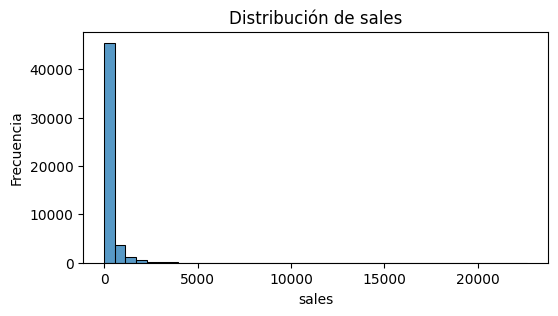

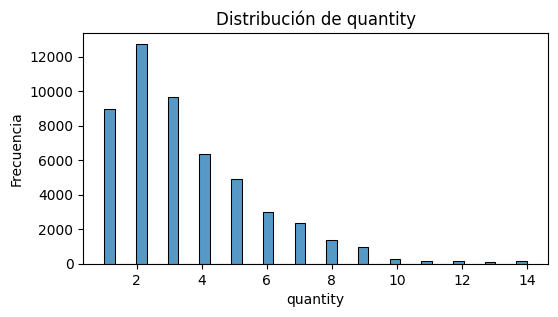

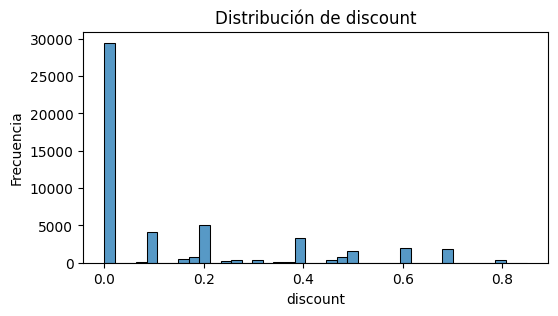

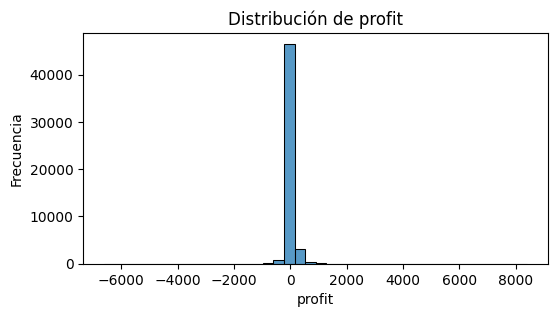

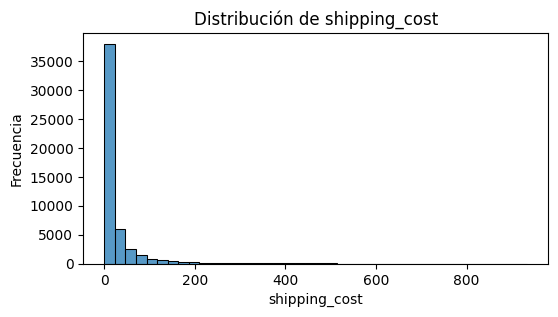

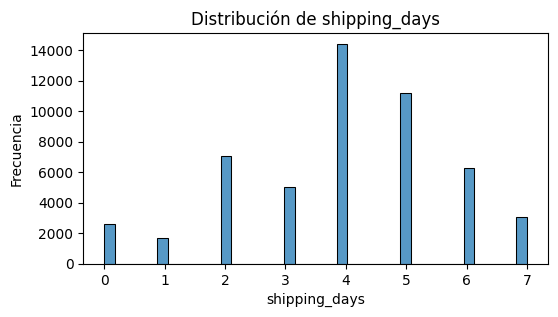

In [64]:
for variable in variables_numericas_eda:
    plt.figure(figsize=(6, 3))
    sns.histplot(
        data=df_eda,
        x=variable,
        bins=40
    )
    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.show()

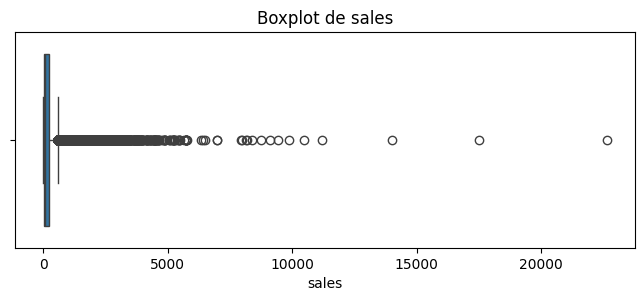

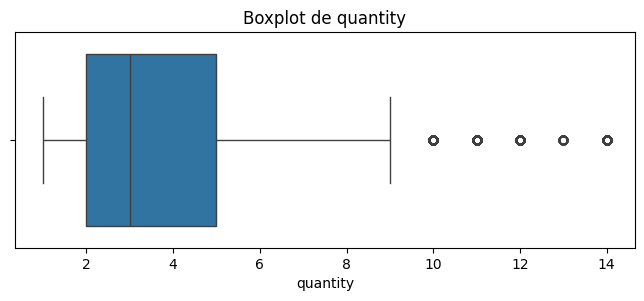

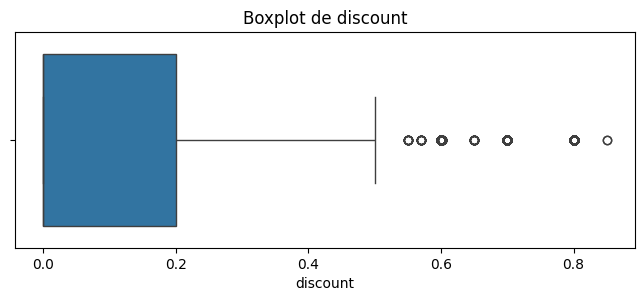

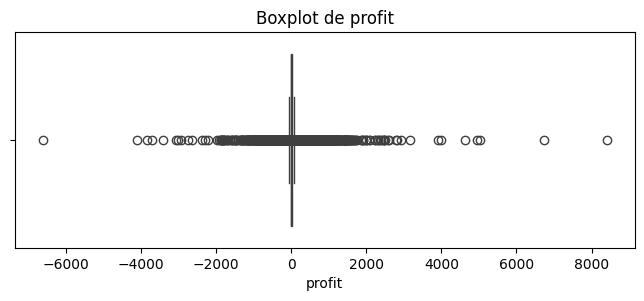

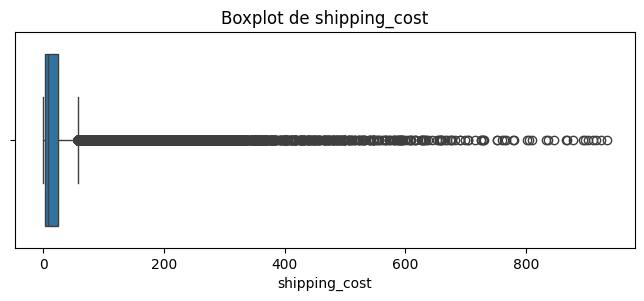

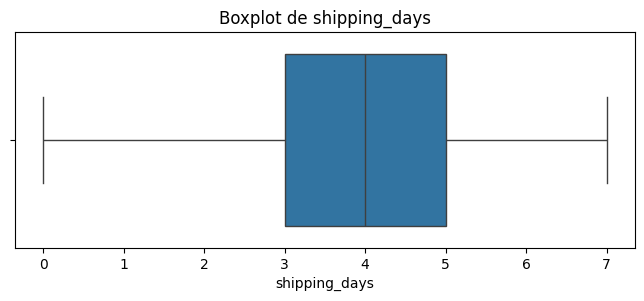

In [65]:
for variable in variables_numericas_eda:
    plt.figure(figsize=(8, 2.8))
    sns.boxplot(
        data=df_eda,
        x=variable
    )
    plt.title(f"Boxplot de {variable}")
    plt.show()

### Conclusiones del análisis univariado numérico


Las principales variables comerciales presentan comportamientos heterogéneos.

- `sales` presenta una distribución fuertemente asimétrica hacia valores altos. La mediana es 85, mientras que el máximo alcanza 22.638. El 99 % de los registros presenta ventas iguales o inferiores a aproximadamente 2.301.

- `quantity` se concentra principalmente entre 1 y 5 unidades. Los valores elevados observados son poco frecuentes pero resultan comercialmente plausibles.

- `discount` presenta una gran concentración en cero y en niveles discretos de descuento. Los descuentos elevados aparecen como extremos estadísticos, pero no se consideran errores de calidad.

- `profit` presenta tanto valores negativos como positivos de gran magnitud. Estas observaciones no serán eliminadas, ya que las pérdidas y ganancias extremas pueden contener información relevante para el análisis de rentabilidad.

- `shipping_cost` presenta una distribución fuertemente sesgada hacia la derecha, con una mayoría de costos relativamente bajos y una cola de operaciones con costos considerablemente mayores.

- `shipping_days` presenta un comportamiento estable entre 0 y 7 días, con una mediana de 4 días y sin valores extremos relevantes.

Los valores identificados como outliers por los boxplots se interpretan inicialmente como extremos estadísticos y no como errores. Su tratamiento solo se decidirá si análisis posteriores proporcionan evidencia suficiente para hacerlo.

Las medidas de asimetría confirman estos patrones: `sales` (8,14), `shipping_cost` (5,86) y `profit` (4,16) presentan los mayores sesgos positivos, mientras que `shipping_days` muestra una leve asimetría negativa (-0,43).

## 3. Análisis univariado de variables categóricas


En este bloque se analiza la distribución de las principales variables categóricas del dataset.

El objetivo es conocer la composición de los registros según:

- segmento de cliente;
- modalidad de envío;
- mercado;
- región;
- categoría;
- subcategoría;
- prioridad del pedido.

El análisis considera tanto frecuencias absolutas como proporciones relativas para identificar categorías dominantes, segmentos minoritarios y posibles desequilibrios en la distribución de los datos.

In [66]:
# Cardinalidad de las variables categóricas
variables_categoricas_eda = [
    "segment",
    "ship_mode",
    "market",
    "region",
    "category",
    "sub_category",
    "order_priority"
]

cardinalidad_categoricas = pd.DataFrame({
    "valores_unicos": [
        df_eda[columna].nunique()
        for columna in variables_categoricas_eda
    ]
}, index=variables_categoricas_eda)

display(cardinalidad_categoricas)

,valores_unicos
segment,3
ship_mode,4
market,7
region,13
category,3
sub_category,17
order_priority,4


In [67]:
def tabla_frecuencias(df, columna):
    frecuencia = df[columna].value_counts()
    porcentaje = df[columna].value_counts(normalize=True) * 100

    resultado = pd.DataFrame({
        "frecuencia": frecuencia,
        "porcentaje": porcentaje
    })

    resultado["porcentaje"] = resultado["porcentaje"].round(2)

    return resultado

In [68]:
for columna in variables_categoricas_eda:
    print(f"\n--- {columna.upper()} ---")
    display(tabla_frecuencias(df_eda, columna))


--- SEGMENT ---


,frecuencia,porcentaje
segment,,
Consumer,26518,51.70
Corporate,15429,30.08
Home Office,9343,18.22



--- SHIP_MODE ---


,frecuencia,porcentaje
ship_mode,,
Standard Class,30775,60.00
Second Class,10309,20.10
First Class,7505,14.63
Same Day,2701,5.27



--- MARKET ---


...

,frecuencia,porcentaje
category,,
Office Supplies,31273,60.97
Technology,10141,19.77
Furniture,9876,19.26



--- SUB_CATEGORY ---


,frecuencia,porcentaje
sub_category,,
Binders,6152,11.99
Storage,5059,9.86
Art,4883,9.52
Paper,3538,6.90
Chairs,3434,6.70
Phones,3357,6.55
Furnishings,3170,6.18
Accessories,3075,6.00
Labels,2606,5.08



--- ORDER_PRIORITY ---


,frecuencia,porcentaje
order_priority,,
Medium,29433,57.39
High,15501,30.22
Critical,3932,7.67
Low,2424,4.73


In [69]:
resumen_categoricas = []

for columna in variables_categoricas_eda:
    frecuencias = df_eda[columna].value_counts()

    categoria_dominante = frecuencias.index[0]
    frecuencia_dominante = frecuencias.iloc[0]
    porcentaje_dominante = (
        frecuencia_dominante / len(df_eda) * 100
    )

    resumen_categoricas.append({
        "variable": columna,
        "categoria_dominante": categoria_dominante,
        "frecuencia": frecuencia_dominante,
        "porcentaje": porcentaje_dominante
    })

resumen_categoricas = pd.DataFrame(resumen_categoricas)

resumen_categoricas["porcentaje"] = (
    resumen_categoricas["porcentaje"].round(2)
)

display(resumen_categoricas)

,variable,categoria_dominante,frecuencia,porcentaje
0,segment,Consumer,26518,51.70
1,ship_mode,Standard Class,30775,60.00
2,market,APAC,11002,21.45
3,region,Central,11117,21.67
4,category,Office Supplies,31273,60.97
5,sub_category,Binders,6152,11.99
6,order_priority,Medium,29433,57.39


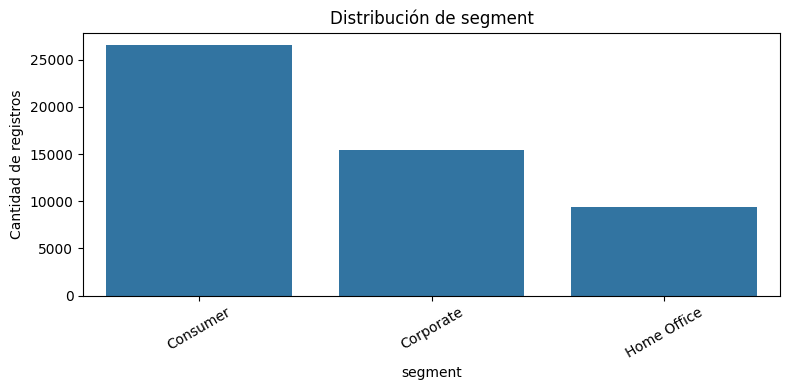

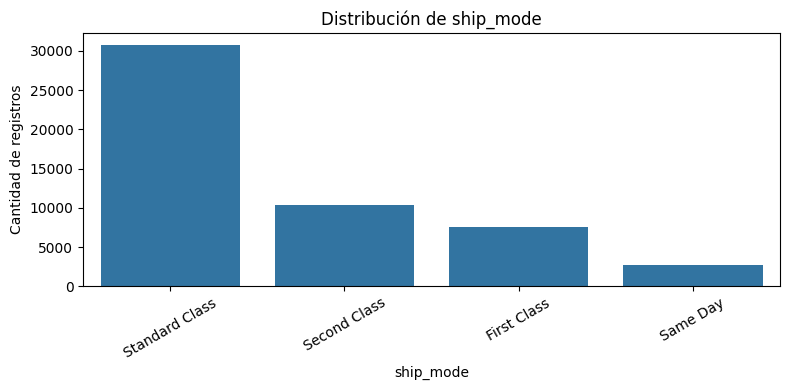

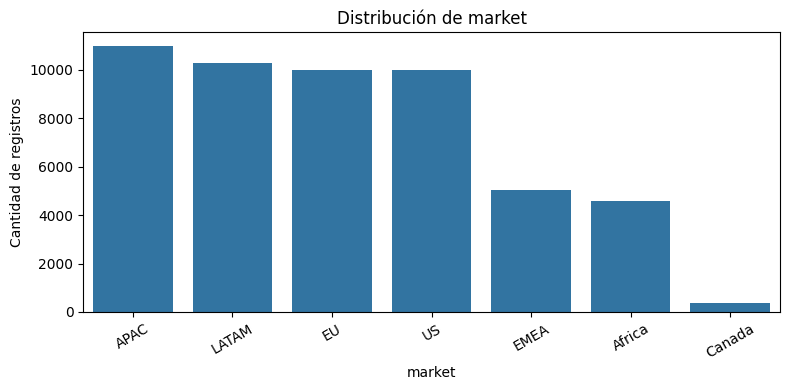

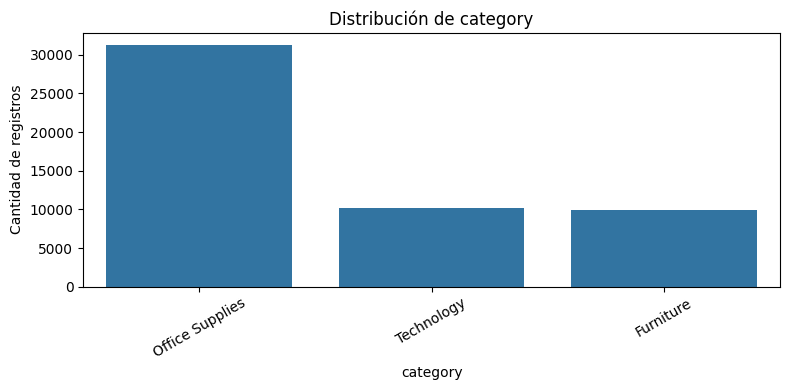

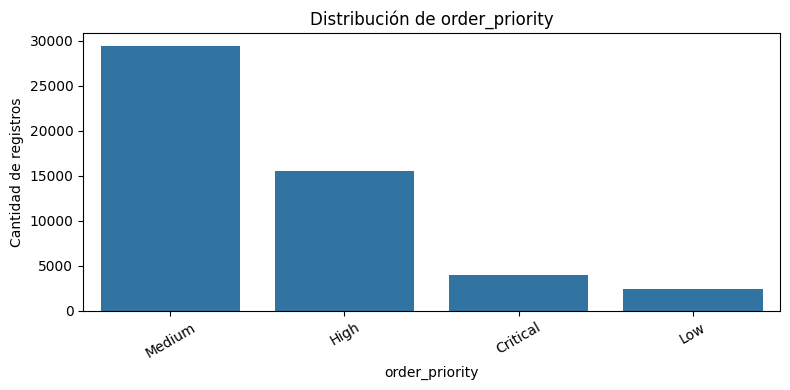

In [70]:
categoricas_graficos = [
    "segment",
    "ship_mode",
    "market",
    "category",
    "order_priority"
]

for columna in categoricas_graficos:
    orden = df_eda[columna].value_counts().index

    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=df_eda,
        x=columna,
        order=orden
    )

    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Cantidad de registros")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

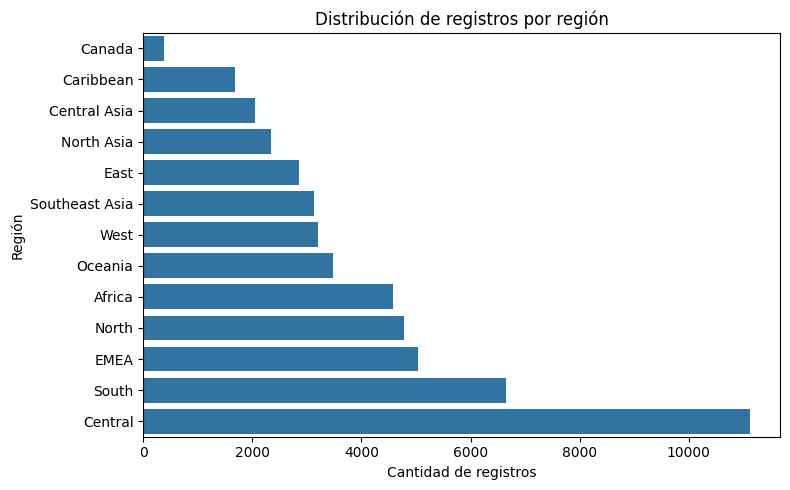

In [71]:
orden_region = (
    df_eda["region"]
    .value_counts()
    .sort_values(ascending=True)
    .index
)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_eda,
    y="region",
    order=orden_region
)

plt.title("Distribución de registros por región")
plt.xlabel("Cantidad de registros")
plt.ylabel("Región")
plt.tight_layout()
plt.show()

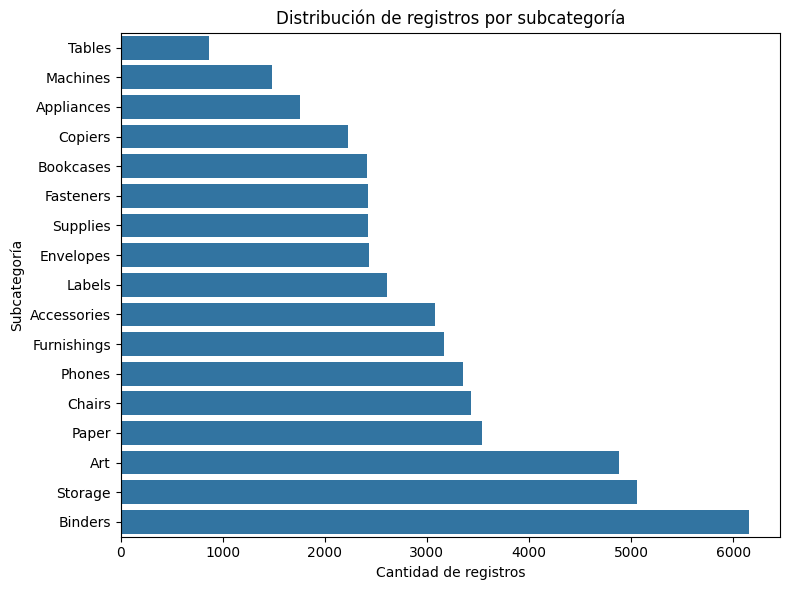

In [72]:
orden_subcategoria = (
    df_eda["sub_category"]
    .value_counts()
    .sort_values(ascending=True)
    .index
)

plt.figure(figsize=(8, 6))

sns.countplot(
    data=df_eda,
    y="sub_category",
    order=orden_subcategoria
)

plt.title("Distribución de registros por subcategoría")
plt.xlabel("Cantidad de registros")
plt.ylabel("Subcategoría")
plt.tight_layout()
plt.show()

### Conclusiones del análisis univariado categórico

El análisis de las variables categóricas muestra una composición desigual en varias dimensiones del dataset.

- El segmento `Consumer` concentra el 51,70 % de las líneas de transacción, seguido por `Corporate` (30,08 %) y `Home Office` (18,22 %).

- `Standard Class` es la modalidad de envío dominante, con el 60,00 % de los registros. `Same Day` representa únicamente el 5,27 %.

- Los mercados APAC, LATAM, EU y US presentan participaciones relativamente similares, cercanas al 20 % cada uno. En conjunto concentran aproximadamente el 80,5 % de las
  observaciones. Canada representa solamente el 0,75 %.

- La región `Central` presenta la mayor cantidad de líneas de transacción, con el 21,67 % del total.

- `Office Supplies` es la categoría claramente dominante, con el 60,97 % de los registros. `Technology` (19,77 %) y `Furniture` (19,26 %) presentan participaciones similares entre sí.

- Las subcategorías más frecuentes son `Binders` (11,99 %), `Storage` (9,86 %) y `Art` (9,52 %), mientras que `Tables` (1,68 %) presenta la menor participación.

- La prioridad `Medium` concentra el 57,39 % de las observaciones, seguida por `High` con el 30,22 %.

Estas frecuencias representan líneas de transacción y no deben interpretarse directamente como participación en ventas, ingresos o rentabilidad. Dichas relaciones serán evaluadas en bloques posteriores.

La fuerte concentración de registros en determinadas categorías y subcategorías también deberá considerarse durante el desarrollo del sistema de recomendación, ya que podría
generar sesgos hacia los productos más frecuentes.

## 4. Análisis temporal


En este bloque se analiza la evolución temporal del negocio durante el período 2011-2014.

El objetivo es estudiar el comportamiento de:

- ventas;
- beneficio;
- cantidad vendida;
- número de transacciones;
- crecimiento interanual;
- evolución mensual;
- posibles patrones estacionales.

Para contabilizar transacciones se utilizará la clave compuesta validada previamente: `order_id + order_date + customer_name`, debido a que `order_id` no constituye una
clave global única.

In [73]:
df_eda["transaction_key"] = (
    df_eda["order_id"].astype(str)
    + "|"
    + df_eda["order_date"].astype(str)
    + "|"
    + df_eda["customer_name"].astype(str)
)

print(
    "Transacciones únicas:",
    f"{df_eda['transaction_key'].nunique():,}"
)

Transacciones únicas: 25,754


In [74]:
# Comparar Crecimiento y Rentabilidad año a año
resumen_anual = (
    df_eda.groupby("year")
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        cantidad=("quantity", "sum"),
        transacciones=("transaction_key", "nunique"),
        lineas=("order_id", "size")
    )
)

resumen_anual["margen_profit_pct"] = (
    resumen_anual["profit"] / resumen_anual["ventas"] * 100
)

display(resumen_anual.round(2))

,ventas,profit,cantidad,transacciones,lineas,margen_profit_pct
year,,,,,,
2011,2259511,248940.81,31443,4516,8998,11.02
2012,2677493,307415.28,38111,5480,10962,11.48
2013,3405860,408512.76,48136,6890,13799,11.99
2014,4300041,504165.97,60622,8868,17531,11.72


In [75]:
crecimiento_anual = resumen_anual[
    ["ventas", "profit", "cantidad", "transacciones"]
].pct_change() * 100

display(crecimiento_anual.round(2))

,ventas,profit,cantidad,transacciones
year,,,,
2011,NaN,NaN,NaN,NaN
2012,18.50,23.49,21.21,21.35
2013,27.20,32.89,26.30,25.73
2014,26.25,23.41,25.94,28.71


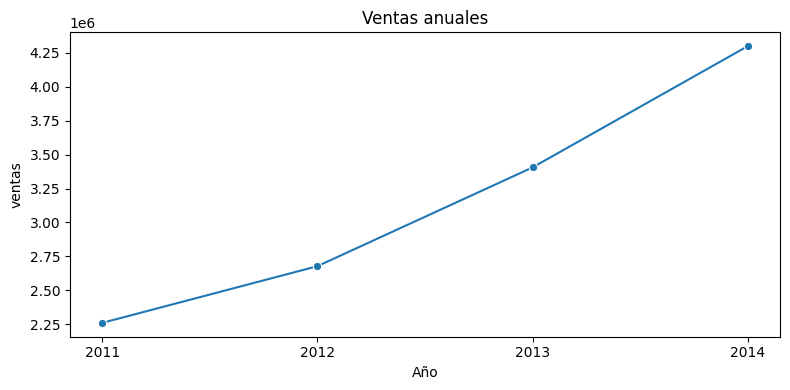

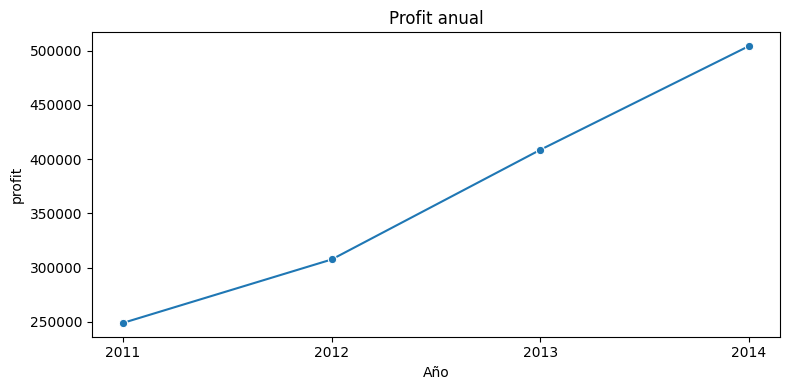

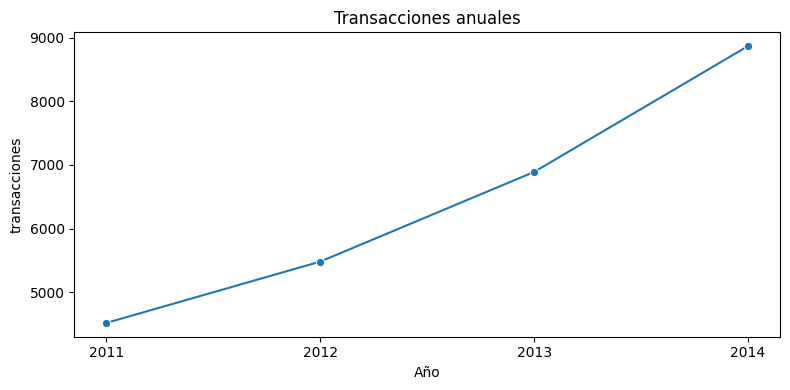

In [76]:
for variable, titulo in [
    ("ventas", "Ventas anuales"),
    ("profit", "Profit anual"),
    ("transacciones", "Transacciones anuales")
]:
    plt.figure(figsize=(8, 4))

    sns.lineplot(
        data=resumen_anual,
        x=resumen_anual.index,
        y=variable,
        marker="o"
    )

    plt.title(titulo)
    plt.xlabel("Año")
    plt.ylabel(variable)
    plt.xticks(resumen_anual.index)
    plt.tight_layout()
    plt.show()

In [77]:
resumen_mensual = (
    df_eda.groupby("year_month")
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        cantidad=("quantity", "sum"),
        transacciones=("transaction_key", "nunique")
    )
    .reset_index()
)

resumen_mensual["fecha"] = (
    resumen_mensual["year_month"]
    .dt.to_timestamp()
)

display(resumen_mensual.head())

,year_month,ventas,profit,cantidad,transacciones,fecha
0,2011-01,98902,8321.80096,1463,216,2011-01-01
1,2011-02,91152,12417.90698,1224,183,2011-02-01
2,2011-03,145726,15303.56826,1836,277,2011-03-01
3,2011-04,116927,12902.32438,2020,267,2011-04-01
4,2011-05,146762,12183.82870,2013,296,2011-05-01


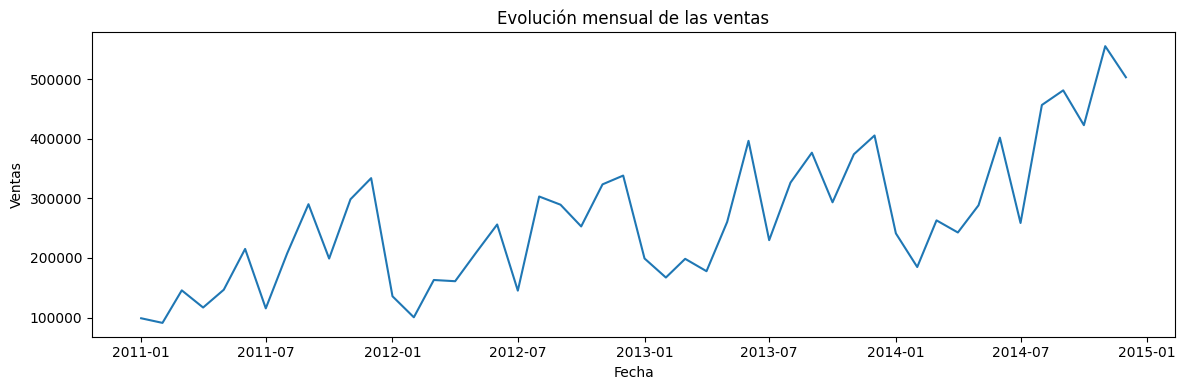

In [78]:
plt.figure(figsize=(12, 4))

sns.lineplot(
    data=resumen_mensual,
    x="fecha",
    y="ventas"
)

plt.title("Evolución mensual de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()

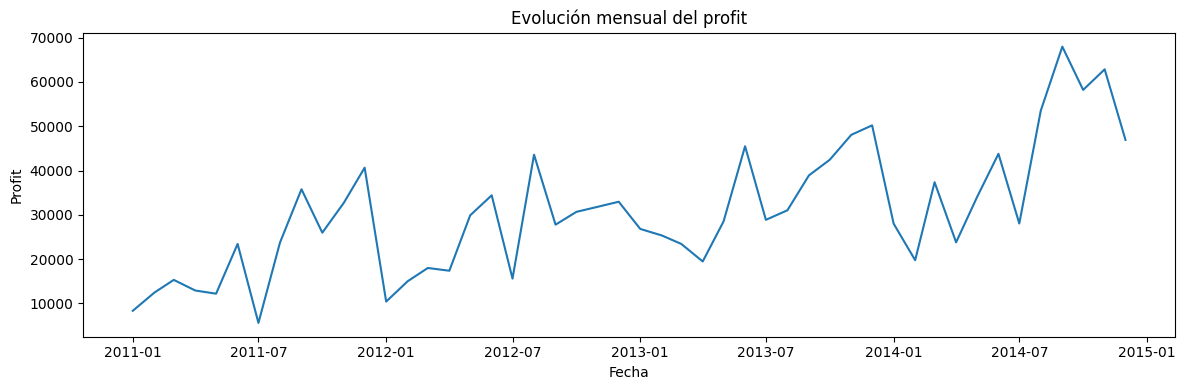

In [79]:
plt.figure(figsize=(12, 4))

sns.lineplot(
    data=resumen_mensual,
    x="fecha",
    y="profit"
)

plt.title("Evolución mensual del profit")
plt.xlabel("Fecha")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [80]:
resumen_mensual["mes"] = resumen_mensual["fecha"].dt.month

estacionalidad = (
    resumen_mensual.groupby("mes")
    .agg(
        ventas_promedio=("ventas", "mean"),
        profit_promedio=("profit", "mean"),
        transacciones_promedio=("transacciones", "mean")
    )
)

display(estacionalidad.round(2))

,ventas_promedio,profit_promedio,transacciones_promedio
mes,,,
1,168785.25,18383.85,317.75
2,135942.00,18127.43,276.25
3,192629.75,23521.88,389.25
4,174650.75,18378.41,377.25
5,226015.25,26127.45,475.50
6,317437.75,36769.85,667.75
7,187355.75,19517.52,391.00
8,323463.00,37963.53,628.50
9,359358.00,42609.55,757.50


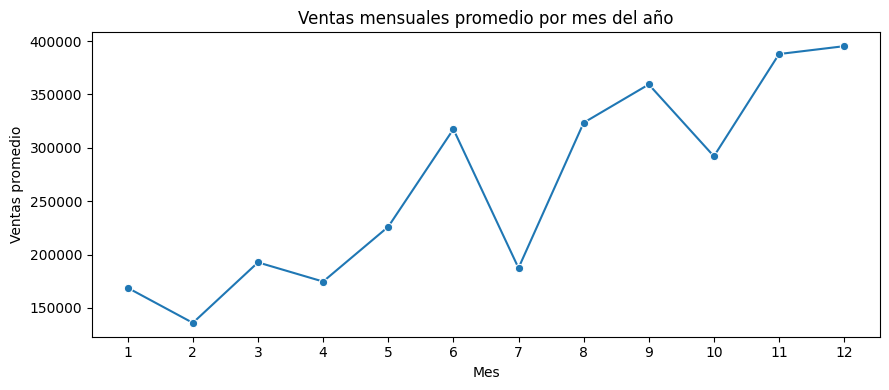

In [81]:
plt.figure(figsize=(9, 4))

sns.lineplot(
    data=estacionalidad,
    x=estacionalidad.index,
    y="ventas_promedio",
    marker="o"
)

plt.title("Ventas mensuales promedio por mes del año")
plt.xlabel("Mes")
plt.ylabel("Ventas promedio")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [82]:
top_meses_ventas = (
    resumen_mensual[
        ["year_month", "ventas", "profit", "transacciones"]
    ]
    .sort_values("ventas", ascending=False)
    .head(10)
)

print("10 meses con mayores ventas:")
display(top_meses_ventas)

print("\n10 meses con menores ventas:")
display(
    resumen_mensual[
        ["year_month", "ventas", "profit", "transacciones"]
    ]
    .sort_values("ventas")
    .head(10)
)

10 meses con mayores ventas:


,year_month,ventas,profit,transacciones
46,2014-11,555312,62856.58790,1082
47,2014-12,503154,46916.52068,1102
44,2014-09,481186,67979.45110,1022
43,2014-08,456633,53542.89496,849
45,2014-10,422785,58209.83476,810
35,2013-12,405476,50202.87112,828
41,2014-06,401843,43778.60280,902
29,2013-06,396513,45478.41340,726
32,2013-09,376626,38905.66778,837
34,2013-11,373996,48062.99670,793



10 meses con menores ventas:


,year_month,ventas,profit,transacciones
1,2011-02,91152,12417.90698,183
0,2011-01,98902,8321.80096,216
13,2012-02,100521,15000.09618,230
6,2011-07,115518,5585.00352,250
3,2011-04,116927,12902.32438,267
12,2012-01,135775,10401.63764,260
18,2012-07,145247,15585.38842,325
2,2011-03,145726,15303.56826,277
4,2011-05,146762,12183.82870,296
15,2012-04,161060,17366.96722,323


In [83]:
# Participación mensual dentro de cada año
ventas_mes_anio = (
    df_eda
    .groupby(["year", "month"])["sales"]
    .sum()
    .reset_index()
)

ventas_mes_anio["ventas_anuales"] = (
    ventas_mes_anio
    .groupby("year")["sales"]
    .transform("sum")
)

ventas_mes_anio["participacion_pct"] = (
    ventas_mes_anio["sales"]
    / ventas_mes_anio["ventas_anuales"]
    * 100
)

participacion_mensual = (
    ventas_mes_anio
    .groupby("month")["participacion_pct"]
    .mean()
)

display(
    participacion_mensual
    .to_frame("participacion_promedio_pct")
    .round(2)
)

,participacion_promedio_pct
month,
1,5.23
2,4.25
3,6.12
4,5.51
5,7.16
6,10.02
7,5.83
8,10.18
9,11.48


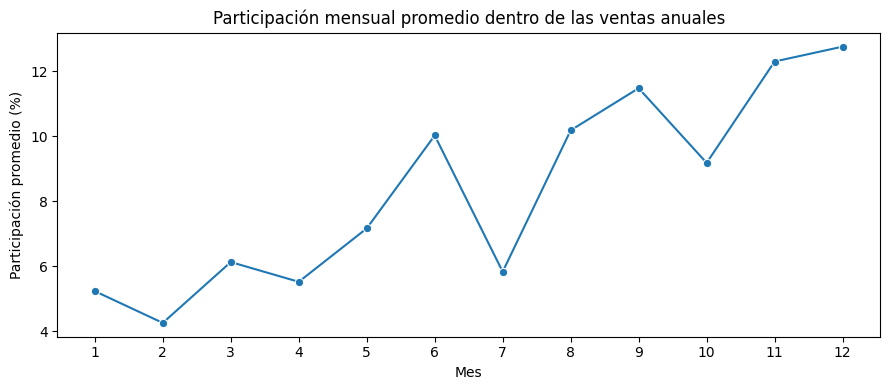

In [84]:
plt.figure(figsize=(9, 4))

sns.lineplot(
    x=participacion_mensual.index,
    y=participacion_mensual.values,
    marker="o"
)

plt.title("Participación mensual promedio dentro de las ventas anuales")
plt.xlabel("Mes")
plt.ylabel("Participación promedio (%)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Conclusiones preliminares del análisis temporal

El negocio presenta una tendencia de crecimiento sostenido durante el período 2011-2014.

Las ventas aumentaron desde 2,26 millones en 2011 hasta 4,30 millones en 2014. En paralelo, las transacciones aumentaron de 4.516 a 8.868 y el profit pasó de aproximadamente 248.941 a 504.166.

Los crecimientos interanuales de ventas fueron del 18,50% en 2012, 27,20% en 2013 y 26,25% en 2014.

El margen de profit se mantuvo relativamente estable entre aproximadamente 11% y 12%, aunque en 2014 se observa una leve reducción respecto de 2013.

El análisis de participación mensual dentro de cada año refuerza la existencia de un patrón estacional descriptivo.

En promedio, aproximadamente el 61,7% de las ventas anuales se concentra entre julio y diciembre, frente al 38,3% correspondiente al primer semestre.

Los meses con mayor participación promedio son diciembre (12,75%), noviembre (12,30%) y septiembre (11,48%), mientras que febrero (4,25%) presenta la menor participación.

Este patrón se mantiene al expresar las ventas mensuales como proporción del total anual, reduciendo así el efecto de la tendencia general de crecimiento observada entre 2011 y 2014.

Por lo tanto, se observa evidencia descriptiva consistente de una mayor actividad comercial durante el segundo semestre, particularmente hacia el cierre del año. Dado que el dataset abarca cuatro años, este resultado no se interpreta como una demostración estadística formal de estacionalidad.

## 5. Análisis comercial por categorías y productos


En este bloque se analiza el desempeño comercial de categorías, subcategorías y productos.

El objetivo es comparar:

- volumen de ventas;
- profit generado;
- cantidad vendida;
- número de líneas de transacción;
- margen de profit;
- participación sobre las ventas totales.

Este análisis permitirá determinar si las categorías y productos más frecuentes son también los que generan mayores ventas y rentabilidad.

In [85]:
# Desempeño por Categoría
resumen_categoria = (
    df_eda.groupby("category")
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        cantidad=("quantity", "sum"),
        lineas=("category", "size")
    )
)

resumen_categoria["margen_profit_pct"] = (
    resumen_categoria["profit"]
    / resumen_categoria["ventas"]
    * 100
)

resumen_categoria["participacion_ventas_pct"] = (
    resumen_categoria["ventas"]
    / resumen_categoria["ventas"].sum()
    * 100
)

resumen_categoria = resumen_categoria.sort_values(
    "ventas",
    ascending=False
)

display(resumen_categoria.round(2))

,ventas,profit,shipping_cost,cantidad,lineas,margen_profit_pct,participacion_ventas_pct
category,,,,,,,
Technology,4744691,663778.73,507048.74,35176,10141,13.99,37.53
Furniture,4110884,286782.25,440320.66,34954,9876,6.98,32.52
Office Supplies,3787330,518473.83,405451.29,108182,31273,13.69,29.96


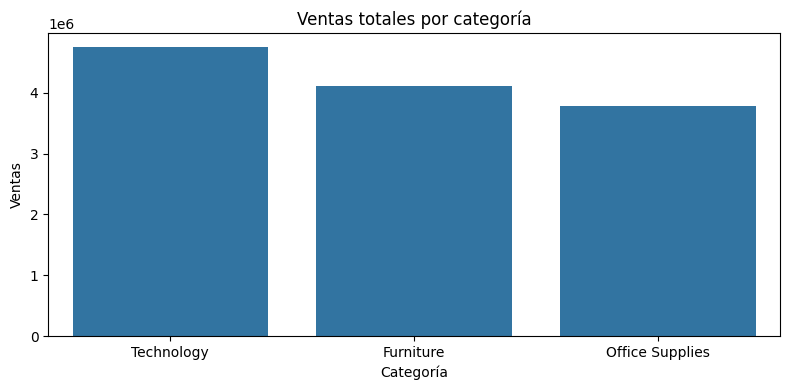

In [86]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=resumen_categoria.reset_index(),
    x="category",
    y="ventas"
)

plt.title("Ventas totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()

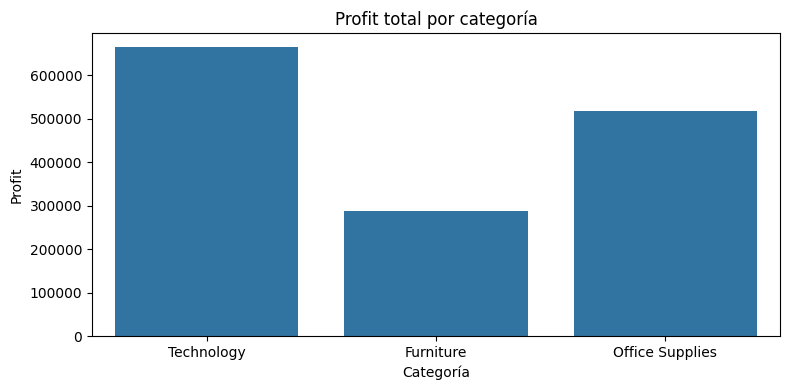

In [87]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=resumen_categoria.reset_index(),
    x="category",
    y="profit"
)

plt.title("Profit total por categoría")
plt.xlabel("Categoría")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

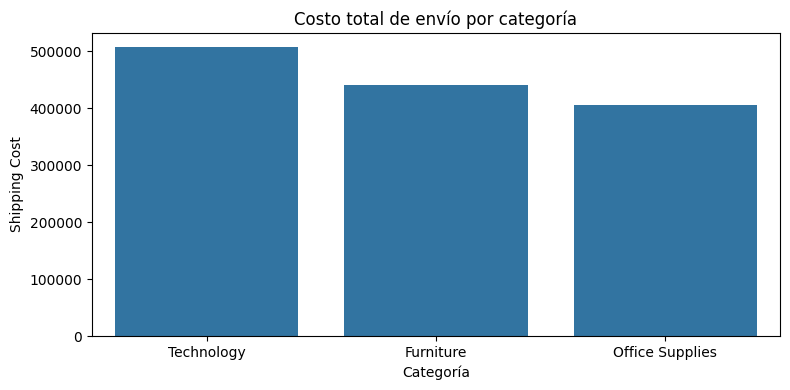

In [88]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=resumen_categoria.reset_index(),
    x="category",
    y="shipping_cost"
)

plt.title("Costo total de envío por categoría")
plt.xlabel("Categoría")
plt.ylabel("Shipping Cost")
plt.tight_layout()
plt.show()

In [89]:
resumen_subcategoria = (
    df_eda.groupby(
        ["category", "sub_category"]
    )
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        cantidad=("quantity", "sum"),
        lineas=("sub_category", "size")
    )
    .reset_index()
)

resumen_subcategoria["margen_profit_pct"] = (
    resumen_subcategoria["profit"]
    / resumen_subcategoria["ventas"]
    * 100
)

resumen_subcategoria["participacion_ventas_pct"] = (
    resumen_subcategoria["ventas"]
    / resumen_subcategoria["ventas"].sum()
    * 100
)

display(
    resumen_subcategoria
    .sort_values(
        "ventas",
        ascending=False
    )
    .round(2)
)

,category,sub_category,ventas,profit,shipping_cost,cantidad,lineas,margen_profit_pct,participacion_ventas_pct
16,Technology,Phones,1706874,216717.01,184902.77,11870,3357,12.70,13.50
14,Technology,Copiers,1509439,258567.55,159496.49,7454,2223,17.13,11.94
1,Furniture,Chairs,1501682,141973.80,164229.85,12336,3434,9.45,11.88
0,Furniture,Bookcases,1466559,161924.42,155482.23,8310,2411,11.04,11.60
11,Office Supplies,Storage,1127124,108461.49,120546.46,16917,5059,9.62,8.92
4,Office Supplies,Appliances,1011081,141680.59,108300.78,6078,1755,14.01,8.00
15,Technology,Machines,779071,58867.87,79135.90,4906,1486,7.56,6.16
3,Furniture,Tables,757034,-64083.39,79861.46,3083,861,-8.47,5.99
13,Technology,Accessories,749307,129626.31,83513.58,10946,3075,17.30,5.93
6,Office Supplies,Binders,461952,72449.85,48181.99,21429,6152,15.68,3.65


In [90]:
print("Subcategorías con mayores ventas:")

display(
    resumen_subcategoria[
        [
            "category",
            "sub_category",
            "ventas",
            "profit",
            "margen_profit_pct"
        ]
    ]
    .sort_values("ventas", ascending=False)
    .head(10)
    .round(2)
)

Subcategorías con mayores ventas:


,category,sub_category,ventas,profit,margen_profit_pct
16,Technology,Phones,1706874,216717.01,12.70
14,Technology,Copiers,1509439,258567.55,17.13
1,Furniture,Chairs,1501682,141973.80,9.45
0,Furniture,Bookcases,1466559,161924.42,11.04
11,Office Supplies,Storage,1127124,108461.49,9.62
4,Office Supplies,Appliances,1011081,141680.59,14.01
15,Technology,Machines,779071,58867.87,7.56
3,Furniture,Tables,757034,-64083.39,-8.47
13,Technology,Accessories,749307,129626.31,17.30
6,Office Supplies,Binders,461952,72449.85,15.68


In [91]:
print("Subcategorías con mayor profit:")

display(
    resumen_subcategoria[
        [
            "category",
            "sub_category",
            "ventas",
            "profit",
            "margen_profit_pct"
        ]
    ]
    .sort_values("profit", ascending=False)
    .head(10)
    .round(2)
)

Subcategorías con mayor profit:


,category,sub_category,ventas,profit,margen_profit_pct
14,Technology,Copiers,1509439,258567.55,17.13
16,Technology,Phones,1706874,216717.01,12.70
0,Furniture,Bookcases,1466559,161924.42,11.04
1,Furniture,Chairs,1501682,141973.80,9.45
4,Office Supplies,Appliances,1011081,141680.59,14.01
13,Technology,Accessories,749307,129626.31,17.30
11,Office Supplies,Storage,1127124,108461.49,9.62
6,Office Supplies,Binders,461952,72449.85,15.68
10,Office Supplies,Paper,244307,59207.68,24.23
15,Technology,Machines,779071,58867.87,7.56


In [92]:
print("Subcategorías con menor profit:")

display(
    resumen_subcategoria[
        [
            "category",
            "sub_category",
            "ventas",
            "profit",
            "margen_profit_pct"
        ]
    ]
    .sort_values("profit")
    .head(10)
    .round(2)
)

Subcategorías con menor profit:


,category,sub_category,ventas,profit,margen_profit_pct
3,Furniture,Tables,757034,-64083.39,-8.47
8,Office Supplies,Fasteners,83254,11525.42,13.84
9,Office Supplies,Labels,73433,15010.51,20.44
12,Office Supplies,Supplies,243090,22583.26,9.29
7,Office Supplies,Envelopes,170926,29601.12,17.32
2,Furniture,Furnishings,385609,46967.43,12.18
5,Office Supplies,Art,372163,57953.91,15.57
15,Technology,Machines,779071,58867.87,7.56
10,Office Supplies,Paper,244307,59207.68,24.23
6,Office Supplies,Binders,461952,72449.85,15.68


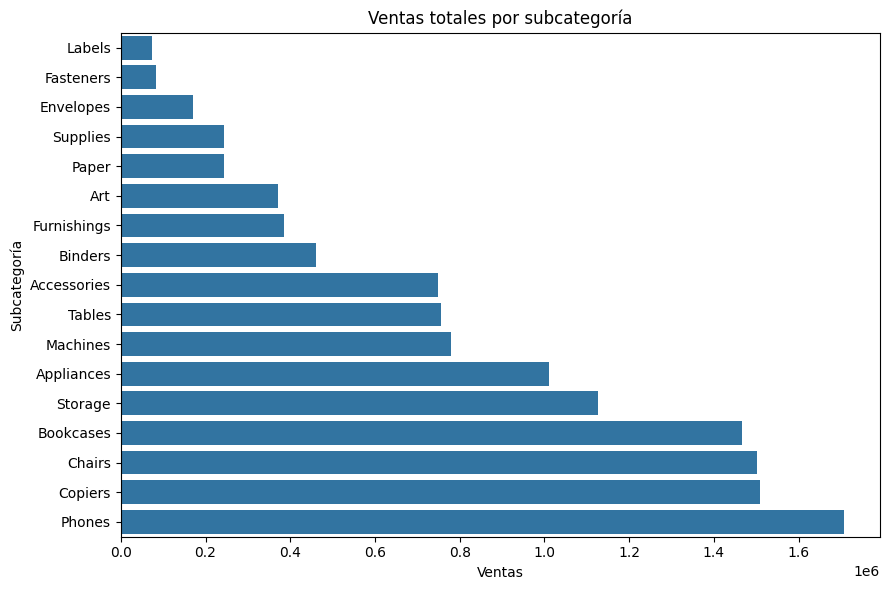

In [93]:
orden_ventas_subcategoria = (
    resumen_subcategoria
    .sort_values("ventas", ascending=True)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=orden_ventas_subcategoria,
    y="sub_category",
    x="ventas"
)

plt.title("Ventas totales por subcategoría")
plt.xlabel("Ventas")
plt.ylabel("Subcategoría")
plt.tight_layout()
plt.show()

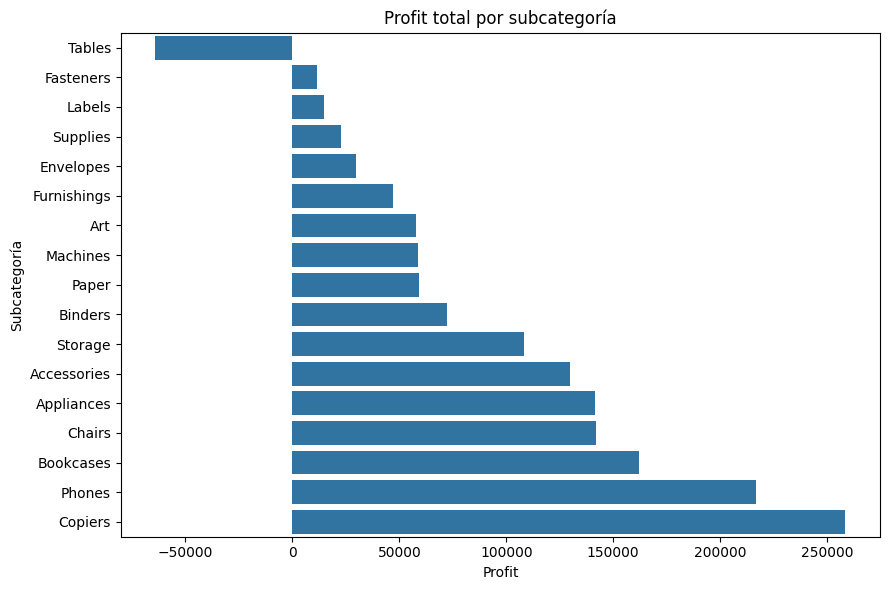

In [94]:
orden_profit_subcategoria = (
    resumen_subcategoria
    .sort_values("profit", ascending=True)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=orden_profit_subcategoria,
    y="sub_category",
    x="profit"
)

plt.title("Profit total por subcategoría")
plt.xlabel("Profit")
plt.ylabel("Subcategoría")
plt.tight_layout()
plt.show()

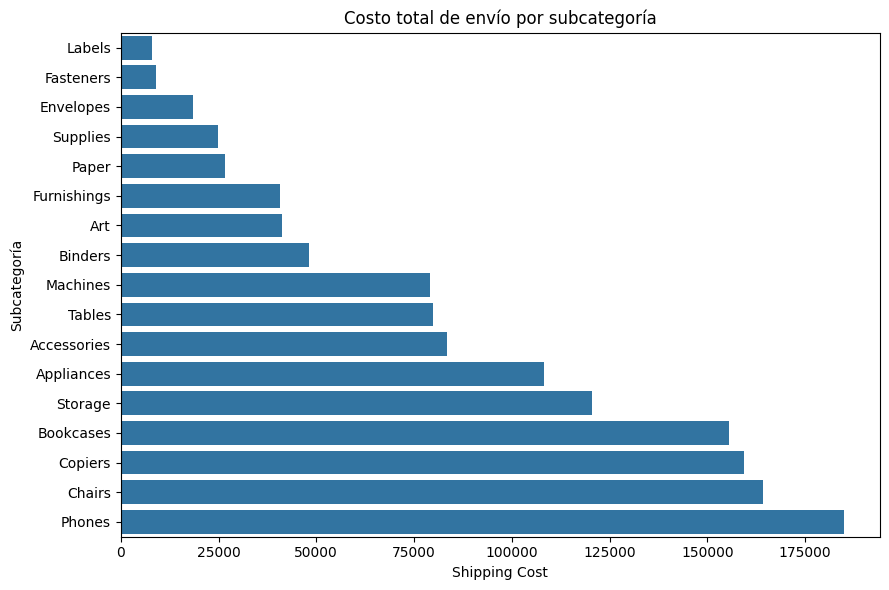

In [95]:
# Gráfico de Shipping cost por subcategoria
orden_shipping_subcategoria = (
    resumen_subcategoria
    .sort_values(
        "shipping_cost",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=orden_shipping_subcategoria,
    y="sub_category",
    x="shipping_cost"
)

plt.title(
    "Costo total de envío por subcategoría"
)

plt.xlabel("Shipping Cost")
plt.ylabel("Subcategoría")
plt.tight_layout()
plt.show()

In [96]:
# Crear identificador visual de producto
df_eda["item_id_name"] = (
    df_eda["product_id"].astype(str)
    + "|"
    + df_eda["product_name"].astype(str)
)

print(
    "Items únicos para análisis:",
    f"{df_eda['item_id_name'].nunique():,}"
)

Items únicos para análisis: 10,768


In [97]:
resumen_producto = (
    df_eda.groupby(
        ["item_id_name", "product_name", "category", "sub_category"]
    )
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        cantidad=("quantity", "sum"),
        lineas=("item_id_name", "size")
    )
    .reset_index()
)

resumen_producto["margen_profit_pct"] = (
    resumen_producto["profit"]
    / resumen_producto["ventas"]
    * 100
)

print("15 items con mayores ventas:")

display(
    resumen_producto[
        [
            "product_name",
            "category",
            "sub_category",
            "ventas",
            "profit",
            "cantidad",
            "margen_profit_pct"
        ]
    ]
    .sort_values("ventas", ascending=False)
    .head(15)
    .round(2)
)

15 items con mayores ventas:


,product_name,category,sub_category,ventas,profit,cantidad,margen_profit_pct
9388,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61600,25199.93,20,40.91
10632,"Nokia Smart Phone, with Caller ID",Technology,Phones,30042,5455.95,52,18.16
4017,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27454,7753.04,31,28.24
9721,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638,-1811.08,6,-8.00
10646,"Nokia Smart Phone, Full Size",Technology,Phones,22261,8121.48,39,36.48
745,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870,0.00,39,0.00
541,"SAFCO Executive Leather Armchair, Black",Furniture,Chairs,21329,1363.23,50,6.39
2882,"Hoover Stove, Red",Office Supplies,Appliances,21148,10345.58,38,48.92
3744,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,19824,2233.51,37,11.27
3634,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,19026,760.98,48,4.00


In [98]:
print("15 items con mayor profit:")

display(
    resumen_producto[
        [
            "product_name",
            "category",
            "sub_category",
            "ventas",
            "profit",
            "cantidad",
            "margen_profit_pct"
        ]
    ]
    .sort_values("profit", ascending=False)
    .head(15)
    .round(2)
)

15 items con mayor profit:


,product_name,category,sub_category,ventas,profit,cantidad,margen_profit_pct
9388,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61600,25199.93,20,40.91
2882,"Hoover Stove, Red",Office Supplies,Appliances,21148,10345.58,38,48.92
10646,"Nokia Smart Phone, Full Size",Technology,Phones,22261,8121.48,39,36.48
4017,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27454,7753.04,31,28.24
9099,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18840,6983.88,38,37.07
776,"Office Star Executive Leather Armchair, Black",Furniture,Chairs,15289,6123.26,37,40.05
10632,"Nokia Smart Phone, with Caller ID",Technology,Phones,30042,5455.95,52,18.16
2681,"Hamilton Beach Stove, Silver",Office Supplies,Appliances,18248,5452.46,38,29.88
10097,"Samsung Smart Phone, VoIP",Technology,Phones,16797,5356.81,31,31.89
766,"SAFCO Executive Leather Armchair, Black",Furniture,Chairs,12301,5003.10,30,40.67


In [99]:
print("15 items con menor profit:")

display(
    resumen_producto[
        [
            "product_name",
            "category",
            "sub_category",
            "ventas",
            "profit",
            "cantidad",
            "margen_profit_pct"
        ]
    ]
    .sort_values("profit")
    .head(15)
    .round(2)
)

15 items con menor profit:


,product_name,category,sub_category,ventas,profit,cantidad,margen_profit_pct
9574,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11100,-8879.97,9,-80.00
2614,"Hoover Stove, White",Office Supplies,Appliances,11730,-4958.16,31,-42.27
9605,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16830,-4589.97,18,-27.27
10424,"Apple Smart Phone, Full Size",Technology,Phones,7258,-4574.64,20,-63.03
9984,"Motorola Smart Phone, Cordless",Technology,Phones,10350,-3998.68,24,-38.63
9876,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,8000,-3839.99,4,-48.00
699,"Office Star Executive Leather Armchair, Black",Furniture,Chairs,6498,-3066.78,22,-47.20
1993,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9918,-2876.12,27,-29.00
2157,"Lesro Computer Table, Fully Assembled",Furniture,Tables,1200,-2798.49,14,-233.21
2118,"Hon Conference Table, Rectangular",Furniture,Tables,3667,-2619.31,12,-71.43


In [100]:
items_ventas_cero = resumen_producto[
    resumen_producto["ventas"] == 0
]

print(
    "Items con ventas totales iguales a cero:",
    f"{len(items_ventas_cero):,}"
)

display(items_ventas_cero)

Items con ventas totales iguales a cero: 0


,item_id_name,product_name,category,sub_category,ventas,profit,cantidad,lineas,margen_profit_pct


In [101]:
print(
    "Items con profit negativo:",
    f"{(resumen_producto['profit'] < 0).sum():,}"
)

print(
    "Items con profit positivo:",
    f"{(resumen_producto['profit'] > 0).sum():,}"
)

print(
    "Items con profit igual a cero:",
    f"{(resumen_producto['profit'] == 0).sum():,}"
)

Items con profit negativo: 3,032
Items con profit positivo: 7,692
Items con profit igual a cero: 44


### Conclusiones del análisis comercial por categorías y productos

El análisis evidencia que frecuencia de aparición, volumen de ventas y rentabilidad representan dimensiones diferentes del negocio.

`Office Supplies` concentra aproximadamente el 60,97% de las líneas de transacción, pero genera únicamente el 29,96% de las ventas. En contraste, `Technology` representa cerca del 19,77% de las líneas y genera el 37,53% de las ventas, además de presentar el mayor profit total (663.778,73) y un margen aproximado del 13,99%.

`Furniture` representa el 32,52% de las ventas, pero presenta un margen de profit del 6,98%, considerablemente inferior al de `Technology` y `Office Supplies`.

A nivel de subcategoría, `Phones` registra el mayor volumen de ventas, mientras que `Copiers` genera el mayor profit. Esto demuestra que las subcategorías con mayores ventas no necesariamente son las más rentables.

La principal anomalía comercial se identifica en `Tables`, que registra aproximadamente 757.034 en ventas pero un profit acumulado de -64.083,39, equivalente a un margen de -8,47%. Es la única subcategoría con profit agregado negativo y requerirá un análisis posterior de los factores que explican este comportamiento.

También se observan subcategorías con menor volumen de ventas pero márgenes elevados, como `Paper` y `Labels`, lo cual confirma que volumen y rentabilidad no deben interpretarse como métricas equivalentes.

A nivel de ítem se detecta una elevada heterogeneidad. Algunos productos combinan alto volumen de ventas y elevada rentabilidad, mientras que otros aparecen entre los productos
más vendidos pero generan pérdidas.

Estos resultados son especialmente relevantes para el futuro sistema de recomendación: una estrategia basada exclusivamente en popularidad o frecuencia podría favorecer productos con baja o incluso negativa rentabilidad. Por este motivo, las señales económicas deberán considerarse posteriormente como parte del análisis y de las posibles reglas de negocio asociadas al recomendador.

A nivel agregado de ítem, 7.692 productos presentan profit positivo, 3.032 presentan profit negativo y 44 registran profit acumulado igual a cero.

No se identificaron ítems con ventas totales iguales a cero, por lo que el único registro individual con `sales = 0` detectado previamente no genera problemas en el cálculo de
márgenes a nivel agregado.

La presencia de más de tres mil ítems con profit acumulado negativo refuerza la necesidad de distinguir entre popularidad, volumen de ventas y rentabilidad al diseñar posteriormente las estrategias de recomendación.

## 6. Análisis geográfico y por segmentos



En este bloque se analiza el desempeño comercial según la dimensión geográfica y el segmento de cliente.

El objetivo es comparar:

- mercados;
- regiones;
- países;
- states;
- segmentos de cliente;

considerando ventas, profit, margen de profit, cantidad vendida y número de transacciones.

Este análisis permitirá identificar qué áreas geográficas y segmentos concentran mayor actividad comercial y cuáles presentan mejores o peores niveles de rentabilidad.

In [102]:
# Desempeño por mercado
resumen_market = (
    df_eda.groupby("market")
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        cantidad=("quantity", "sum"),
        transacciones=("transaction_key", "nunique"),
        lineas=("market", "size")
    )
)

resumen_market["margen_profit_pct"] = (
    resumen_market["profit"]
    / resumen_market["ventas"]
    * 100
)

resumen_market["participacion_ventas_pct"] = (
    resumen_market["ventas"]
    / resumen_market["ventas"].sum()
    * 100
)

resumen_market = resumen_market.sort_values(
    "ventas",
    ascending=False
)

display(resumen_market.round(2))

,ventas,profit,cantidad,transacciones,lineas,margen_profit_pct,participacion_ventas_pct
market,,,,,,,
APAC,3585833,437577.58,41226,5437,11002,12.20,28.36
EU,2938139,372829.74,37773,5122,10000,12.69,23.24
US,2297354,286397.02,37873,5009,9994,12.47,18.17
LATAM,2164687,221643.49,38526,5149,10294,10.24,17.12
EMEA,806184,43897.97,11517,2543,5029,5.45,6.38
Africa,783776,88871.63,10564,2289,4587,11.34,6.20
Canada,66932,17817.39,833,205,384,26.62,0.53


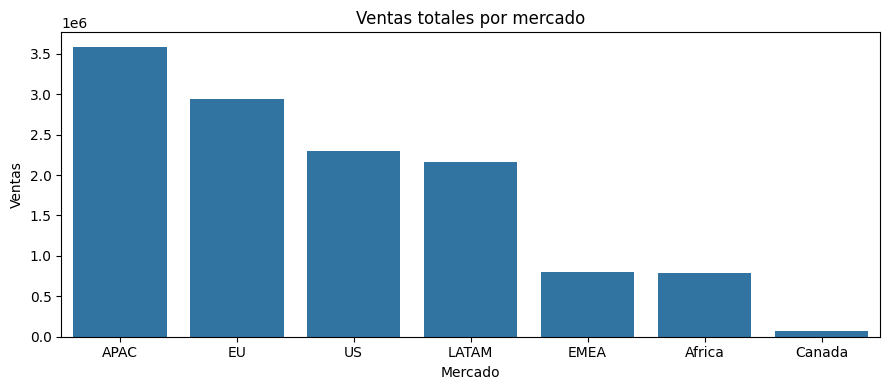

In [103]:
# Gráfico por mercado
plt.figure(figsize=(9, 4))

sns.barplot(
    data=resumen_market.reset_index(),
    x="market",
    y="ventas"
)

plt.title("Ventas totales por mercado")
plt.xlabel("Mercado")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()

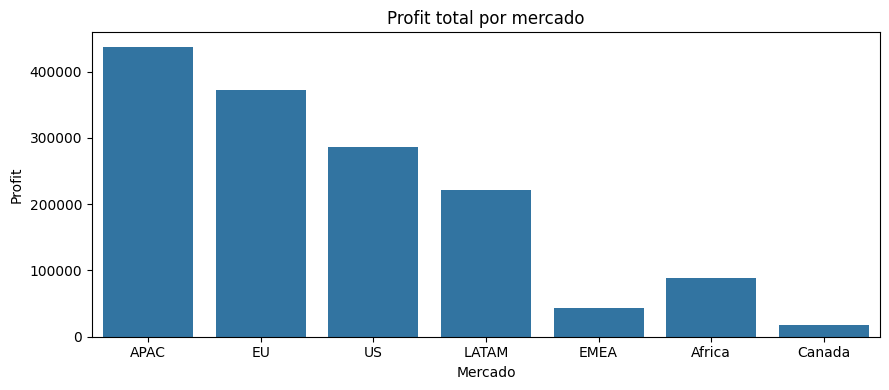

In [104]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=resumen_market.reset_index(),
    x="market",
    y="profit"
)

plt.title("Profit total por mercado")
plt.xlabel("Mercado")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [105]:
# Desempeño por región
resumen_region = (
    df_eda.groupby("region")
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        cantidad=("quantity", "sum"),
        transacciones=("transaction_key", "nunique"),
        lineas=("region", "size")
    )
)

resumen_region["margen_profit_pct"] = (
    resumen_region["profit"]
    / resumen_region["ventas"]
    * 100
)

resumen_region = resumen_region.sort_values(
    "ventas",
    ascending=False
)

display(resumen_region.round(2))

,ventas,profit,cantidad,transacciones,lineas,margen_profit_pct
region,,,,,,
Central,2822399,311403.98,41762,5641,11117,11.03
South,1600960,140355.77,25206,3335,6645,8.77
North,1248192,194597.95,18021,2436,4785,15.59
Oceania,1100207,121666.64,12838,1744,3487,11.06
Southeast Asia,884438,17852.33,11822,1517,3129,2.02
North Asia,848349,165578.42,8851,1150,2338,19.52
EMEA,806184,43897.97,11517,2543,5029,5.45
Africa,783776,88871.63,10564,2289,4587,11.34
Central Asia,752839,132480.19,7715,1026,2048,17.60


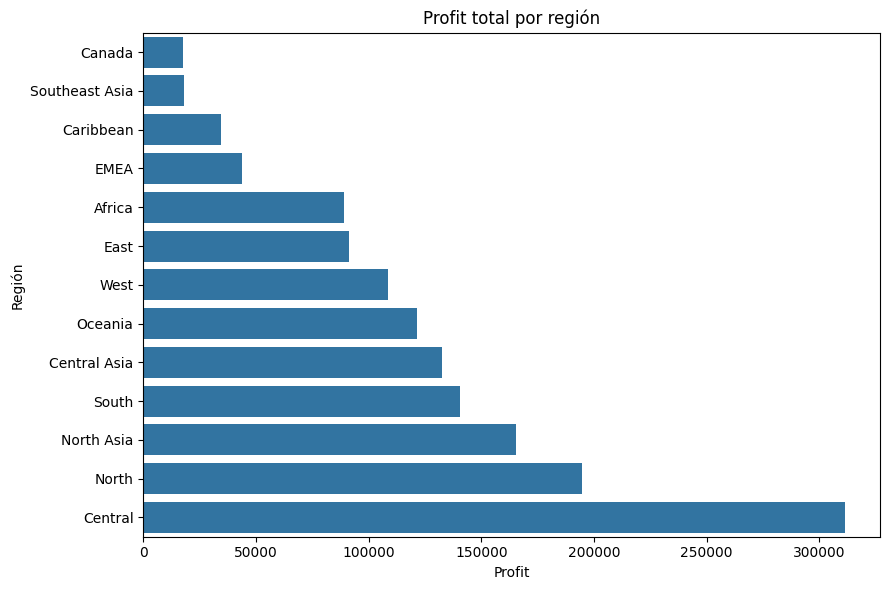

In [106]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=resumen_region.reset_index().sort_values("profit"),
    y="region",
    x="profit"
)

plt.title("Profit total por región")
plt.xlabel("Profit")
plt.ylabel("Región")
plt.tight_layout()
plt.show()

In [107]:
# Ranking de países
resumen_pais = (
    df_eda.groupby("country")
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        cantidad=("quantity", "sum"),
        transacciones=("transaction_key", "nunique"),
        lineas=("country", "size")
    )
    .reset_index()
)

resumen_pais["margen_profit_pct"] = (
    resumen_pais["profit"]
    / resumen_pais["ventas"]
    * 100
)

In [108]:
print("15 países con mayores ventas:")

display(
    resumen_pais
    .sort_values("ventas", ascending=False)
    .head(15)
    .round(2)
)

15 países con mayores ventas:


,country,ventas,profit,cantidad,transacciones,lineas,margen_profit_pct
139,United States,2297354,286397.02,37873,5009,9994,12.47
6,Australia,925257,105484.96,10673,1420,2837,11.40
44,France,858930,109029.00,10804,1476,2827,12.69
26,China,700591,150683.08,7081,925,1880,21.51
47,Germany,628857,107322.82,7745,1019,2065,17.07
81,Mexico,622620,102818.10,10011,1329,2644,16.51
57,India,589664,129071.84,5758,785,1555,21.89
138,United Kingdom,528570,111900.15,6161,853,1633,21.17
58,Indonesia,404887,15608.68,5237,698,1390,3.86
17,Brazil,361098,30090.50,6148,786,1599,8.33


In [109]:
print("15 países con mayor profit:")

display(
    resumen_pais
    .sort_values("profit", ascending=False)
    .head(15)
    .round(2)
)

15 países con mayor profit:


,country,ventas,profit,cantidad,transacciones,lineas,margen_profit_pct
139,United States,2297354,286397.02,37873,5009,9994,12.47
26,China,700591,150683.08,7081,925,1880,21.51
57,India,589664,129071.84,5758,785,1555,21.89
138,United Kingdom,528570,111900.15,6161,853,1633,21.17
44,France,858930,109029.00,10804,1476,2827,12.69
47,Germany,628857,107322.82,7745,1019,2065,17.07
6,Australia,925257,105484.96,10673,1420,2837,11.40
81,Mexico,622620,102818.10,10011,1329,2644,16.51
119,Spain,287162,54390.12,3240,455,859,18.94
38,El Salvador,177565,42023.24,2734,375,736,23.67


In [110]:
print("15 países con menor profit:")

display(
    resumen_pais
    .sort_values("profit")
    .head(15)
    .round(2)
)

15 países con menor profit:


,country,ventas,profit,cantidad,transacciones,lineas,margen_profit_pct
133,Turkey,108524,-98447.23,3024,679,1378,-90.71
94,Nigeria,54347,-80750.72,2056,430,905,-148.58
90,Netherlands,77520,-41070.07,1682,213,435,-52.98
54,Honduras,90137,-29482.37,2556,349,713,-32.71
96,Pakistan,58873,-22446.65,948,123,249,-38.13
4,Argentina,57510,-18693.80,1504,191,390,-32.51
97,Panama,51556,-17723.45,1426,199,388,-34.38
123,Sweden,30490,-17519.37,753,100,203,-57.46
101,Philippines,183433,-16128.22,2606,326,681,-8.79
117,South Korea,33133,-12792.83,643,82,172,-38.61


In [111]:
resumen_state = (
    df_eda
    .groupby(
        ["market", "country", "state"]
    )
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        pedidos=("order_id", "nunique"),
        clientes=("customer_name", "nunique"),
        cantidad=("quantity", "sum")
    )
    .reset_index()
)

resumen_state["margen_profit_pct"] = (
    resumen_state["profit"]
    / resumen_state["ventas"]
    * 100
)

display(
    resumen_state
    .sort_values(
        "ventas",
        ascending=False
    )
    .head(20)
    .round(2)
)

,market,country,state,ventas,profit,pedidos,clientes,cantidad,margen_profit_pct
851,EU,United Kingdom,England,485166,99907.73,699,505,5656,20.59
1080,US,United States,California,457731,76381.39,1021,577,7667,16.69
747,EU,France,Ile-de-France,317818,44055.92,468,383,3839,13.86
1107,US,United States,New York,310914,74038.55,562,415,4224,23.81
5,APAC,Australia,New South Wales,270509,45273.51,388,321,2921,16.74
7,APAC,Australia,Queensland,238311,21608.75,374,296,2665,9.07
769,EU,Germany,North Rhine-Westphalia,216458,42347.87,336,293,2660,19.56
1118,US,United States,Texas,170187,-25729.36,487,370,3724,-15.12
977,LATAM,El Salvador,San Salvador,153648,35883.38,307,257,2273,23.35
10,APAC,Australia,Victoria,151788,14929.08,252,212,1801,9.84


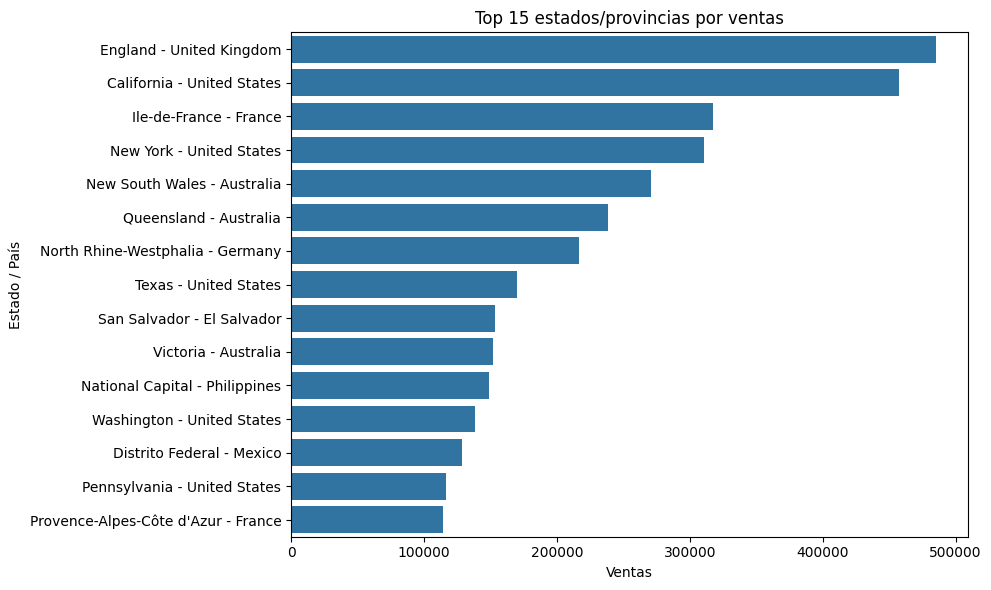

In [112]:
top_states_ventas = (
    resumen_state
    .sort_values(
        "ventas",
        ascending=False
    )
    .head(15)
    .copy()
)

top_states_ventas["state_contexto"] = (
    top_states_ventas["state"]
    + " - "
    + top_states_ventas["country"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_states_ventas,
    y="state_contexto",
    x="ventas"
)

plt.title(
    "Top 15 estados/provincias por ventas"
)

plt.xlabel("Ventas")
plt.ylabel("Estado / País")
plt.tight_layout()
plt.show()

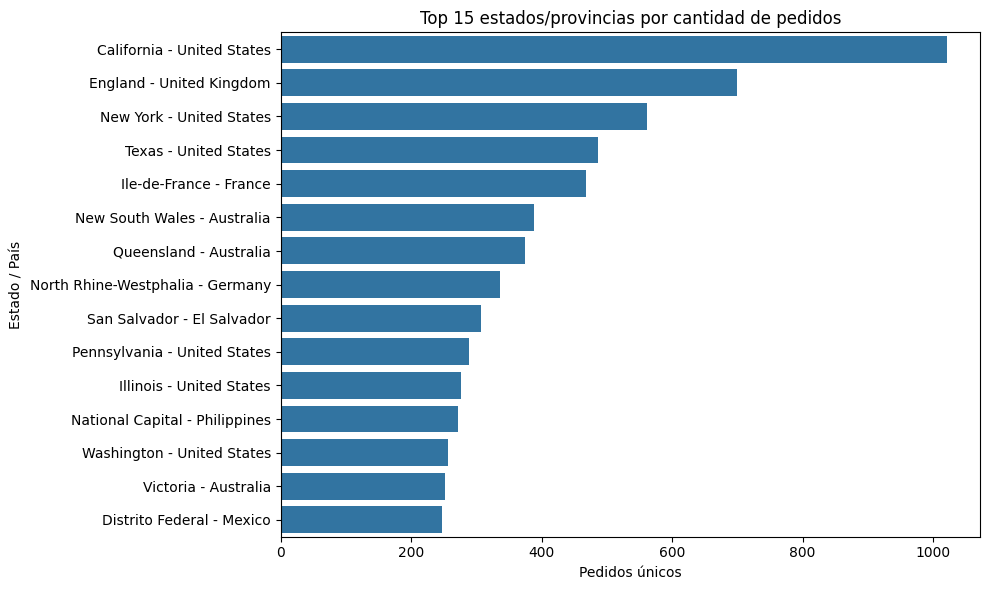

In [113]:
top_states_pedidos = (
    resumen_state
    .sort_values(
        "pedidos",
        ascending=False
    )
    .head(15)
    .copy()
)

top_states_pedidos["state_contexto"] = (
    top_states_pedidos["state"]
    + " - "
    + top_states_pedidos["country"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_states_pedidos,
    y="state_contexto",
    x="pedidos"
)

plt.title(
    "Top 15 estados/provincias por cantidad de pedidos"
)

plt.xlabel("Pedidos únicos")
plt.ylabel("Estado / País")
plt.tight_layout()
plt.show()

In [114]:
# Desempeño por segmento
resumen_segmento = (
    df_eda.groupby("segment")
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        cantidad=("quantity", "sum"),
        transacciones=("transaction_key", "nunique"),
        lineas=("segment", "size")
    )
)

resumen_segmento["margen_profit_pct"] = (
    resumen_segmento["profit"]
    / resumen_segmento["ventas"]
    * 100
)

resumen_segmento["participacion_ventas_pct"] = (
    resumen_segmento["ventas"]
    / resumen_segmento["ventas"].sum()
    * 100
)

display(
    resumen_segmento
    .sort_values("ventas", ascending=False)
    .round(2)
)

,ventas,profit,cantidad,transacciones,lineas,margen_profit_pct,participacion_ventas_pct
segment,,,,,,,
Consumer,6508141,749239.78,92157,13305,26518,11.51,51.48
Corporate,3824808,442785.86,53565,7732,15429,11.58,30.25
Home Office,2309956,277009.18,32590,4717,9343,11.99,18.27


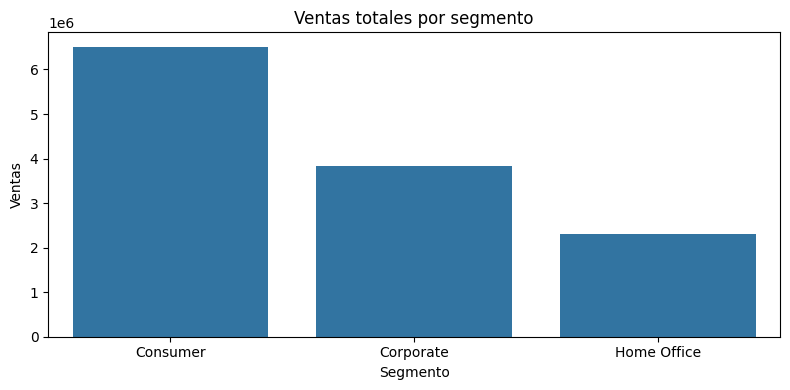

In [115]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=resumen_segmento.reset_index(),
    x="segment",
    y="ventas"
)

plt.title("Ventas totales por segmento")
plt.xlabel("Segmento")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()

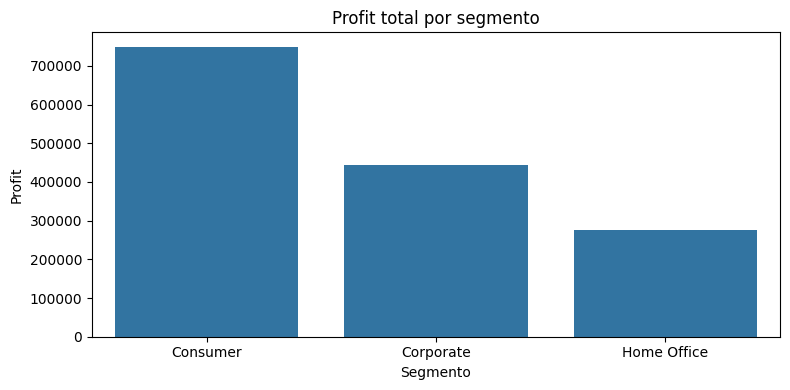

In [116]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=resumen_segmento.reset_index(),
    x="segment",
    y="profit"
)

plt.title("Profit total por segmento")
plt.xlabel("Segmento")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [117]:
# Relación segmento por mercado
segmento_market = (
    df_eda.groupby(["market", "segment"])
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

segmento_market["margen_profit_pct"] = (
    segmento_market["profit"]
    / segmento_market["ventas"]
    * 100
)

display(
    segmento_market
    .sort_values(["market", "ventas"], ascending=[True, False])
    .round(2)
)

,market,segment,ventas,profit,margen_profit_pct
0,APAC,Consumer,1816780,222817.56,12.26
1,APAC,Corporate,1078501,131314.76,12.18
2,APAC,Home Office,690552,83445.25,12.08
3,Africa,Consumer,423751,47772.10,11.27
4,Africa,Corporate,204948,20686.96,10.09
5,Africa,Home Office,155077,20412.57,13.16
6,Canada,Consumer,35717,9677.70,27.10
7,Canada,Corporate,19319,5036.46,26.07
8,Canada,Home Office,11896,3103.23,26.09
9,EMEA,Consumer,406763,25532.57,6.28


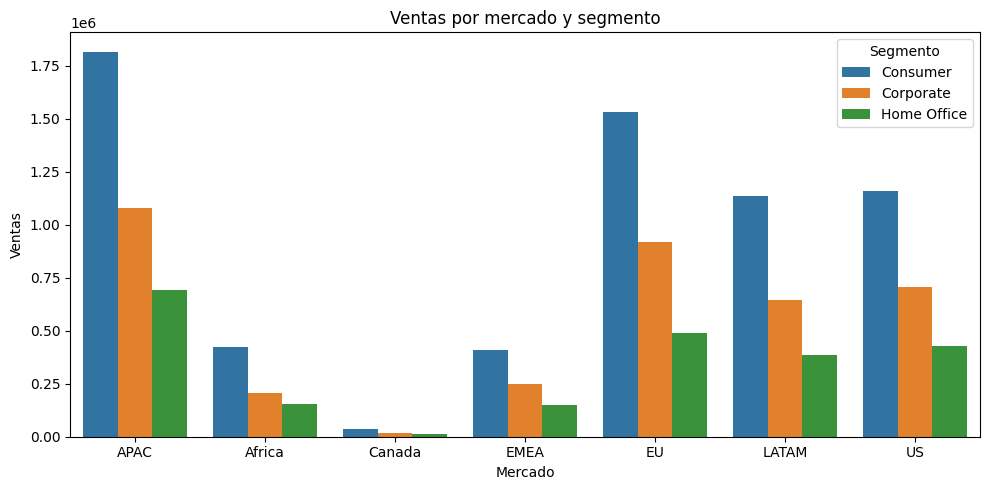

In [118]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=segmento_market,
    x="market",
    y="ventas",
    hue="segment"
)

plt.title("Ventas por mercado y segmento")
plt.xlabel("Mercado")
plt.ylabel("Ventas")
plt.legend(title="Segmento")
plt.tight_layout()
plt.show()

### Ticket promedio y frecuencia de compra por segmento

Debido a que `order_id` y `customer_name` no son identificadores globalmente inequívocos, para este análisis se utilizan claves contextuales auxiliares.

Estas claves se emplean únicamente con fines analíticos y no sustituyen a los identificadores originales del dataset.

In [119]:
segmento_analisis = df_eda.copy()

segmento_analisis["order_proxy"] = (
    segmento_analisis["order_id"].astype(str)
    + "|"
    + segmento_analisis["order_date"].astype(str)
    + "|"
    + segmento_analisis["customer_name"].astype(str)
    + "|"
    + segmento_analisis["market"].astype(str)
    + "|"
    + segmento_analisis["country"].astype(str)
)

segmento_analisis["customer_proxy_segment"] = (
    segmento_analisis["customer_name"].astype(str)
    + "|"
    + segmento_analisis["market"].astype(str)
    + "|"
    + segmento_analisis["country"].astype(str)
)

print(
    "Pedidos proxy únicos:",
    f"{segmento_analisis['order_proxy'].nunique():,}"
)

print(
    "Clientes proxy únicos:",
    f"{segmento_analisis['customer_proxy_segment'].nunique():,}"
)

Pedidos proxy únicos: 25,754
Clientes proxy únicos: 15,704


In [120]:
# Cálculo Ticket por pedido
pedidos_segmento = (
    segmento_analisis
    .groupby(
        [
            "order_proxy",
            "segment",
            "customer_proxy_segment"
        ]
    )
    .agg(
        ticket=("sales", "sum")
    )
    .reset_index()
)

display(
    pedidos_segmento.head()
)

,order_proxy,segment,customer_proxy_segment,ticket
0,AE-2011-9160|2011-10-03|Patrick O'Donnell|EMEA...,Consumer,Patrick O'Donnell|EMEA|United Arab Emirates,161
1,AE-2013-1130|2013-10-14|Eugene Barchas|EMEA|Un...,Consumer,Eugene Barchas|EMEA|United Arab Emirates,229
2,AE-2013-1530|2013-12-31|Maribeth Yedwab|EMEA|U...,Corporate,Maribeth Yedwab|EMEA|United Arab Emirates,24
3,AE-2014-2840|2014-11-05|Patrick Gardner|EMEA|U...,Consumer,Patrick Gardner|EMEA|United Arab Emirates,42
4,AE-2014-3830|2014-12-13|Greg Hansen|EMEA|Unite...,Consumer,Greg Hansen|EMEA|United Arab Emirates,280


In [121]:
# Ticket promedio por segmento
ticket_por_segmento = (
    pedidos_segmento
    .groupby("segment")
    .agg(
        pedidos=("order_proxy", "nunique"),
        ticket_promedio=("ticket", "mean"),
        ticket_mediano=("ticket", "median")
    )
    .sort_values(
        "ticket_promedio",
        ascending=False
    )
)

display(
    ticket_por_segmento.round(2)
)

,pedidos,ticket_promedio,ticket_mediano
segment,,,
Corporate,7732,494.67,200.0
Home Office,4717,489.71,195.0
Consumer,13305,489.15,204.0


In [122]:
# Frecuencia de compra por cliente y segmento
frecuencia_cliente = (
    pedidos_segmento
    .groupby(
        [
            "segment",
            "customer_proxy_segment"
        ]
    )
    .agg(
        cantidad_pedidos=(
            "order_proxy",
            "nunique"
        )
    )
    .reset_index()
)

frecuencia_por_segmento = (
    frecuencia_cliente
    .groupby("segment")
    .agg(
        clientes=(
            "customer_proxy_segment",
            "nunique"
        ),
        frecuencia_promedio=(
            "cantidad_pedidos",
            "mean"
        ),
        frecuencia_mediana=(
            "cantidad_pedidos",
            "median"
        )
    )
    .sort_values(
        "frecuencia_promedio",
        ascending=False
    )
)

display(
    frecuencia_por_segmento.round(2)
)

,clientes,frecuencia_promedio,frecuencia_mediana
segment,,,
Consumer,8089,1.64,1.0
Corporate,4713,1.64,1.0
Home Office,2902,1.63,1.0


In [123]:
# Tabla conjunta por segmento
resumen_comportamiento_segmento = (
    ticket_por_segmento
    .join(
        frecuencia_por_segmento,
        how="left"
    )
)

display(
    resumen_comportamiento_segmento.round(2)
)

,pedidos,ticket_promedio,ticket_mediano,clientes,frecuencia_promedio,frecuencia_mediana
segment,,,,,,
Corporate,7732,494.67,200.0,4713,1.64,1.0
Home Office,4717,489.71,195.0,2902,1.63,1.0
Consumer,13305,489.15,204.0,8089,1.64,1.0


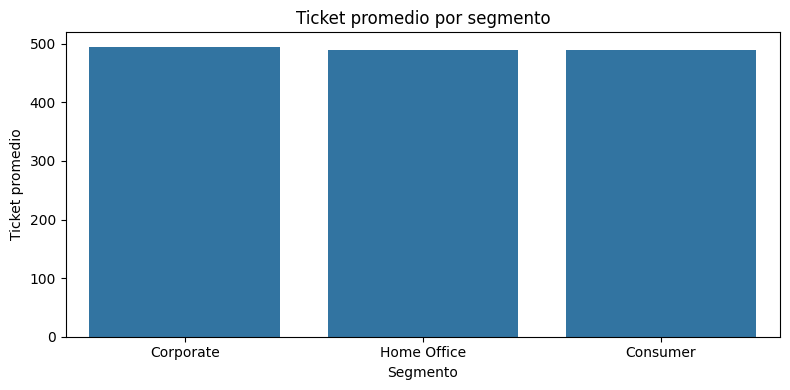

In [124]:
# Gráfico de Ticket promedio
plt.figure(figsize=(8, 4))

sns.barplot(
    data=(
        resumen_comportamiento_segmento
        .reset_index()
    ),
    x="segment",
    y="ticket_promedio"
)

plt.title(
    "Ticket promedio por segmento"
)

plt.xlabel("Segmento")
plt.ylabel("Ticket promedio")
plt.tight_layout()
plt.show()

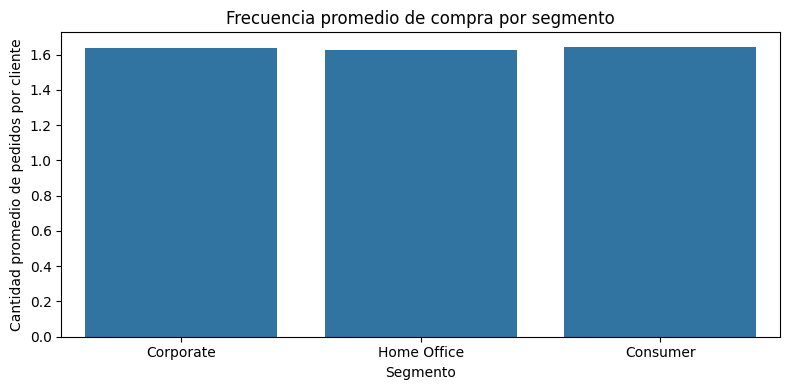

In [125]:
# Gráfico de frecuencia promedio
plt.figure(figsize=(8, 4))

sns.barplot(
    data=(
        resumen_comportamiento_segmento
        .reset_index()
    ),
    x="segment",
    y="frecuencia_promedio"
)

plt.title(
    "Frecuencia promedio de compra por segmento"
)

plt.xlabel("Segmento")
plt.ylabel("Cantidad promedio de pedidos por cliente")
plt.tight_layout()
plt.show()

### Conclusiones del comportamiento por segmento

El análisis mediante identificadores contextuales muestra un comportamiento comercial similar entre los tres segmentos.

- `Corporate` presenta el ticket promedio ligeramente más alto (494,67), seguido por `Home Office` (489,71) y `Consumer` (489,15).
- Las diferencias de ticket promedio son reducidas, por lo que el segmento no parece generar por sí solo perfiles de gasto marcadamente diferentes.
- Las medianas de ticket son considerablemente inferiores a las medias, lo que evidencia la influencia de pedidos de alto valor sobre la distribución.
- La frecuencia promedio de compra es prácticamente idéntica entre segmentos, alrededor de 1,6 pedidos por cliente proxy, y la mediana es de 1 pedido en los tres casos.
- Por lo tanto, el segmento aporta contexto de negocio, pero no muestra diferencias suficientemente fuertes como para utilizarlo de manera aislada como señal principal del sistema de recomendación.

Los identificadores utilizados en este análisis son proxies contextuales y no deben interpretarse como identificadores reales e inequívocos de clientes o pedidos.

In [126]:
# Validación final
region_market_check = (
    df_eda.groupby("region")["market"]
    .nunique()
    .sort_values(ascending=False)
)

print("Cantidad de mercados asociados a cada región:")
display(region_market_check.to_frame("mercados"))

print("\nRegiones asociadas a más de un mercado:")
display(
    region_market_check[
        region_market_check > 1
    ].to_frame("mercados")
)

Cantidad de mercados asociados a cada región:


,mercados
region,
Central,3
South,3
North,2
Africa,1
Canada,1
Central Asia,1
Caribbean,1
East,1
EMEA,1



Regiones asociadas a más de un mercado:


,mercados
region,
Central,3
South,3
North,2


In [127]:
display(
    df_eda[
        ["market", "region"]
    ]
    .drop_duplicates()
    .sort_values(["region", "market"])
)

,market,region
0,Africa,Africa
6,Canada,Canada
29,LATAM,Caribbean
30,EU,Central
15,LATAM,Central
38,US,Central
135,APAC,Central Asia
2,EMEA,EMEA
57,US,East
3,EU,North


In [128]:
df_eda["market_region"] = (
    df_eda["market"].astype(str)
    + " | "
    + df_eda["region"].astype(str)
)

print(
    "Combinaciones market-region únicas:",
    df_eda["market_region"].nunique()
)

Combinaciones market-region únicas: 18


In [129]:
resumen_market_region = (
    df_eda.groupby("market_region")
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        cantidad=("quantity", "sum"),
        transacciones=("transaction_key", "nunique"),
        lineas=("market_region", "size")
    )
)

resumen_market_region["margen_profit_pct"] = (
    resumen_market_region["profit"]
    / resumen_market_region["ventas"]
    * 100
)

resumen_market_region = resumen_market_region.sort_values(
    "ventas",
    ascending=False
)

display(resumen_market_region.round(2))

,ventas,profit,cantidad,transacciones,lineas,margen_profit_pct
market_region,,,,,,
EU | Central,1720582,215534.07,22111,2962,5822,12.53
APAC | Oceania,1100207,121666.64,12838,1744,3487,11.06
APAC | Southeast Asia,884438,17852.33,11822,1517,3129,2.02
APAC | North Asia,848349,165578.42,8851,1150,2338,19.52
EMEA | EMEA,806184,43897.97,11517,2543,5029,5.45
Africa | Africa,783776,88871.63,10564,2289,4587,11.34
APAC | Central Asia,752839,132480.19,7715,1026,2048,17.60
US | West,725514,108418.45,12266,1611,3203,14.94
US | East,678834,91522.78,10618,1401,2848,13.48


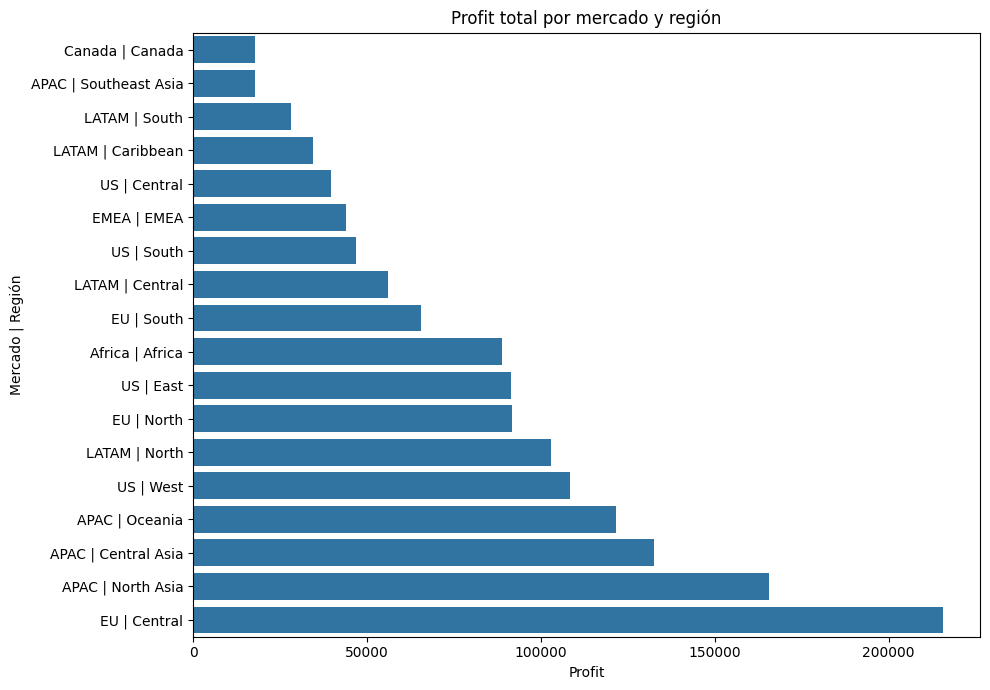

In [130]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=(
        resumen_market_region
        .reset_index()
        .sort_values("profit")
    ),
    y="market_region",
    x="profit"
)

plt.title("Profit total por mercado y región")
plt.xlabel("Profit")
plt.ylabel("Mercado | Región")
plt.tight_layout()
plt.show()

### Validación de la dimensión `region`

La variable `region` no constituye una dimensión geográfica globalmente única.

Se detectó que las etiquetas `Central`, `South` y `North` aparecen asociadas a más de un mercado:

- `Central`: EU, LATAM y US;
- `South`: EU, LATAM y US;
- `North`: EU y LATAM.

Por este motivo, los resultados obtenidos al agrupar únicamente por `region` deben interpretarse con cautela, ya que algunas etiquetas combinan zonas pertenecientes a mercados diferentes.

Para los análisis geográficos posteriores se adopta la combinación:

`market + region`

como nivel regional de análisis, preservando así la jerarquía geográfica del dataset.

### Conclusiones del análisis geográfico y por segmentos

El análisis evidencia diferencias relevantes en desempeño comercial según la dimensión geográfica, mientras que los segmentos de cliente presentan comportamientos globales mucho más homogéneos en términos de rentabilidad.

A nivel de mercado, `APAC` registra el mayor volumen comercial, con aproximadamente 3,59 millones en ventas y 437.578 de profit, equivalente a un margen del 12,20%. `EU` ocupa la segunda posición y presenta un margen del 12,69%. En conjunto, ambos mercados concentran aproximadamente el 51,6% de las ventas totales.

`EMEA` presenta un comportamiento comparativamente débil, con un margen de profit del 5,45%. En contraste, `Canada` registra un margen elevado del 26,62%, aunque representa
solo el 0,53% de las ventas totales, por lo que su alta rentabilidad debe interpretarse considerando su reducida escala comercial.

La auditoría de la variable `region` mostró que las etiquetas `Central`, `South` y `North` se reutilizan en diferentes mercados. Por este motivo se adoptó la combinación `market + region` como nivel regional de análisis, obteniéndose 18 combinaciones únicas.

Dentro de esta nueva definición, `EU | Central` presenta el mayor volumen de ventas y profit. También se observan márgenes elevados en `APAC | North Asia` (19,52%), `APAC | Central Asia` (17,60%) y `LATAM | North` (16,51%).

Por otro lado, algunas regiones muestran rentabilidad considerablemente menor, entre ellas `APAC | Southeast Asia` (2,02%), `LATAM | South` (4,55%) y `EMEA | EMEA`
(5,45%).

A nivel de país existen diferencias aún más marcadas. Estados Unidos lidera tanto en ventas como en profit total, mientras que países como China, India y United Kingdom presentan márgenes superiores al 20%.

También se identificaron países con profit acumulado negativo, entre ellos Turkey, Nigeria, Netherlands, Honduras, Pakistan y Argentina. El caso de Philippines resulta especialmente relevante porque aparece entre los países con mayores ventas y, sin embargo, presenta un profit negativo y un margen aproximado de -8,79%.

Estas pérdidas geográficas no se traducen en regiones completas con profit negativo, lo que indica que los resultados desfavorables de determinados países son compensados por otros países rentables pertenecientes a la misma región.

En cuanto a los segmentos de clientes, `Consumer` concentra aproximadamente el 51,5% de las ventas, seguido por `Corporate` con cerca del 30,3 % y `Home Office` con el
18,3%. Estas proporciones son prácticamente equivalentes a su participación en las líneas de transacción.

Los márgenes globales de los tres segmentos son muy similares:

- `Consumer`: 11,51%;
- `Corporate`: 11,58%;
- `Home Office`: 11,99%.

Por lo tanto, el mayor volumen de ventas y profit del segmento `Consumer` se explica principalmente por su mayor nivel de actividad y no por una rentabilidad proporcional
significativamente superior.

Al analizar conjuntamente mercado y segmento se observa que `Consumer` lidera las ventas en todos los mercados, mientras que las diferencias de margen se encuentran asociadas
con mayor fuerza a la dimensión geográfica.

En consecuencia, los resultados sugieren que la geografía constituye una dimensión más relevante que el segmento para explicar diferencias de rentabilidad dentro del dataset.

## 7. Relaciones entre variables e insights de negocio

En este bloque se analizan relaciones entre las principales variables comerciales con el objetivo de profundizar los hallazgos obtenidos durante el EDA.

Se estudia especialmente:

- relación entre ventas y profit;
- relación entre descuento y rentabilidad;
- frecuencia de operaciones con pérdida según nivel de descuento;
- comportamiento de la subcategoría `Tables`;
- diferencias entre subcategorías respecto de descuento y pérdidas.

Las asociaciones observadas se interpretarán de forma descriptiva y no como relaciones causales.

In [131]:
# Correlaciones
variables_relaciones = [
    "sales",
    "quantity",
    "discount",
    "profit",
    "shipping_cost",
    "shipping_days"
]

correlacion_pearson = (
    df_eda[variables_relaciones]
    .corr(method="pearson")
)

correlacion_spearman = (
    df_eda[variables_relaciones]
    .corr(method="spearman")
)

print("Correlación de Pearson:")
display(correlacion_pearson.round(3))

print("\nCorrelación de Spearman:")
display(correlacion_spearman.round(3))

Correlación de Pearson:


,sales,quantity,discount,profit,shipping_cost,shipping_days
sales,1.000,0.314,-0.087,0.486,0.768,-0.005
quantity,0.314,1.000,-0.020,0.105,0.273,0.004
discount,-0.087,-0.020,1.000,-0.316,-0.079,-0.002
profit,0.486,0.105,-0.316,1.000,0.357,0.002
shipping_cost,0.768,0.273,-0.079,0.357,1.000,-0.143
shipping_days,-0.005,0.004,-0.002,0.002,-0.143,1.000



Correlación de Spearman:


,sales,quantity,discount,profit,shipping_cost,shipping_days
sales,1.000,0.416,-0.100,0.490,0.913,-0.000
quantity,0.416,1.000,0.018,0.202,0.379,0.004
discount,-0.100,0.018,1.000,-0.596,-0.094,-0.002
profit,0.490,0.202,-0.596,1.000,0.450,0.001
shipping_cost,0.913,0.379,-0.094,0.450,1.000,-0.156
shipping_days,-0.000,0.004,-0.002,0.001,-0.156,1.000


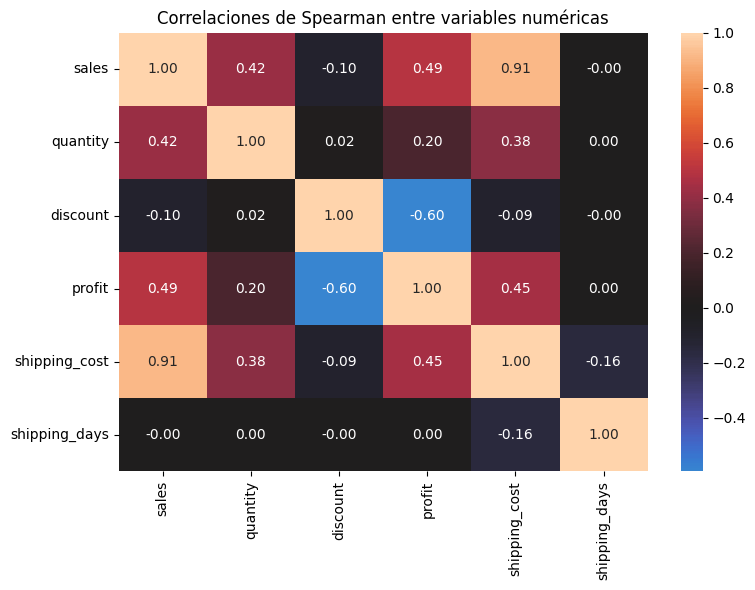

In [132]:
# Mapa de correlaciones
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion_spearman,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlaciones de Spearman entre variables numéricas")
plt.tight_layout()
plt.show()

In [133]:
df_eda["profit_negativo"] = df_eda["profit"] < 0

In [134]:
resumen_discount = (
    df_eda.groupby("discount")
    .agg(
        lineas=("discount", "size"),
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        profit_promedio=("profit", "mean"),
        operaciones_perdida=("profit_negativo", "sum")
    )
    .reset_index()
)

resumen_discount["margen_profit_pct"] = (
    resumen_discount["profit"]
    / resumen_discount["ventas"]
    * 100
)

resumen_discount["operaciones_perdida_pct"] = (
    resumen_discount["operaciones_perdida"]
    / resumen_discount["lineas"]
    * 100
)

display(resumen_discount.round(2))

,discount,lineas,ventas,profit,profit_promedio,operaciones_perdida,margen_profit_pct,operaciones_perdida_pct
0,0.00,29009,6992734,1770695.27,61.04,0,25.32,0.00
1,0.00,461,261395,57976.58,125.76,13,22.18,2.82
2,0.07,150,121620,21148.50,140.99,30,17.39,20.00
3,0.10,4068,1579618,260641.71,64.07,857,16.50,21.07
4,0.15,541,306037,27375.90,50.60,200,8.95,36.97
5,0.17,735,247404,28163.07,38.32,236,11.38,32.11
6,0.20,4998,1203855,117715.87,23.55,1027,9.78,20.55
7,0.20,41,16213,-595.27,-14.52,25,-3.67,60.98
8,0.25,198,88063,800.59,4.04,98,0.91,49.49
9,0.27,388,89351,-1675.08,-4.32,197,-1.87,50.77


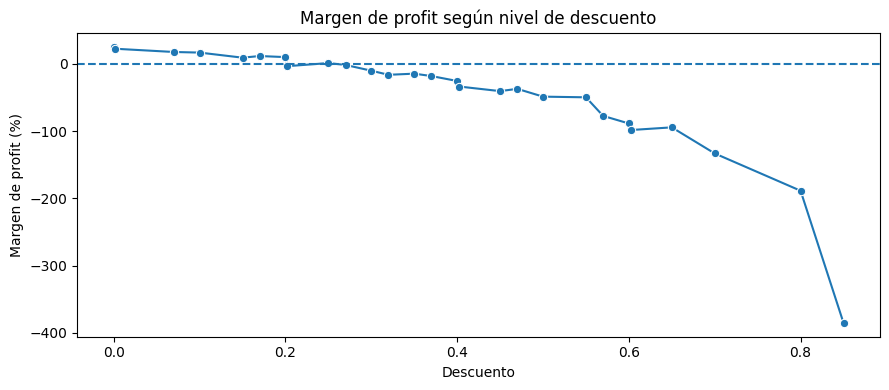

In [135]:
# Descuento vs margen y pérdida
plt.figure(figsize=(9, 4))

sns.lineplot(
    data=resumen_discount,
    x="discount",
    y="margen_profit_pct",
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Margen de profit según nivel de descuento")
plt.xlabel("Descuento")
plt.ylabel("Margen de profit (%)")
plt.tight_layout()
plt.show()

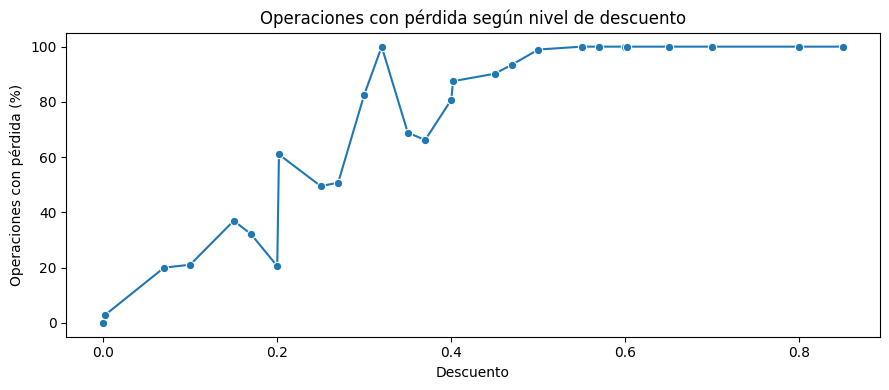

In [136]:
plt.figure(figsize=(9, 4))

sns.lineplot(
    data=resumen_discount,
    x="discount",
    y="operaciones_perdida_pct",
    marker="o"
)

plt.title("Operaciones con pérdida según nivel de descuento")
plt.xlabel("Descuento")
plt.ylabel("Operaciones con pérdida (%)")
plt.tight_layout()
plt.show()

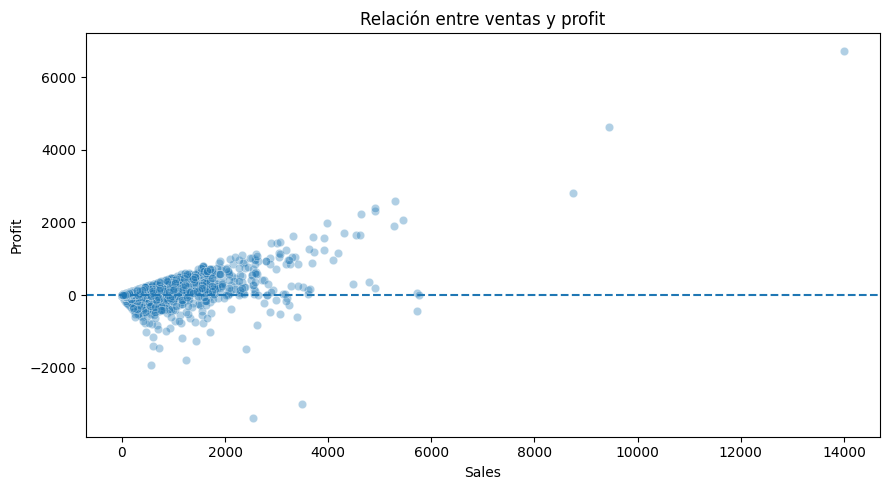

In [137]:
# Relación entre tamaño de vta y profit
muestra_scatter = df_eda.sample(
    n=min(10000, len(df_eda)),
    random_state=42
)

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=muestra_scatter,
    x="sales",
    y="profit",
    alpha=0.35
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Relación entre ventas y profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [138]:
tables_discount = (
    df_eda[df_eda["sub_category"] == "Tables"]
    .groupby("discount")
    .agg(
        lineas=("discount", "size"),
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        profit_promedio=("profit", "mean"),
        operaciones_perdida=("profit_negativo", "sum")
    )
    .reset_index()
)

tables_discount["margen_profit_pct"] = (
    tables_discount["profit"]
    / tables_discount["ventas"]
    * 100
)

tables_discount["operaciones_perdida_pct"] = (
    tables_discount["operaciones_perdida"]
    / tables_discount["lineas"]
    * 100
)

display(tables_discount.round(2))

,discount,lineas,ventas,profit,profit_promedio,operaciones_perdida,margen_profit_pct,operaciones_perdida_pct
0,0.00,208,261807,60447.20,290.61,0,23.09,0.00
1,0.10,3,3481,795.03,265.01,0,22.84,0.00
2,0.20,183,157721,7215.54,39.43,72,4.57,39.34
3,0.30,116,104747,-11960.48,-103.11,90,-11.42,77.59
4,0.35,45,54159,-9122.65,-202.73,34,-16.84,75.56
5,0.40,85,52162,-17105.18,-201.24,81,-32.79,95.29
6,0.45,13,8032,-3596.30,-276.64,13,-44.77,100.00
7,0.47,34,32502,-10680.28,-314.13,33,-32.86,97.06
8,0.50,52,26505,-15049.86,-289.42,51,-56.78,98.08
9,0.55,10,6308,-3150.67,-315.07,10,-49.95,100.00


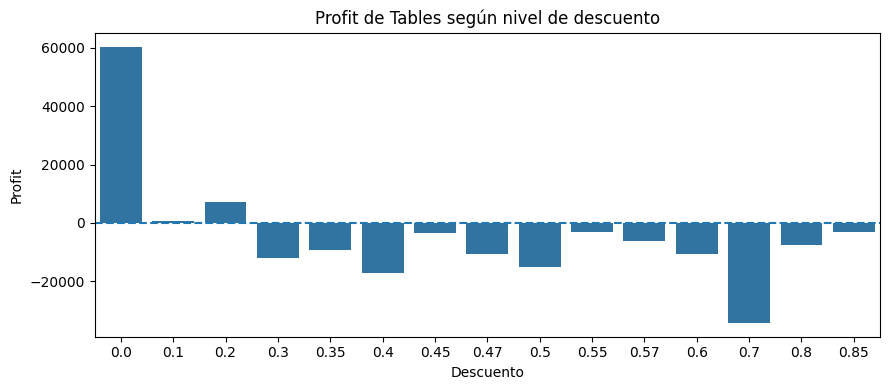

In [139]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=tables_discount,
    x="discount",
    y="profit"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Profit de Tables según nivel de descuento")
plt.xlabel("Descuento")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [140]:
relacion_subcategorias = (
    df_eda.groupby("sub_category")
    .agg(
        ventas=("sales", "sum"),
        profit=("profit", "sum"),
        descuento_promedio=("discount", "mean"),
        operaciones_perdida_pct=(
            "profit_negativo",
            "mean"
        )
    )
)

relacion_subcategorias["margen_profit_pct"] = (
    relacion_subcategorias["profit"]
    / relacion_subcategorias["ventas"]
    * 100
)

relacion_subcategorias["operaciones_perdida_pct"] *= 100

display(
    relacion_subcategorias
    .sort_values("margen_profit_pct")
    .round(2)
)

,ventas,profit,descuento_promedio,operaciones_perdida_pct,margen_profit_pct
sub_category,,,,,
Tables,757034,-64083.39,0.29,57.61,-8.47
Machines,779071,58867.87,0.17,30.55,7.56
Supplies,243090,22583.26,0.13,24.29,9.29
Chairs,1501682,141973.80,0.16,32.00,9.45
Storage,1127124,108461.49,0.14,27.28,9.62
Bookcases,1466559,161924.42,0.15,29.74,11.04
Furnishings,385609,46967.43,0.15,25.36,12.18
Phones,1706874,216717.01,0.15,23.50,12.70
Fasteners,83254,11525.42,0.14,25.29,13.84


In [141]:
print("Valores exactos de discount:\n")

for valor in sorted(df_eda["discount"].unique()):
    print(f"{valor:.6f}")

Valores exactos de discount:

0.000000
0.002000
0.070000
0.100000
0.150000
0.170000
0.200000
0.202000
0.250000
0.270000
0.300000
0.320000
0.350000
0.370000
0.400000
0.402000
0.450000
0.470000
0.500000
0.550000
0.570000
0.600000
0.602000
0.650000
0.700000
0.800000
0.850000


In [142]:
frecuencia_discount_exacta = (
    df_eda["discount"]
    .value_counts()
    .sort_index()
    .rename_axis("discount")
    .to_frame("lineas")
)

display(frecuencia_discount_exacta)

,lineas
discount,
0.000,29009
0.002,461
0.070,150
0.100,4068
0.150,541
0.170,735
0.200,4998
0.202,41
0.250,198


### Conclusiones del análisis de relaciones e insights de negocio

El análisis multivariable evidencia relaciones relevantes entre ventas, descuentos y rentabilidad.

Las variables `sales` y `profit` presentan una asociación positiva moderada, con coeficientes cercanos a 0,49 tanto para Pearson como para Spearman. Esto indica que las operaciones de mayor valor tienden a generar mayores beneficios, aunque existen numerosas excepciones y ventas elevadas que producen resultados negativos.

La relación entre `discount` y `profit` presenta un comportamiento claramente negativo. La correlación de Spearman alcanza aproximadamente -0,60, mostrando que a medida que
aumenta el nivel de descuento el profit tiende a disminuir.

El análisis por nivel de descuento refuerza este resultado. Con descuentos bajos, los márgenes agregados son positivos y la proporción de operaciones con pérdida es reducida. A medida que el descuento aumenta, el margen disminuye y crece fuertemente la proporción de líneas deficitarias. En varios niveles iguales o superiores al 60%, el 100% de las operaciones analizadas presenta profit negativo.

Los niveles de descuento fueron auditados y se comprobó que valores aparentemente duplicados en tablas redondeadas, como 0,00, 0,20, 0,40 o 0,60, corresponden en realidad
a valores distintos del dataset, por ejemplo 0,000 y 0,002, 0,200 y 0,202, 0,400 y 0,402, y 0,600 y 0,602. Por lo tanto, estos valores se mantienen sin modificaciones.

El comportamiento de la subcategoría `Tables` resulta especialmente significativo. Aunque presenta un profit acumulado de -64.083,39 y un margen global de -8,47%, las operaciones sin descuento o con descuentos bajos mantienen márgenes positivos.

A partir de niveles próximos al 30% de descuento, el profit agregado de `Tables` se vuelve negativo y la proporción de operaciones con pérdida aumenta de manera marcada.
La subcategoría presenta un descuento promedio cercano al 29 % y aproximadamente el 57,61% de sus líneas genera pérdidas.

Por lo tanto, la baja rentabilidad de `Tables` no debe interpretarse simplemente como una característica intrínseca de la subcategoría, sino como un resultado fuertemente asociado con su exposición a niveles elevados de descuento.

También se observa que subcategorías con menores descuentos promedio, como `Paper`, `Labels` y `Accessories`, presentan márgenes considerablemente superiores.

En conjunto, los resultados sugieren que la política de descuentos constituye una variable comercial relevante para comprender las diferencias de rentabilidad observadas en el dataset. Sin embargo, dado el carácter exploratorio del análisis, estas relaciones deben interpretarse como asociaciones descriptivas y no como evidencia de causalidad.

## 8. Conclusiones generales del EDA

En esta sección se consolidan los principales hallazgos obtenidos durante el análisis exploratorio de datos y se documentan las decisiones metodológicas adoptadas.

El objetivo final es establecer:

- las principales características comerciales del dataset;
- los patrones temporales, geográficos y de rentabilidad detectados;
- las limitaciones identificadas en las claves originales;
- las implicancias de estos hallazgos para el futuro sistema de recomendación;
- las decisiones que deberán mantenerse o revisarse en las siguientes etapas del proyecto.

No se incorporan nuevos análisis exploratorios en esta sección.

In [143]:
# Validación final de integridad del dataset

print("VALIDACIÓN FINAL DE INTEGRIDAD\n")

print(f"Dataset original:")
print(f"- Filas: {df.shape[0]:,}")
print(f"- Columnas: {df.shape[1]}")

print(f"\nCopia utilizada para EDA:")
print(f"- Filas: {df_eda.shape[0]:,}")
print(f"- Columnas: {df_eda.shape[1]}")

print("\nControles:")

print(
    "- Se conservaron todas las filas:",
    len(df_eda) == len(df)
)

print(
    "- order_date sin nulos:",
    df_eda["order_date"].notna().all()
)

print(
    "- ship_date sin nulos:",
    df_eda["ship_date"].notna().all()
)

print(
    "- sales sin nulos:",
    df_eda["sales"].notna().all()
)

print(
    "- Duplicados exactos en dataset original:",
    df.duplicated().sum()
)

VALIDACIÓN FINAL DE INTEGRIDAD

Dataset original:
- Filas: 51,290
- Columnas: 21

Copia utilizada para EDA:
- Filas: 51,290
- Columnas: 28

Controles:
- Se conservaron todas las filas: True
- order_date sin nulos: True
- ship_date sin nulos: True
- sales sin nulos: True
- Duplicados exactos en dataset original: 0


In [144]:
resumen_final_eda = pd.Series({
    "filas_dataset": len(df),
    "columnas_originales": df.shape[1],
    "fecha_inicial": df_eda["order_date"].min().date(),
    "fecha_final": df_eda["order_date"].max().date(),
    "transacciones_unicas": df_eda["transaction_key"].nunique(),
    "customer_proxies": (
        df_eda[["customer_name", "market"]]
        .drop_duplicates()
        .shape[0]
    ),
    "items_unicos": df_eda["item_id_name"].nunique(),
    "ventas_totales": df_eda["sales"].sum(),
    "profit_total": df_eda["profit"].sum(),
    "margen_global_pct": (
        df_eda["profit"].sum()
        / df_eda["sales"].sum()
        * 100
    ),
    "lineas_profit_negativo": (
        df_eda["profit"] < 0
    ).sum(),
    "lineas_profit_negativo_pct": (
        (df_eda["profit"] < 0).mean() * 100
    ),
    "subcategorias_profit_negativo": (
        resumen_subcategoria["profit"] < 0
    ).sum(),
    "paises_profit_negativo": (
        resumen_pais["profit"] < 0
    ).sum()
})

display(
    resumen_final_eda.to_frame("resultado")
)

,resultado
filas_dataset,51290
columnas_originales,21
fecha_inicial,2011-01-01
fecha_final,2014-12-31
transacciones_unicas,25754
customer_proxies,4872
items_unicos,10768
ventas_totales,12642905
profit_total,1469034.82128
margen_global_pct,11.61944


### Conclusiones generales del análisis exploratorio

El dataset SuperStoreOrders presenta información suficiente y relevante para continuar el desarrollo del proyecto y profundizar posteriormente en la construcción de un sistema
de recomendación.

El dataset original contiene 51.290 líneas y 21 variables, con cobertura temporal desde el 1 de enero de 2011 hasta el 31 de diciembre de 2014. No se detectaron valores nulos
ni registros completamente duplicados. Las variables de fecha pudieron convertirse correctamente y la variable `sales`, originalmente interpretada como texto debido al uso
de separadores de miles, pudo transformarse íntegramente a formato numérico.

El análisis temporal muestra un crecimiento sostenido de la actividad comercial entre 2011 y 2014. Las ventas aumentaron desde aproximadamente 2,26 millones en 2011 hasta
4,30 millones en 2014, mientras que el número de transacciones pasó de 4.516 a 8.868. El profit también creció durante todo el período y el margen global anual se mantuvo
aproximadamente entre el 11% y el 12%.

Asimismo, se identificó un patrón estacional descriptivo. Al normalizar las ventas de cada mes respecto del total de su propio año, aproximadamente el 61,7 % de las ventas
se concentra en promedio durante el segundo semestre. Noviembre y diciembre presentan las mayores participaciones promedio, mientras que enero y febrero se encuentran entre
los meses de menor actividad.

El análisis por categoría demostró que frecuencia, volumen de ventas y rentabilidad son dimensiones diferentes. `Office Supplies` concentra aproximadamente el 60,97% de las
líneas, pero representa alrededor del 29,96% de las ventas. `Technology`, en cambio, concentra menos del 20% de las líneas pero genera aproximadamente el 37,53% de las ventas y presenta el mayor profit total.

`Furniture` registra un volumen comercial importante, pero presenta un margen considerablemente inferior al de las otras dos categorías. Dentro de ella, `Tables` constituye el principal caso de baja rentabilidad, con aproximadamente 757.034 en ventas, un profit de -64.083,39 y un margen agregado de -8,47%.

El análisis posterior mostró que este comportamiento de `Tables` está fuertemente asociado con el nivel de descuento. Las operaciones con descuentos bajos mantienen márgenes
positivos, mientras que desde niveles próximos al 30% el profit agregado comienza a ser negativo y aumenta fuertemente la proporción de operaciones con pérdida.

En el dataset completo también se detecta una asociación negativa clara entre `discount` y `profit`. La correlación de Spearman es aproximadamente -0,60 y los niveles elevados
de descuento presentan una proporción considerablemente mayor de operaciones deficitarias. Este resultado constituye una asociación descriptiva y no debe interpretarse como una
relación causal demostrada.

El análisis geográfico también muestra diferencias importantes. APAC presenta el mayor volumen comercial, seguido por EU, mientras que EMEA presenta un margen comparativamente
bajo.
A nivel de país se identifican importantes diferencias de rentabilidad. De los 147 países presentes en el dataset, 29 registran profit agregado negativo, mientras que otros presentan márgenes considerablemente elevados. Esto confirma que la rentabilidad comercial presenta una marcada heterogeneidad geográfica.

La variable `region` no constituye una dimensión geográfica globalmente única, debido a que etiquetas como `Central`, `South` y `North` aparecen en distintos mercados. Para
evitar mezclar regiones diferentes se adoptó la combinación `market + region` como nivel regional de análisis.

Por segmento de cliente, `Consumer` concentra aproximadamente la mitad de las ventas, seguido por `Corporate` y `Home Office`. Sin embargo, los tres segmentos presentan márgenes globales muy similares, por lo que las diferencias de profit se explican principalmente por diferencias de volumen y no por una rentabilidad proporcional sustancialmente distinta.

### Decisiones metodológicas adoptadas

Durante la validación estructural y el EDA se identificó que algunas variables que aparentemente podían utilizarse como identificadores no constituyen claves globalmente únicas.

#### Transacciones

`order_id` no identifica de forma inequívoca una transacción dentro del dataset.

Para los análisis se adoptó como clave transaccional auxiliar:

`order_id + order_date + customer_name`

Esta definición permitió identificar 25.754 transacciones únicas.

#### Clientes

`customer_name` no representa una identificación global única de cliente, ya que los mismos nombres aparecen asociados a múltiples países y mercados.

Para los análisis preliminares relacionados con el sistema de recomendación se utiliza como proxy:

`customer_name + market`

Esta definición genera 4.872 customer proxies y proporciona mayor consistencia que utilizar únicamente el nombre.

Debe considerarse una solución analítica provisional y no un identificador real de cliente.

#### Productos

`product_id` tampoco presenta una correspondencia global uno a uno con `product_name`.

Para distinguir los ítems durante el EDA se utiliza la combinación:

`product_id + product_name`

Esta definición genera 10.768 ítems distintos.

Al igual que la definición de cliente, deberá reevaluarse durante las etapas de preparación de datos y construcción del recomendador.

#### Geografía

La variable `region` reutiliza determinadas etiquetas en diferentes mercados.

Por este motivo se utiliza:

`market + region`

como dimensión regional, obteniéndose 18 combinaciones únicas.

Estas decisiones permiten reducir ambigüedades en las unidades de análisis sin modificar el dataset original.

### Implicancias para el sistema de recomendación

El dataset presenta características que permiten avanzar hacia la construcción de un sistema de recomendación, aunque existen desafíos que deberán ser considerados durante
el modelado.

La matriz potencial cliente-producto presenta una elevada esparsidad, superior al 99%, por lo que la mayoría de las combinaciones posibles entre customer proxies e ítems no
posee interacción observada.

Al mismo tiempo, existe suficiente historial para realizar experimentación: se identificaron miles de customer proxies con múltiples transacciones y una cantidad significativa de pedidos contiene más de un producto, permitiendo estudiar patrones de coocurrencia.

La elevada esparsidad puede limitar el desempeño de enfoques exclusivamente colaborativos, por lo que será conveniente comparar diferentes estrategias y considerar eventualmente
modelos basados en contenido o enfoques híbridos.

Además, el EDA demuestra que popularidad, ventas y rentabilidad no son conceptos equivalentes. Existen productos con ventas elevadas pero profit negativo, mientras que
otros productos menos frecuentes presentan márgenes elevados.

Por este motivo, la calidad de una recomendación no debería evaluarse únicamente en función de la popularidad del producto. Las métricas comerciales podrán utilizarse como
información complementaria o como reglas de negocio, evitando confundir el objetivo predictivo del recomendador con el objetivo económico de la empresa.

Finalmente, variables como categoría, subcategoría, mercado, región y patrones históricos de interacción constituyen fuentes potencialmente útiles para la construcción de features en las siguientes etapas del proyecto.

### Limitaciones identificadas

El análisis presenta algunas limitaciones que deben considerarse durante las siguientes etapas del proyecto.

- El dataset no contiene un identificador global inequívoco de cliente.
- `product_id` no presenta una correspondencia uno a uno con `product_name`.
- `order_id` no constituye una clave transaccional global.
- Las variables auxiliares utilizadas para resolver estas situaciones representan
  decisiones analíticas y no identificadores reales del sistema de origen.
- La elevada esparsidad de la matriz cliente-producto puede dificultar ciertos enfoques
  de filtrado colaborativo.
- El análisis temporal cubre solamente cuatro años, por lo que los patrones estacionales
  detectados se consideran descriptivos.
- Las asociaciones observadas entre descuento y rentabilidad no permiten establecer
  causalidad.
- La existencia de productos y países con profit negativo requiere analizar contexto
  comercial adicional antes de transformar estos hallazgos en reglas definitivas de negocio.
- El EDA se realizó sobre una copia de trabajo y las variables auxiliares creadas no
  implican modificaciones del archivo raw original.

Estas limitaciones no invalidan el dataset, pero condicionan la forma en que deberán interpretarse y utilizarse los datos durante el desarrollo del sistema de recomendación.

### Conclusión de viabilidad

A partir de la validación estructural y del análisis exploratorio realizado, se concluye que el dataset es viable para continuar con el desarrollo del proyecto.

Existe suficiente información transaccional, comercial, temporal, geográfica y de producto para construir perfiles de interacción y experimentar con distintas estrategias
de recomendación.

Las inconsistencias detectadas en los identificadores originales no impiden continuar, pero requieren mantener las claves auxiliares y supuestos documentados durante las
siguientes etapas.

El próximo paso será transformar los hallazgos del EDA en una estrategia de preparación de datos y feature engineering orientada al sistema de recomendación.

# 03 - EDA específico del Sistema de Recomendación

## 1. Preparación y Construcción de la tabla de interacciones Cliente-Producto

El objetivo de esta sección es caracterizar la estructura de interacción entre clientes y productos que servirá como base para el sistema de recomendación.

A partir de las auditorías realizadas previamente, se utilizarán las siguientes definiciones:

- **Cliente:** `customer_proxy`, construido mediante `customer_name + market`.
- **Producto:** `item_id_name`, construido mediante `product_id + product_name`.
- **Transacción:** `transaction_key`, construida mediante `order_id + order_date + customer_name`.

Una interacción representa la compra de un producto por parte de un cliente proxy dentro de una transacción. Posteriormente, estas interacciones se agregarán a nivel cliente-producto para conservar tanto la existencia de la relación como su recurrencia.

In [145]:
# Crear una copia específica para el EDA del recomendador
df_rec = df_eda.copy()

# Identificador compuesto de transacción
df_rec["transaction_key"] = (
    df_rec["order_id"].astype(str)
    + "|"
    + df_rec["order_date"].dt.strftime("%Y-%m-%d")
    + "|"
    + df_rec["customer_name"].astype(str)
)

# Identificador proxy de cliente
df_rec["customer_proxy"] = (
    df_rec["customer_name"].astype(str)
    + "|"
    + df_rec["market"].astype(str)
)

# Identificador compuesto de producto
df_rec["item_id_name"] = (
    df_rec["product_id"].astype(str)
    + "|"
    + df_rec["product_name"].astype(str)
)

print("Dataset preparado para el EDA del recomendador.")
print(f"Filas: {df_rec.shape[0]:,}")
print(f"Transacciones únicas: {df_rec['transaction_key'].nunique():,}")
print(f"Clientes proxy únicos: {df_rec['customer_proxy'].nunique():,}")
print(f"Productos únicos: {df_rec['item_id_name'].nunique():,}")

Dataset preparado para el EDA del recomendador.
Filas: 51,290
Transacciones únicas: 25,754
Clientes proxy únicos: 4,872
Productos únicos: 10,768


In [146]:
# Verificar si una misma combinación transacción-producto aparece más de una vez en el dataset
duplicados_evento = df_rec.duplicated(
    subset=["transaction_key", "item_id_name"]
).sum()

print(
    "Registros repetidos para la misma combinación "
    "transacción-producto:",
    f"{duplicados_evento:,}"
)

Registros repetidos para la misma combinación transacción-producto: 33


In [147]:
interacciones_evento = (
    df_rec
    .groupby(
        [
            "customer_proxy",
            "transaction_key",
            "item_id_name"
        ],
        as_index=False
    )
    .agg(
        order_date=("order_date", "min"),
        quantity=("quantity", "sum"),
        sales=("sales", "sum")
    )
)

print("Tabla de eventos de interacción creada.")
print(f"Eventos cliente-producto-transacción: {len(interacciones_evento):,}")

display(interacciones_evento.head())

Tabla de eventos de interacción creada.
Eventos cliente-producto-transacción: 51,257


,customer_proxy,transaction_key,item_id_name,order_date,quantity,sales
0,Aaron Bergman|APAC,ID-2012-28780|2012-12-28|Aaron Bergman,"FUR-FU-10000666|Rubbermaid Frame, Black",2012-12-28,7,562
1,Aaron Bergman|APAC,ID-2012-28780|2012-12-28|Aaron Bergman,"OFF-BI-10000590|Wilson Jones Binding Machine, ...",2012-12-28,5,201
2,Aaron Bergman|APAC,ID-2012-28780|2012-12-28|Aaron Bergman,"OFF-BI-10004436|Acco Hole Reinforcements, Recy...",2012-12-28,4,23
3,Aaron Bergman|APAC,ID-2012-28780|2012-12-28|Aaron Bergman,"TEC-CO-10000660|Brother Fax and Copier, Laser",2012-12-28,2,241
4,Aaron Bergman|APAC,ID-2012-28780|2012-12-28|Aaron Bergman,"TEC-CO-10003924|Hewlett Fax Machine, Digital",2012-12-28,2,403


In [148]:
tabla_interacciones = (
    interacciones_evento
    .groupby(
        ["customer_proxy", "item_id_name"],
        as_index=False
    )
    .agg(
        n_interacciones=("transaction_key", "nunique"),
        cantidad_total=("quantity", "sum"),
        ventas_totales=("sales", "sum"),
        primera_interaccion=("order_date", "min"),
        ultima_interaccion=("order_date", "max")
    )
)

# Variable binaria que indica que la relación cliente-producto existe
tabla_interacciones["interaccion_binaria"] = 1

print("Tabla cliente-producto construida correctamente.")
print(f"Filas de la tabla: {len(tabla_interacciones):,}")

display(tabla_interacciones.head())

Tabla cliente-producto construida correctamente.
Filas de la tabla: 51,093


,customer_proxy,item_id_name,n_interacciones,cantidad_total,ventas_totales,primera_interaccion,ultima_interaccion,interaccion_binaria
0,Aaron Bergman|APAC,"FUR-BO-10001192|Bush Library with Doors, Mobile",1,2,660,2013-10-29,2013-10-29,1
1,Aaron Bergman|APAC,"FUR-BO-10001860|Sauder Corner Shelving, Tradit...",1,2,186,2014-02-10,2014-02-10,1
2,Aaron Bergman|APAC,"FUR-BO-10003945|Sauder 3-Shelf Cabinet, Metal",1,3,449,2013-06-25,2013-06-25,1
3,Aaron Bergman|APAC,FUR-CH-10003581|Hon Executive Leather Armchair...,1,5,2046,2013-06-25,2013-06-25,1
4,Aaron Bergman|APAC,"FUR-CH-10004163|Novimex Steel Folding Chair, A...",1,2,152,2013-06-25,2013-06-25,1


In [149]:
# Validaciones de la tabla cliente-producto

pares_duplicados = tabla_interacciones.duplicated(
    subset=["customer_proxy", "item_id_name"]
).sum()

print("Validación de tabla de interacciones:\n")

print(
    f"Pares cliente-producto únicos: "
    f"{len(tabla_interacciones):,}"
)

print(
    f"Pares duplicados: "
    f"{pares_duplicados:,}"
)

print(
    f"Clientes representados: "
    f"{tabla_interacciones['customer_proxy'].nunique():,}"
)

print(
    f"Productos representados: "
    f"{tabla_interacciones['item_id_name'].nunique():,}"
)

print(
    f"Interacciones recurrentes "
    f"(cliente-producto con más de una compra): "
    f"{(tabla_interacciones['n_interacciones'] > 1).sum():,}"
)

Validación de tabla de interacciones:

Pares cliente-producto únicos: 51,093
Pares duplicados: 0
Clientes representados: 4,872
Productos representados: 10,768
Interacciones recurrentes (cliente-producto con más de una compra): 164


In [150]:
# Distribución de la cantidad de interacciones por par cliente-producto
distribucion_recurrencia = (
    tabla_interacciones["n_interacciones"]
    .value_counts()
    .sort_index()
)

print("Distribución de recurrencia cliente-producto:")
display(distribucion_recurrencia)

print(
    "\nMáximo número de interacciones "
    "para un mismo par cliente-producto:",
    tabla_interacciones["n_interacciones"].max()
)

Distribución de recurrencia cliente-producto:


n_interacciones
1    50929
2      164
Name: count, dtype: int64


Máximo número de interacciones para un mismo par cliente-producto: 2


### Conclusión — Construcción de la tabla de interacciones

Se construyó la estructura de interacciones necesaria para el sistema de recomendación utilizando identificadores consistentes de cliente, producto y transacción.

El dataset contiene 51.290 registros originales. Se detectaron 33 registros repetidos para una misma combinación transacción-producto. Luego de consolidarlos mediante la agregación de cantidad y ventas, se obtuvieron 51.257 eventos únicos cliente-producto-transacción.

Posteriormente, la agregación a nivel cliente-producto produjo 51.093 pares únicos, representando a 4.872 clientes proxy y 10.768 productos, sin duplicados en la granularidad final.

De los 51.093 pares cliente-producto observados, 50.929 (99,68 %) presentan una única interacción y solamente 164 (0,32 %) presentan dos interacciones. No se observaron pares con más de dos interacciones.

Esto indica que la recompra exacta del mismo producto es poco frecuente. Por lo tanto, el sistema de recomendación probablemente deberá orientarse principalmente al descubrimiento de otros productos relevantes para cada cliente, aunque esta decisión deberá complementarse con los análisis posteriores de recurrencia general, popularidad,
sparsity, long tail y cold start.

## 2. Caracterización general y recurrencia de Clientes


En esta sección se analiza la cantidad y profundidad del historial disponible para cada cliente. Se distinguen los eventos de interacción, los productos distintos adquiridos y las transacciones realizadas, ya que estas métricas reflejan aspectos diferentes del comportamiento relevante para un sistema de recomendación.

In [151]:
# Métricas generales de la estructura cliente-producto
total_eventos = len(interacciones_evento)
total_pares = len(tabla_interacciones)
total_clientes = tabla_interacciones["customer_proxy"].nunique()
total_productos = tabla_interacciones["item_id_name"].nunique()

print("Métricas generales del recomendador:\n")

print(f"Eventos cliente-producto-transacción: {total_eventos:,}")
print(f"Pares cliente-producto únicos: {total_pares:,}")
print(f"Clientes únicos: {total_clientes:,}")
print(f"Productos únicos: {total_productos:,}")

Métricas generales del recomendador:

Eventos cliente-producto-transacción: 51,257
Pares cliente-producto únicos: 51,093
Clientes únicos: 4,872
Productos únicos: 10,768


In [152]:
# Resumen del historial de interacción por cliente
resumen_clientes = (
    tabla_interacciones
    .groupby("customer_proxy")
    .agg(
        n_productos_distintos=("item_id_name", "nunique"),
        n_eventos_interaccion=("n_interacciones", "sum"),
        cantidad_total=("cantidad_total", "sum"),
        ventas_totales=("ventas_totales", "sum"),
        primera_interaccion=("primera_interaccion", "min"),
        ultima_interaccion=("ultima_interaccion", "max")
    )
    .reset_index()
)

# Cantidad de transacciones distintas realizadas por cada cliente
transacciones_cliente = (
    interacciones_evento
    .groupby("customer_proxy")["transaction_key"]
    .nunique()
    .rename("n_transacciones")
    .reset_index()
)

resumen_clientes = resumen_clientes.merge(
    transacciones_cliente,
    on="customer_proxy",
    how="left"
)

print(f"Clientes en el resumen: {len(resumen_clientes):,}")

display(resumen_clientes.head())

Clientes en el resumen: 4,872


,customer_proxy,n_productos_distintos,n_eventos_interaccion,cantidad_total,ventas_totales,primera_interaccion,ultima_interaccion,n_transacciones
0,Aaron Bergman|APAC,33,33,128,10662,2012-01-11,2014-09-09,9
1,Aaron Bergman|Africa,6,6,18,2125,2012-04-06,2013-11-14,2
2,Aaron Bergman|EMEA,6,6,15,2481,2011-05-18,2013-08-15,3
3,Aaron Bergman|EU,23,24,81,6116,2011-03-21,2014-04-23,12
4,Aaron Bergman|LATAM,14,14,46,2375,2011-10-14,2014-12-15,8


In [153]:
# Estadísticas descriptivas del historial de clientes
metricas_clientes = resumen_clientes[
    [
        "n_productos_distintos",
        "n_eventos_interaccion",
        "n_transacciones"
    ]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(metricas_clientes)

,n_productos_distintos,n_eventos_interaccion,n_transacciones
count,4872.000000,4872.000000,4872.000000
mean,10.487069,10.520731,5.286125
std,6.519260,6.557828,2.857426
min,1.000000,1.000000,1.000000
25%,5.000000,5.750000,3.000000
50%,10.000000,10.000000,5.000000
75%,14.000000,14.000000,7.000000
90%,20.000000,20.000000,9.000000
95%,23.000000,23.000000,10.000000
99%,29.000000,29.000000,13.000000


In [154]:
# Clientes con historial mínimo
clientes_un_evento = (
    resumen_clientes["n_eventos_interaccion"] == 1
).sum()

clientes_un_producto = (
    resumen_clientes["n_productos_distintos"] == 1
).sum()

pct_un_evento = clientes_un_evento / total_clientes * 100
pct_un_producto = clientes_un_producto / total_clientes * 100

print("Clientes con historial mínimo:\n")

print(
    f"Clientes con un solo evento de interacción: "
    f"{clientes_un_evento:,} ({pct_un_evento:.2f}%)"
)

print(
    f"Clientes con un solo producto distinto: "
    f"{clientes_un_producto:,} ({pct_un_producto:.2f}%)"
)

Clientes con historial mínimo:

Clientes con un solo evento de interacción: 199 (4.08%)
Clientes con un solo producto distinto: 199 (4.08%)


In [155]:
# Evaluación de distintos niveles de historial disponible
umbrales = [2, 5, 10, 20]

resultados_historial = []

for umbral in umbrales:
    cantidad = (
        resumen_clientes["n_productos_distintos"] >= umbral
    ).sum()

    porcentaje = cantidad / total_clientes * 100

    resultados_historial.append(
        {
            "mínimo_productos_distintos": umbral,
            "clientes": cantidad,
            "porcentaje_clientes": porcentaje
        }
    )

historial_personalizacion = pd.DataFrame(resultados_historial)

historial_personalizacion["porcentaje_clientes"] = (
    historial_personalizacion["porcentaje_clientes"]
    .round(2)
)

display(historial_personalizacion)

,mínimo_productos_distintos,clientes,porcentaje_clientes
0,2,4673,95.92
1,5,3931,80.69
2,10,2438,50.04
3,20,490,10.06


In [156]:
# Resumen adicional de productos distintos por cliente
productos_por_cliente = resumen_clientes["n_productos_distintos"]

print("Productos distintos por cliente:\n")

print(f"Promedio: {productos_por_cliente.mean():.2f}")
print(f"Mediana: {productos_por_cliente.median():.0f}")
print(f"Mínimo: {productos_por_cliente.min():,}")
print(f"Máximo: {productos_por_cliente.max():,}")

Productos distintos por cliente:

Promedio: 10.49
Mediana: 10
Mínimo: 1
Máximo: 40


### Conclusión — Recurrencia e historial de clientes

La estructura de interacción está compuesta por 51.257 eventos cliente-producto-transacción y 51.093 pares cliente-producto únicos, correspondientes a 4.872 clientes proxy y 10.768 productos.

Los clientes presentan en promedio 10,49 productos distintos, 10,52 eventos de interacción y 5,29 transacciones. La mediana se sitúa en 10 productos distintos, 10 eventos y 5 transacciones, lo que indica que una proporción importante de los clientes dispone de un historial de comportamiento utilizable para personalización.

Solamente 199 clientes (4,08%) presentan un único evento de interacción y un único producto conocido. En contraste, el 95,92% posee al menos 2 productos distintos, el 80,69% al menos 5 y el 50,04% al menos 10.

Estos resultados muestran que el problema de cold start de clientes existentes es relativamente acotado dentro del dataset histórico. Como criterio preliminar para futuras etapas de experimentación, un mínimo de 5 productos distintos permitiría trabajar con perfiles de mayor profundidad manteniendo aproximadamente el 80,69 % de los clientes. Este umbral deberá validarse posteriormente durante el modelado y la evaluación.

La similitud entre el número de productos distintos y el número total de eventos por cliente también confirma que la recompra exacta es poco frecuente. Por ello, la personalización deberá orientarse principalmente a recomendar productos distintos a los ya adquiridos, sujeto a los análisis posteriores de popularidad, sparsity, long tail y cold start.

## 3. Recurrencia e historial de Productos

En esta sección se analiza la profundidad del historial disponible para cada producto. Se estudian tanto la cantidad de eventos de interacción asociados a cada ítem como el número de clientes distintos que lo adquirieron.

Esta distinción permite identificar productos con suficiente evidencia histórica para el aprendizaje de patrones de recomendación y productos con historial limitado, que podrían presentar dificultades de cold start.

In [157]:
# Resumen del historial de interacción por producto
resumen_productos = (
    tabla_interacciones
    .groupby("item_id_name")
    .agg(
        n_clientes_distintos=("customer_proxy", "nunique"),
        n_eventos_interaccion=("n_interacciones", "sum"),
        cantidad_total=("cantidad_total", "sum"),
        ventas_totales=("ventas_totales", "sum"),
        primera_interaccion=("primera_interaccion", "min"),
        ultima_interaccion=("ultima_interaccion", "max")
    )
    .reset_index()
)

# Cantidad de transacciones distintas en las que aparece cada producto
transacciones_producto = (
    interacciones_evento
    .groupby("item_id_name")["transaction_key"]
    .nunique()
    .rename("n_transacciones")
    .reset_index()
)

resumen_productos = resumen_productos.merge(
    transacciones_producto,
    on="item_id_name",
    how="left"
)

print(f"Productos en el resumen: {len(resumen_productos):,}")

display(resumen_productos.head())

Productos en el resumen: 10,768


,item_id_name,n_clientes_distintos,n_eventos_interaccion,cantidad_total,ventas_totales,primera_interaccion,ultima_interaccion,n_transacciones
0,"FUR-ADV-10000002|Advantus Photo Frame, Duo Pack",2,2,3,159,2014-05-08,2014-09-08,2
1,"FUR-ADV-10000108|Advantus Clock, Erganomic",3,3,7,350,2011-04-13,2012-05-10,3
2,"FUR-ADV-10000183|Advantus Photo Frame, Black",8,8,31,975,2011-12-27,2014-12-22,8
3,"FUR-ADV-10000188|Advantus Stacking Tray, Ergan...",5,5,7,125,2012-04-03,2014-09-19,5
4,"FUR-ADV-10000190|Advantus Frame, Duo Pack",1,1,2,222,2011-08-30,2011-08-30,1


In [158]:
# Estadísticas descriptivas del historial de productos
metricas_productos = resumen_productos[
    [
        "n_clientes_distintos",
        "n_eventos_interaccion",
        "n_transacciones"
    ]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(metricas_productos)

,n_clientes_distintos,n_eventos_interaccion,n_transacciones
count,10768.000000,10768.000000,10768.000000
mean,4.744892,4.760123,4.760123
std,3.126660,3.143416,3.143416
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,4.000000,4.000000,4.000000
75%,6.000000,6.000000,6.000000
90%,9.000000,9.000000,9.000000
95%,11.000000,11.000000,11.000000
99%,15.000000,15.000000,15.000000


In [159]:
# Productos con historial mínimo
productos_un_evento = (
    resumen_productos["n_eventos_interaccion"] == 1
).sum()

productos_un_cliente = (
    resumen_productos["n_clientes_distintos"] == 1
).sum()

pct_un_evento_producto = (
    productos_un_evento / total_productos * 100
)

pct_un_cliente_producto = (
    productos_un_cliente / total_productos * 100
)

print("Productos con historial mínimo:\n")

print(
    f"Productos con un solo evento de interacción: "
    f"{productos_un_evento:,} ({pct_un_evento_producto:.2f}%)"
)

print(
    f"Productos comprados por un solo cliente: "
    f"{productos_un_cliente:,} ({pct_un_cliente_producto:.2f}%)"
)

Productos con historial mínimo:

Productos con un solo evento de interacción: 1,565 (14.53%)
Productos comprados por un solo cliente: 1,567 (14.55%)


In [160]:
# Evaluación de distintos niveles de historial por producto
umbrales_producto = [2, 5, 10, 20]

resultados_historial_producto = []

for umbral in umbrales_producto:
    cantidad = (
        resumen_productos["n_clientes_distintos"] >= umbral
    ).sum()

    porcentaje = cantidad / total_productos * 100

    resultados_historial_producto.append(
        {
            "mínimo_clientes_distintos": umbral,
            "productos": cantidad,
            "porcentaje_productos": porcentaje
        }
    )

historial_productos = pd.DataFrame(
    resultados_historial_producto
)

historial_productos["porcentaje_productos"] = (
    historial_productos["porcentaje_productos"]
    .round(2)
)

display(historial_productos)

,mínimo_clientes_distintos,productos,porcentaje_productos
0,2,9201,85.45
1,5,5001,46.44
2,10,843,7.83
3,20,12,0.11


In [161]:
# Resumen adicional de clientes distintos por producto
clientes_por_producto = (
    resumen_productos["n_clientes_distintos"]
)

print("Clientes distintos por producto:\n")

print(f"Promedio: {clientes_por_producto.mean():.2f}")
print(f"Mediana: {clientes_por_producto.median():.0f}")
print(f"Mínimo: {clientes_por_producto.min():,}")
print(f"Máximo: {clientes_por_producto.max():,}")

Clientes distintos por producto:

Promedio: 4.74
Mediana: 4
Mínimo: 1
Máximo: 23


### Conclusión — Recurrencia e historial de Productos

El catálogo analizado contiene 10.768 productos. Cada producto fue adquirido en promedio por 4,74 clientes distintos y presenta una mediana de 4 clientes, mientras que el máximo
observado es de 23. Estos valores muestran que el historial disponible a nivel de producto es considerablemente menor que el disponible a nivel de cliente.

Se identificaron 1.565 productos (14,53%) con un único evento de interacción y 1.567 productos (14,55%) adquiridos por un solo cliente. La pequeña diferencia entre ambas métricas indica que existen productos comprados en más de una oportunidad por el mismo cliente, aunque sin diversidad de usuarios.

El 85,45% de los productos fue adquirido por al menos 2 clientes distintos. Sin embargo, al exigir mayor profundidad histórica la cobertura disminuye rápidamente: el 46,44%
del catálogo alcanza al menos 5 clientes, el 7,83% alcanza 10 clientes y solamente el 0,11% alcanza 20 clientes.

Estos resultados indican que la disponibilidad de señal histórica es más limitada en el lado de los productos que en el de los clientes. Esto puede dificultar el aprendizaje
de similitudes y patrones colaborativos para productos poco frecuentes, por lo que será necesario considerar esta limitación al evaluar estrategias de filtrado colaborativo,
popularidad, long tail y cold start.

Como criterio preliminar, un umbral de 5 clientes distintos podría utilizarse en futuras experimentaciones para identificar productos con una señal colaborativa más robusta,
aunque excluiría más de la mitad del catálogo. Por lo tanto, cualquier filtrado deberá evaluarse conjuntamente con la cobertura del sistema.

## 4. Densidad y sparsity de la matriz Cliente-Producto

En esta sección se cuantifica qué proporción de las combinaciones posibles entre clientes y productos presenta una interacción observada.

La densidad representa el porcentaje de celdas ocupadas de la matriz cliente-producto, mientras que la sparsity representa el porcentaje de combinaciones sin interacción.

Estas métricas son especialmente relevantes para evaluar la dificultad del problema y las posibles limitaciones de los enfoques de filtrado colaborativo.

In [162]:
# Dimensiones potenciales de la matriz cliente-producto
n_clientes = tabla_interacciones["customer_proxy"].nunique()
n_productos = tabla_interacciones["item_id_name"].nunique()

combinaciones_posibles = n_clientes * n_productos
interacciones_observadas = len(tabla_interacciones)

print("Dimensiones de la matriz cliente-producto:\n")

print(f"Clientes: {n_clientes:,}")
print(f"Productos: {n_productos:,}")
print(f"Combinaciones posibles: {combinaciones_posibles:,}")
print(f"Pares cliente-producto observados: {interacciones_observadas:,}")

Dimensiones de la matriz cliente-producto:

Clientes: 4,872
Productos: 10,768
Combinaciones posibles: 52,461,696
Pares cliente-producto observados: 51,093


In [163]:
# Cálculo de densidad y sparsity
densidad = (
    interacciones_observadas
    / combinaciones_posibles
)

sparsity = 1 - densidad

print("Densidad y sparsity de la matriz:\n")

print(f"Densidad: {densidad:.8f}")
print(f"Densidad (%): {densidad * 100:.6f}%")

print(f"\nSparsity: {sparsity:.8f}")
print(f"Sparsity (%): {sparsity * 100:.6f}%")

Densidad y sparsity de la matriz:

Densidad: 0.00097391
Densidad (%): 0.097391%

Sparsity: 0.99902609
Sparsity (%): 99.902609%


In [164]:
# Cantidad de combinaciones sin interacción observada
combinaciones_vacias = (
    combinaciones_posibles
    - interacciones_observadas
)

print("Composición de la matriz:\n")

print(
    f"Celdas con interacción: "
    f"{interacciones_observadas:,}"
)

print(
    f"Celdas sin interacción: "
    f"{combinaciones_vacias:,}"
)

print(
    f"Total de celdas posibles: "
    f"{combinaciones_posibles:,}"
)

Composición de la matriz:

Celdas con interacción: 51,093
Celdas sin interacción: 52,410,603
Total de celdas posibles: 52,461,696


In [165]:
# Relación entre combinaciones vacías e interacciones observadas
ratio_vacias_por_observada = (
    combinaciones_vacias
    / interacciones_observadas
)

print(
    "Combinaciones sin interacción por cada "
    "par cliente-producto observado:"
)

print(f"{ratio_vacias_por_observada:,.2f}")

Combinaciones sin interacción por cada par cliente-producto observado:
1,025.79


### Conclusión — Densidad y sparsity de la matriz Cliente-Producto

La matriz potencial del sistema de recomendación está formada por 4.872 clientes y 10.768 productos, lo que genera 52.461.696 combinaciones cliente-producto posibles.

De ese universo, solamente se observaron 51.093 pares cliente-producto, equivalentes a una densidad del 0,097391 %. En consecuencia, la matriz presenta una sparsity del 99,902609%, con 52.410.603 combinaciones sin interacción registrada.

En términos intuitivos, existen aproximadamente 1.026 combinaciones no observadas por cada relación cliente-producto conocida.

La elevada sparsity constituye una característica central del problema. Aunque este comportamiento es habitual en sistemas de recomendación, reduce el solapamiento disponible entre clientes y productos y puede dificultar el aprendizaje de similitudes, especialmente para productos con poco historial.

Además, una combinación no observada no debe interpretarse como una preferencia negativa: indica únicamente ausencia de evidencia histórica. Esta distinción deberá tenerse en cuenta durante el modelado y la evaluación.

Por estas razones, será conveniente utilizar representaciones sparse y evaluar si los enfoques colaborativos requieren complementarse con señales de contenido, popularidad u otras estrategias híbridas.

## 5. Popularidad, concentración y long tail de productos

En esta sección se analiza cómo se distribuyen las interacciones entre los productos del catálogo.

La popularidad de un producto se medirá principalmente mediante su número de eventos de interacción. Como medida complementaria se utilizará también la cantidad de clientes
distintos que lo adquirieron.

El objetivo es determinar si las interacciones se concentran en un conjunto reducido de productos populares o si existe una cola extensa de productos con baja frecuencia, característica conocida como *long tail*.

In [166]:
# Ranking de popularidad de productos
popularidad_productos = (
    resumen_productos[
        [
            "item_id_name",
            "n_clientes_distintos",
            "n_eventos_interaccion"
        ]
    ]
    .sort_values(
        "n_eventos_interaccion",
        ascending=False
    )
    .reset_index(drop=True)
)

popularidad_productos["ranking"] = (
    popularidad_productos.index + 1
)

popularidad_productos["pct_catalogo"] = (
    popularidad_productos["ranking"]
    / len(popularidad_productos)
    * 100
)

print("Productos más populares por número de interacciones:\n")

display(popularidad_productos.head(10))

Productos más populares por número de interacciones:



,item_id_name,n_clientes_distintos,n_eventos_interaccion,ranking,pct_catalogo
0,"OFF-BIN-10002061|Binney & Smith Sketch Pad, Blue",23,23,1,0.009287
1,"OFF-STA-10001791|Stanley Highlighters, Water C...",22,22,2,0.018574
2,"OFF-AR-10004825|BIC Canvas, Fluorescent",22,22,3,0.027860
3,"OFF-AR-10000110|Binney & Smith Sketch Pad, Blue",22,22,4,0.037147
4,"OFF-STA-10001747|Stanley Pencil Sharpener, Wat...",20,21,5,0.046434
5,"OFF-AR-10000594|Binney & Smith Highlighters, W...",20,20,6,0.055721
6,"OFF-FEL-10001865|Fellowes File Cart, Wire Frame",20,20,7,0.065007
7,"OFF-AR-10001777|Binney & Smith Sketch Pad, Wat...",19,20,8,0.074294
8,"OFF-CAR-10001577|Cardinal Binding Machine, Eco...",20,20,9,0.083581
9,"OFF-AR-10001418|BIC Markers, Easy-Erase",20,20,10,0.092868


In [167]:
# Distribución de productos según número de interacciones
distribucion_popularidad = (
    resumen_productos["n_eventos_interaccion"]
    .value_counts()
    .sort_index()
    .rename_axis("n_interacciones")
    .reset_index(name="n_productos")
)

distribucion_popularidad["porcentaje_productos"] = (
    distribucion_popularidad["n_productos"]
    / total_productos
    * 100
).round(2)

display(distribucion_popularidad)

,n_interacciones,n_productos,porcentaje_productos
0,1,1565,14.53
1,2,1309,12.16
2,3,1413,13.12
3,4,1462,13.58
4,5,1352,12.56
5,6,1100,10.22
6,7,788,7.32
7,8,552,5.13
8,9,370,3.44
9,10,287,2.67


In [168]:
# Participación acumulada de las interacciones por popularidad
total_interacciones_producto = (
    popularidad_productos["n_eventos_interaccion"].sum()
)

popularidad_productos["interacciones_acumuladas"] = (
    popularidad_productos["n_eventos_interaccion"].cumsum()
)

popularidad_productos["pct_interacciones_acumuladas"] = (
    popularidad_productos["interacciones_acumuladas"]
    / total_interacciones_producto
    * 100
)

print(
    f"Total de eventos considerados: "
    f"{total_interacciones_producto:,}"
)

display(
    popularidad_productos[
        [
            "ranking",
            "item_id_name",
            "n_eventos_interaccion",
            "pct_catalogo",
            "pct_interacciones_acumuladas"
        ]
    ].head(10)
)

Total de eventos considerados: 51,257


,ranking,item_id_name,n_eventos_interaccion,pct_catalogo,pct_interacciones_acumuladas
0,1,"OFF-BIN-10002061|Binney & Smith Sketch Pad, Blue",23,0.009287,0.044872
1,2,"OFF-STA-10001791|Stanley Highlighters, Water C...",22,0.018574,0.087793
2,3,"OFF-AR-10004825|BIC Canvas, Fluorescent",22,0.027860,0.130714
3,4,"OFF-AR-10000110|Binney & Smith Sketch Pad, Blue",22,0.037147,0.173635
4,5,"OFF-STA-10001747|Stanley Pencil Sharpener, Wat...",21,0.046434,0.214605
5,6,"OFF-AR-10000594|Binney & Smith Highlighters, W...",20,0.055721,0.253624
6,7,"OFF-FEL-10001865|Fellowes File Cart, Wire Frame",20,0.065007,0.292643
7,8,"OFF-AR-10001777|Binney & Smith Sketch Pad, Wat...",20,0.074294,0.331662
8,9,"OFF-CAR-10001577|Cardinal Binding Machine, Eco...",20,0.083581,0.370681
9,10,"OFF-AR-10001418|BIC Markers, Easy-Erase",20,0.092868,0.409700


In [169]:
# Concentración de interacciones en los productos más populares
porcentajes_top = [1, 5, 10, 20]

resultados_concentracion = []

for porcentaje in porcentajes_top:

    n_top = max(
        1,
        round(
            total_productos
            * porcentaje
            / 100
        )
    )

    interacciones_top = (
        popularidad_productos
        .head(n_top)["n_eventos_interaccion"]
        .sum()
    )

    pct_interacciones = (
        interacciones_top
        / total_interacciones_producto
        * 100
    )

    resultados_concentracion.append(
        {
            "top_catalogo_pct": porcentaje,
            "n_productos": n_top,
            "interacciones": interacciones_top,
            "pct_interacciones": pct_interacciones
        }
    )

concentracion_popularidad = pd.DataFrame(
    resultados_concentracion
)

concentracion_popularidad["pct_interacciones"] = (
    concentracion_popularidad["pct_interacciones"]
    .round(2)
)

display(concentracion_popularidad)

,top_catalogo_pct,n_productos,interacciones,pct_interacciones
0,1,108,1830,3.57
1,5,538,7143,13.94
2,10,1077,12345,24.08
3,20,2154,20736,40.45


In [170]:
# Proporción del catálogo necesaria para alcanzar distintos niveles de interacciones acumuladas
niveles_interaccion = [50, 80, 90]

resultados_cobertura_interacciones = []

for nivel in niveles_interaccion:

    fila_objetivo = (
        popularidad_productos[
            popularidad_productos[
                "pct_interacciones_acumuladas"
            ] >= nivel
        ]
        .iloc[0]
    )

    n_productos_necesarios = int(
        fila_objetivo["ranking"]
    )

    pct_catalogo_necesario = (
        n_productos_necesarios
        / total_productos
        * 100
    )

    resultados_cobertura_interacciones.append(
        {
            "pct_interacciones_objetivo": nivel,
            "n_productos_necesarios": n_productos_necesarios,
            "pct_catalogo_necesario": pct_catalogo_necesario
        }
    )

cobertura_interacciones = pd.DataFrame(
    resultados_cobertura_interacciones
)

cobertura_interacciones[
    "pct_catalogo_necesario"
] = (
    cobertura_interacciones[
        "pct_catalogo_necesario"
    ].round(2)
)

display(cobertura_interacciones)

,pct_interacciones_objetivo,n_productos_necesarios,pct_catalogo_necesario
0,50,2901,26.94
1,80,6024,55.94
2,90,7580,70.39


In [171]:
# Tamaño de la cola de productos de baja frecuencia
umbrales_cola = [1, 2, 5]

resultados_cola = []

for umbral in umbrales_cola:

    cantidad_productos = (
        resumen_productos["n_eventos_interaccion"]
        <= umbral
    ).sum()

    interacciones_cola = (
        resumen_productos.loc[
            resumen_productos[
                "n_eventos_interaccion"
            ] <= umbral,
            "n_eventos_interaccion"
        ].sum()
    )

    pct_productos = (
        cantidad_productos
        / total_productos
        * 100
    )

    pct_interacciones = (
        interacciones_cola
        / total_interacciones_producto
        * 100
    )

    resultados_cola.append(
        {
            "máximo_interacciones": umbral,
            "productos": cantidad_productos,
            "pct_catalogo": pct_productos,
            "pct_interacciones": pct_interacciones
        }
    )

cola_baja_popularidad = pd.DataFrame(
    resultados_cola
)

cola_baja_popularidad[
    ["pct_catalogo", "pct_interacciones"]
] = (
    cola_baja_popularidad[
        ["pct_catalogo", "pct_interacciones"]
    ].round(2)
)

display(cola_baja_popularidad)

,máximo_interacciones,productos,pct_catalogo,pct_interacciones
0,1,1565,14.53,3.05
1,2,2874,26.69,8.16
2,5,7101,65.95,41.03


### Conclusión — Popularidad, concentración y long tail

La distribución de popularidad muestra una presencia amplia de productos con baja frecuencia de interacción. El 14,53% del catálogo registra una única interacción, el 26,69% presenta como máximo dos y el 65,95% presenta como máximo cinco interacciones.

Este último grupo, compuesto por 7.101 productos, concentra el 41,03% de todas las interacciones. Por lo tanto, existe una cola amplia de productos de baja frecuencia, pero dicha cola continúa representando una proporción relevante de la actividad observada.

La concentración en los productos más populares es moderada. El 1% superior del catálogo concentra el 3,57% de las interacciones, el top 5% el 13,94%, el top 10% el 24,08% y el top 20% el 40,45%. En consecuencia, no se observa un patrón de concentración cercano a una distribución Pareto 80/20.

Este resultado también se refleja en la cobertura acumulada: para explicar el 50% de las interacciones se necesita aproximadamente el 26,94% del catálogo, mientras que para alcanzar el 80% se requiere el 55,94% y para el 90% aproximadamente el 70,39%.

En conjunto, los resultados evidencian una estructura de long tail amplia pero no acompañada por una concentración extrema en pocos productos populares. Esta característica deberá considerarse durante el modelado, ya que los productos de baja frecuencia disponen de menor señal colaborativa, pero excluirlos agresivamente podría reducir de forma significativa la cobertura del catálogo y favorecer un sesgo hacia los productos más populares.

## 6. Cold start y cobertura potencial del sistema de recomendación

En esta sección se analizan situaciones de historial insuficiente que podrían dificultar la generación de recomendaciones personalizadas.

Dado que el dataset contiene únicamente interacciones históricas observadas, no es posible cuantificar directamente clientes o productos completamente nuevos con cero interacciones. Por esta razón, se utilizarán como aproximación al cold start los casos con historial mínimo dentro del dataset.

También se evaluará la cobertura potencial del recomendador bajo distintos requisitos mínimos de historial para clientes y productos.

In [172]:
# Posibles casos de cold start o historial limitado en clientes
umbrales_cold_clientes = [1, 2, 5]

resultados_cold_clientes = []

for umbral in umbrales_cold_clientes:
    cantidad = (
        resumen_clientes["n_productos_distintos"] <= umbral
    ).sum()

    porcentaje = (
        cantidad / total_clientes * 100
    )

    resultados_cold_clientes.append(
        {
            "máximo_productos_conocidos": umbral,
            "clientes": cantidad,
            "porcentaje_clientes": porcentaje
        }
    )

cold_start_clientes = pd.DataFrame(
    resultados_cold_clientes
)

cold_start_clientes["porcentaje_clientes"] = (
    cold_start_clientes["porcentaje_clientes"]
    .round(2)
)

display(cold_start_clientes)

,máximo_productos_conocidos,clientes,porcentaje_clientes
0,1,199,4.08
1,2,439,9.01
2,5,1220,25.04


In [173]:
# Posibles casos de cold start o historial limitado en productos
umbrales_cold_productos = [1, 2, 5]

resultados_cold_productos = []

for umbral in umbrales_cold_productos:
    cantidad = (
        resumen_productos["n_clientes_distintos"] <= umbral
    ).sum()

    porcentaje = (
        cantidad / total_productos * 100
    )

    resultados_cold_productos.append(
        {
            "máximo_clientes_conocidos": umbral,
            "productos": cantidad,
            "porcentaje_productos": porcentaje
        }
    )

cold_start_productos = pd.DataFrame(
    resultados_cold_productos
)

cold_start_productos["porcentaje_productos"] = (
    cold_start_productos["porcentaje_productos"]
    .round(2)
)

display(cold_start_productos)

,máximo_clientes_conocidos,productos,porcentaje_productos
0,1,1567,14.55
1,2,2878,26.73
2,5,7127,66.19


In [174]:
# Cobertura potencial independiente de clientes y productos
umbrales_cobertura = [1, 2, 5, 10]

resultados_cobertura = []

for umbral in umbrales_cobertura:

    clientes_elegibles = (
        resumen_clientes["n_productos_distintos"] >= umbral
    ).sum()

    productos_elegibles = (
        resumen_productos["n_clientes_distintos"] >= umbral
    ).sum()

    resultados_cobertura.append(
        {
            "mínimo_historial": umbral,
            "clientes_elegibles": clientes_elegibles,
            "pct_clientes": (
                clientes_elegibles / total_clientes * 100
            ),
            "productos_elegibles": productos_elegibles,
            "pct_productos": (
                productos_elegibles / total_productos * 100
            )
        }
    )

cobertura_individual = pd.DataFrame(
    resultados_cobertura
)

cobertura_individual[
    ["pct_clientes", "pct_productos"]
] = (
    cobertura_individual[
        ["pct_clientes", "pct_productos"]
    ].round(2)
)

display(cobertura_individual)

,mínimo_historial,clientes_elegibles,pct_clientes,productos_elegibles,pct_productos
0,1,4872,100.00,10768,100.00
1,2,4673,95.92,9201,85.45
2,5,3931,80.69,5001,46.44
3,10,2438,50.04,843,7.83


In [175]:
# Escenarios preliminares de cobertura conjunta
escenarios = [
    ("Base", 1, 1),
    ("Flexible", 2, 2),
    ("Orientado_cliente", 5, 2),
    ("Moderado", 5, 5),
    ("Exigente", 10, 5)
]

resultados_escenarios = []

for nombre, min_productos_cliente, min_clientes_producto in escenarios:

    clientes_elegibles = set(
        resumen_clientes.loc[
            resumen_clientes["n_productos_distintos"]
            >= min_productos_cliente,
            "customer_proxy"
        ]
    )

    productos_elegibles = set(
        resumen_productos.loc[
            resumen_productos["n_clientes_distintos"]
            >= min_clientes_producto,
            "item_id_name"
        ]
    )

    mascara = (
        tabla_interacciones["customer_proxy"]
        .isin(clientes_elegibles)
        &
        tabla_interacciones["item_id_name"]
        .isin(productos_elegibles)
    )

    pares_retenidos = mascara.sum()

    resultados_escenarios.append(
        {
            "escenario": nombre,
            "min_productos_cliente": min_productos_cliente,
            "min_clientes_producto": min_clientes_producto,
            "clientes_elegibles": len(clientes_elegibles),
            "pct_clientes": (
                len(clientes_elegibles)
                / total_clientes
                * 100
            ),
            "productos_elegibles": len(productos_elegibles),
            "pct_productos": (
                len(productos_elegibles)
                / total_productos
                * 100
            ),
            "pares_retenidos": pares_retenidos,
            "pct_interacciones_cubiertas": (
                pares_retenidos
                / total_pares
                * 100
            )
        }
    )

cobertura_escenarios = pd.DataFrame(
    resultados_escenarios
)

columnas_pct = [
    "pct_clientes",
    "pct_productos",
    "pct_interacciones_cubiertas"
]

cobertura_escenarios[columnas_pct] = (
    cobertura_escenarios[columnas_pct]
    .round(2)
)

display(cobertura_escenarios)

,escenario,min_productos_cliente,min_clientes_producto,clientes_elegibles,pct_clientes,productos_elegibles,pct_productos,pares_retenidos,pct_interacciones_cubiertas
0,Base,1,1,4872,100.00,10768,100.00,51093,100.00
1,Flexible,2,2,4673,95.92,9201,85.45,49331,96.55
2,Orientado_cliente,5,2,3931,80.69,9201,85.45,47103,92.19
3,Moderado,5,5,3931,80.69,5001,46.44,35003,68.51
4,Exigente,10,5,2438,50.04,5001,46.44,27471,53.77


### Conclusión — Cold Start y Cobertura Potencial

El análisis muestra que las situaciones de historial insuficiente presentan una intensidad diferente entre clientes y productos.

Del lado de los clientes, 199 perfiles (4,08%) poseen un único producto conocido, 439 (9,01%) tienen como máximo dos productos y 1.220 (25,04%) presentan como máximo cinco. Esto indica que el problema de historial extremadamente limitado es relativamente acotado entre los clientes existentes.

En contraste, la escasez de información es más importante a nivel de producto. 1.567 productos (14,55%) fueron adquiridos por un único cliente, 2.878 (26,73%) por como máximo dos clientes y 7.127 (66,19%) por como máximo cinco clientes distintos. Por lo tanto, la falta de señal histórica constituye un desafío especialmente relevante para una parte considerable del catálogo.

El análisis de cobertura muestra además que aplicar filtros simétricos a clientes y productos puede generar pérdidas importantes. Un escenario flexible, exigiendo al menos dos productos por cliente y dos clientes por producto, conservaría el 95,92% de los clientes, el 85,45% de los productos y el 96,55% de los pares cliente-producto observados.

Un escenario orientado a fortalecer principalmente el historial de los usuarios, requiriendo al menos cinco productos por cliente y dos clientes por producto, mantendría el 80,69% de los clientes, el 85,45% del catálogo y el 92,19% de las interacciones observadas. En cambio, exigir al menos cinco clientes por producto reduciría la cobertura del catálogo al 46,44% y la cobertura de interacciones al 68,51%.

Estos resultados sugieren que futuros filtros para modelado deberían evaluar umbrales diferenciados entre clientes y productos, evitando excluir agresivamente los ítems de
baja frecuencia.

El dataset histórico no permite observar casos de cold start absoluto, es decir, clientes o productos con cero interacciones. En un escenario productivo, dichos casos requerirán estrategias alternativas, como recomendaciones por popularidad, señales de contenido o enfoques híbridos.

Los escenarios evaluados son preliminares y no corresponden todavía a un filtrado iterativo tipo k-core; los umbrales definitivos deberán validarse durante la etapa de experimentación del modelo.

## 7. Visualizaciones específicas del Sistema de Recomendación

Las siguientes visualizaciones resumen gráficamente las principales características de la estructura cliente-producto identificadas durante el EDA.

Se busca representar la profundidad del historial de clientes y productos, la distribución de popularidad del catálogo, la existencia de long tail y el impacto de distintos criterios de filtrado sobre la cobertura potencial del recomendador.

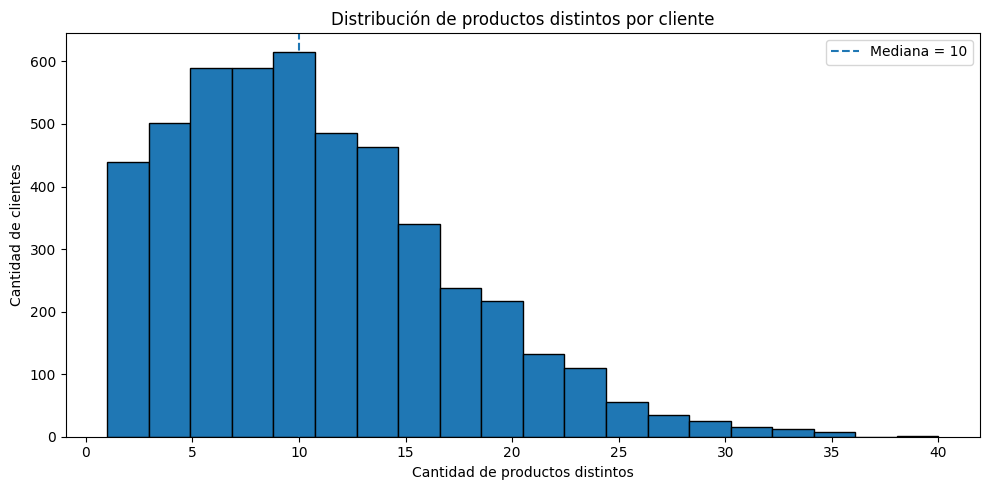

In [176]:
# Distribución de productos distintos por cliente
plt.figure(figsize=(10, 5))

plt.hist(
    resumen_clientes["n_productos_distintos"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    resumen_clientes["n_productos_distintos"].median(),
    linestyle="--",
    label=(
        "Mediana = "
        f"{resumen_clientes['n_productos_distintos'].median():.0f}"
    )
)

plt.title("Distribución de productos distintos por cliente")
plt.xlabel("Cantidad de productos distintos")
plt.ylabel("Cantidad de clientes")
plt.legend()
plt.tight_layout()
plt.show()

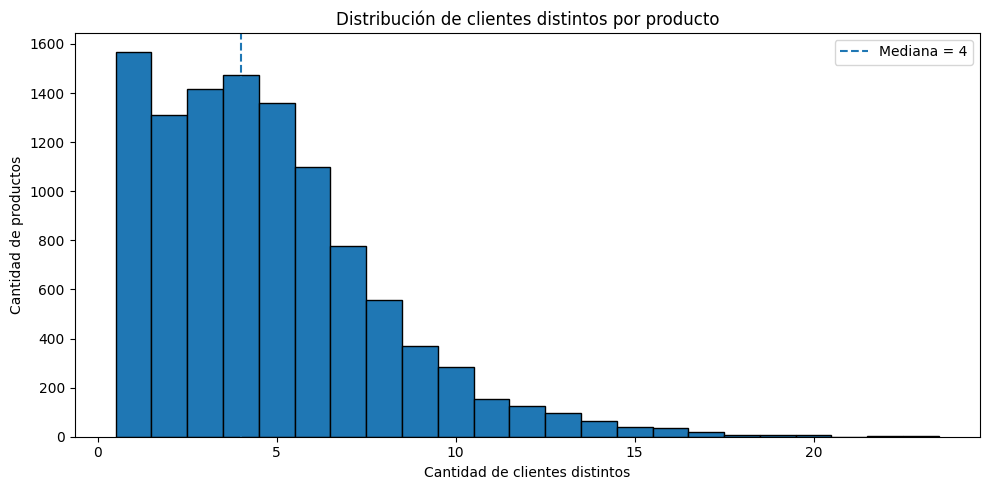

In [177]:
# Distribución de clientes distintos por producto
plt.figure(figsize=(10, 5))

plt.hist(
    resumen_productos["n_clientes_distintos"],
    bins=range(
        1,
        int(resumen_productos["n_clientes_distintos"].max()) + 2
    ),
    edgecolor="black",
    align="left"
)

plt.axvline(
    resumen_productos["n_clientes_distintos"].median(),
    linestyle="--",
    label=(
        "Mediana = "
        f"{resumen_productos['n_clientes_distintos'].median():.0f}"
    )
)

plt.title("Distribución de clientes distintos por producto")
plt.xlabel("Cantidad de clientes distintos")
plt.ylabel("Cantidad de productos")
plt.legend()
plt.tight_layout()
plt.show()

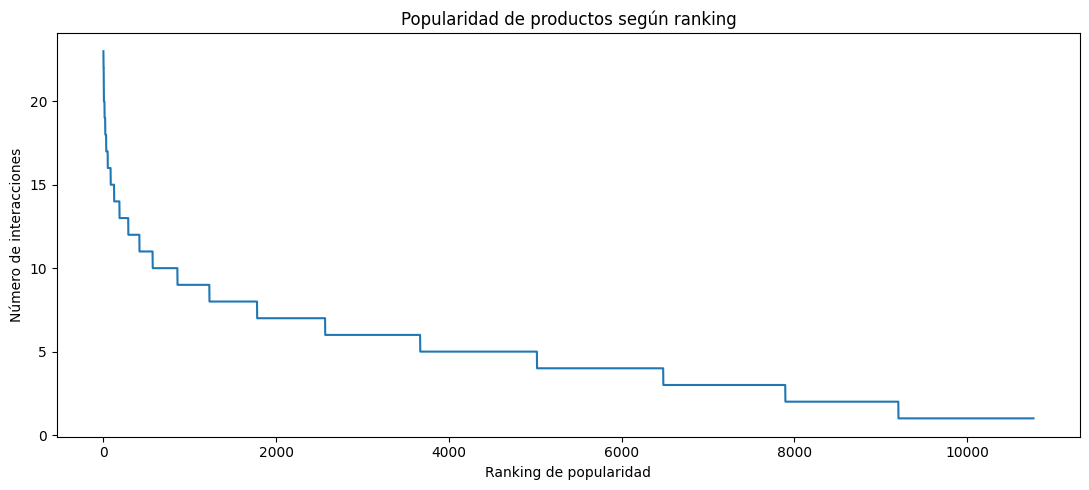

In [178]:
# Curva de popularidad de productos por ranking
plt.figure(figsize=(11, 5))

plt.plot(
    popularidad_productos["ranking"],
    popularidad_productos["n_eventos_interaccion"]
)

plt.title("Popularidad de productos según ranking")
plt.xlabel("Ranking de popularidad")
plt.ylabel("Número de interacciones")
plt.tight_layout()
plt.show()

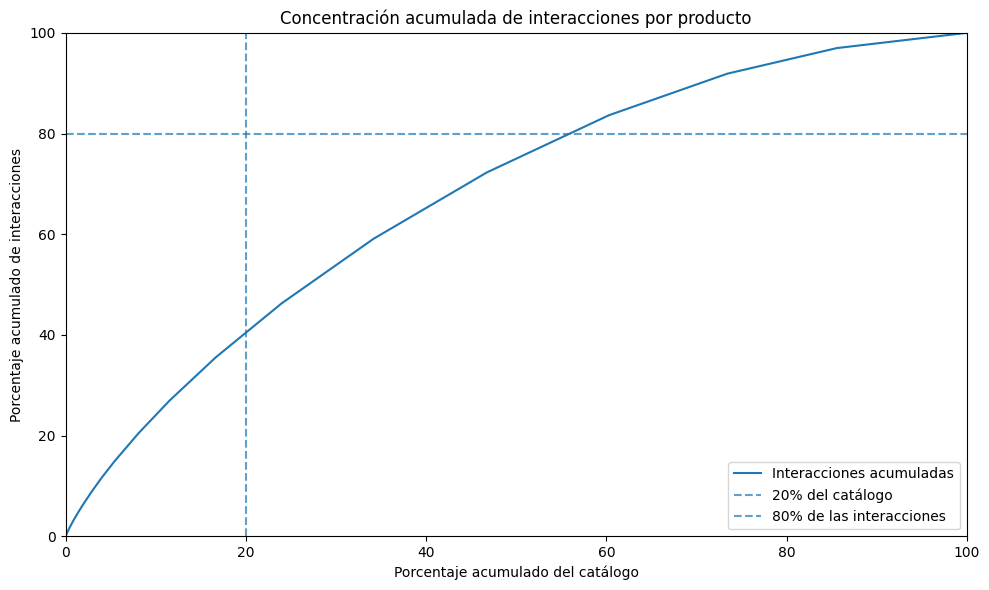

In [179]:
# Curva acumulada de interacciones según porcentaje del catálogo
plt.figure(figsize=(10, 6))

plt.plot(
    popularidad_productos["pct_catalogo"],
    popularidad_productos["pct_interacciones_acumuladas"],
    label="Interacciones acumuladas"
)

# Referencias para interpretar concentración
plt.axvline(
    20,
    linestyle="--",
    alpha=0.7,
    label="20% del catálogo"
)

plt.axhline(
    80,
    linestyle="--",
    alpha=0.7,
    label="80% de las interacciones"
)

plt.title("Concentración acumulada de interacciones por producto")
plt.xlabel("Porcentaje acumulado del catálogo")
plt.ylabel("Porcentaje acumulado de interacciones")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

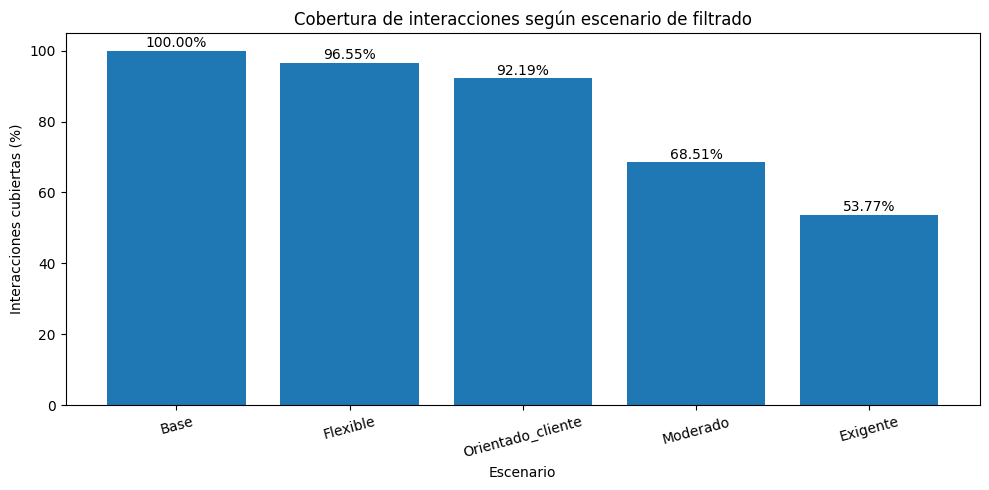

In [180]:
# Cobertura de interacciones según escenario de filtrado
plt.figure(figsize=(10, 5))

plt.bar(
    cobertura_escenarios["escenario"],
    cobertura_escenarios["pct_interacciones_cubiertas"]
)

plt.title("Cobertura de interacciones según escenario de filtrado")
plt.xlabel("Escenario")
plt.ylabel("Interacciones cubiertas (%)")
plt.ylim(0, 105)

for i, valor in enumerate(
    cobertura_escenarios["pct_interacciones_cubiertas"]
):
    plt.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Conclusión — Visualizaciones específicas del recomendador

Las visualizaciones confirman gráficamente los principales patrones identificados durante el análisis cuantitativo.

La distribución de productos distintos por cliente muestra historiales relativamente amplios, con una mediana de 10 productos. En contraste, la distribución de clientes distintos por producto se concentra en valores considerablemente menores, con una mediana de 4 clientes, evidenciando una menor profundidad de señal histórica del lado del catálogo.

La curva de popularidad muestra una disminución progresiva desde los productos más frecuentes hacia una amplia cantidad de ítems de baja interacción, consistente con la existencia de una estructura de long tail.

Sin embargo, la curva acumulada evidencia que las interacciones no se encuentran extremadamente concentradas en los productos más populares. El 20% superior del catálogo  representa aproximadamente el 40,45% de las interacciones, lejos de un patrón Pareto 80/20. Para alcanzar el 80% de la actividad observada es necesario considerar aproximadamente el 55,94% del catálogo.

Finalmente, la comparación de escenarios de filtrado muestra que los criterios flexibles conservan una elevada proporción de la señal disponible, mientras que los requisitos más restrictivos reducen significativamente la cobertura. El escenario con al menos cinco productos por cliente y dos clientes por producto conserva el 92,19% de los pares observados, mientras que exigir cinco clientes por producto reduce la cobertura al 68,51%.

En conjunto, las visualizaciones refuerzan la necesidad de equilibrar calidad de la señal histórica y cobertura del catálogo durante las etapas posteriores de modelado.

## 8. Hallazgos, limitaciones e implicancias para el modelado

Esta sección consolida los principales resultados del EDA específico del sistema de recomendación y documenta sus implicancias para las etapas posteriores de preparación,
modelado y evaluación.

Las decisiones que se presentan a continuación son criterios preliminares derivados del análisis exploratorio y deberán validarse empíricamente durante la experimentación
de modelos.

In [181]:
# Resumen cuantitativo del EDA específico del recomendador
resumen_eda_recomendador = pd.DataFrame(
    {
        "Métrica": [
            "Clientes únicos",
            "Productos únicos",
            "Eventos cliente-producto-transacción",
            "Pares cliente-producto únicos",
            "Densidad de la matriz (%)",
            "Sparsity de la matriz (%)",
            "Productos distintos promedio por cliente",
            "Clientes distintos promedio por producto",
            "Clientes con 1 producto conocido (%)",
            "Productos con 1 cliente conocido (%)",
            "Productos con <= 5 interacciones (%)",
            "Interacciones concentradas en top 20% productos (%)",
            "Catálogo necesario para cubrir 80% de interacciones (%)",
            "Cobertura escenario Flexible (%)",
            "Cobertura escenario Orientado_cliente (%)"
        ],
        "Valor": [
            total_clientes,
            total_productos,
            total_eventos,
            total_pares,
            round(densidad * 100, 6),
            round(sparsity * 100, 6),
            round(
                resumen_clientes["n_productos_distintos"].mean(),
                2
            ),
            round(
                resumen_productos["n_clientes_distintos"].mean(),
                2
            ),
            round(
                (
                    resumen_clientes["n_productos_distintos"].eq(1).mean()
                    * 100
                ),
                2
            ),
            round(
                (
                    resumen_productos["n_clientes_distintos"].eq(1).mean()
                    * 100
                ),
                2
            ),
            round(
                (
                    resumen_productos["n_eventos_interaccion"].le(5).mean()
                    * 100
                ),
                2
            ),
            float(
                concentracion_popularidad.loc[
                    concentracion_popularidad["top_catalogo_pct"] == 20,
                    "pct_interacciones"
                ].iloc[0]
            ),
            float(
                cobertura_interacciones.loc[
                    cobertura_interacciones[
                        "pct_interacciones_objetivo"
                    ] == 80,
                    "pct_catalogo_necesario"
                ].iloc[0]
            ),
            float(
                cobertura_escenarios.loc[
                    cobertura_escenarios["escenario"] == "Flexible",
                    "pct_interacciones_cubiertas"
                ].iloc[0]
            ),
            float(
                cobertura_escenarios.loc[
                    cobertura_escenarios["escenario"]
                    == "Orientado_cliente",
                    "pct_interacciones_cubiertas"
                ].iloc[0]
            )
        ]
    }
)

display(resumen_eda_recomendador)

,Métrica,Valor
0,Clientes únicos,4872.000000
1,Productos únicos,10768.000000
2,Eventos cliente-producto-transacción,51257.000000
3,Pares cliente-producto únicos,51093.000000
4,Densidad de la matriz (%),0.097391
5,Sparsity de la matriz (%),99.902609
6,Productos distintos promedio por cliente,10.490000
7,Clientes distintos promedio por producto,4.740000
8,Clientes con 1 producto conocido (%),4.080000
9,Productos con 1 cliente conocido (%),14.550000


### Hallazgos principales

1. **Existe suficiente historial para personalizar a una proporción importante de los clientes.** Los 4.872 clientes presentan en promedio 10,49 productos distintos y una mediana de 10. Solamente el 4,08% dispone de un único producto conocido, mientras que el 80,69% posee al menos cinco productos distintos.

2. **La señal histórica es considerablemente más débil del lado de los productos.** Los 10.768 productos fueron adquiridos en promedio por 4,74 clientes distintos y presentan una mediana de 4. El 14,55% fue comprado por un único cliente y solamente el 46,44% alcanza al menos cinco clientes distintos.

3. **La recompra exacta del mismo producto es poco frecuente.** De los 51.093 pares cliente-producto observados, 50.929 (99,68 %) aparecen en una única transacción y solamente 164 (0,32%) presentan una segunda interacción.

4. **La matriz cliente-producto es extremadamente sparse.** Sobre 52.461.696 combinaciones posibles solamente se observaron 51.093 pares, resultando en una densidad del 0,097391% y una sparsity del 99,902609%.

5. **Existe una estructura de long tail.** El 65,95% del catálogo presenta como máximo cinco interacciones. Sin embargo, estos productos todavía representan el 41,03% de
toda la actividad observada, por lo que la cola de baja frecuencia no puede considerarse irrelevante.

6. **La concentración en productos populares es moderada y no presenta un patrón Pareto 80/20.** El 20% superior del catálogo representa solamente el 40,45% de las interacciones. Para cubrir el 80% de la actividad es necesario considerar aproximadamente el 55,94% de los productos.

7. **El problema de historial insuficiente es más importante en productos que en clientes.** Los escenarios de cobertura muestran que filtros estrictos sobre productos
reducen rápidamente el catálogo disponible y la cantidad de relaciones observadas.

8. **Los filtros asimétricos presentan un mejor compromiso preliminar entre calidad de señal y cobertura.** Exigir al menos cinco productos conocidos por cliente y dos
clientes por producto conserva el 80,69% de los clientes, el 85,45% del catálogo y el 92,19% de los pares cliente-producto observados.

### Limitaciones del análisis y de los datos

- **No existe un identificador único de cliente.** Se utiliza `customer_proxy`, construido mediante `customer_name + market`. Esta aproximación permite trabajar con la información disponible, pero no garantiza una identificación perfecta de personas reales.

- **La identificación de productos también requiere una clave compuesta.** Se utiliza `item_id_name`, construido mediante `product_id + product_name`, debido a inconsistencias
detectadas previamente en la relación entre ambos campos.

- **La transacción se identifica mediante una clave compuesta.** Se utiliza `transaction_key`, dado que `order_id` no presentó unicidad global durante la auditoría inicial.

- **Las interacciones representan compras y no preferencias explícitas.** El dataset no contiene ratings, clics, búsquedas ni valoraciones. Por lo tanto, una compra puede
interpretarse como una señal positiva implícita, pero la ausencia de compra no representa necesariamente una preferencia negativa.

- **Las celdas vacías de la matriz representan interacciones no observadas.** Debido a la elevada sparsity, no debe asumirse que un cliente rechaza todos los productos con
los que no interactuó.

- **El dataset histórico no permite cuantificar cold start absoluto.** Los clientes o productos con cero interacciones no aparecen en la información disponible. Los casos
analizados corresponden, por lo tanto, a situaciones de historial mínimo o near-cold-start.

- **Una parte importante del catálogo tiene poca evidencia colaborativa.** Esto limita la robustez con la que pueden aprenderse similitudes para productos de baja frecuencia.

- **Los escenarios de filtrado evaluados son preliminares.** Los cálculos realizados no corresponden todavía a un filtrado iterativo tipo k-core, por lo que los umbrales finales
deberán validarse durante la preparación y experimentación del modelo.

### Implicancias y decisiones preliminares para el modelado

A partir de los resultados del EDA se establecen las siguientes consideraciones para las próximas etapas del sistema de recomendación:

1. **Tratar el problema principalmente como recomendación con feedback implícito.** Las compras constituyen señales positivas observadas, mientras que las combinaciones
cliente-producto sin interacción deberán tratarse como desconocidas y no como rechazos explícitos.

2. **Utilizar estructuras de datos sparse.** La sparsity del 99,902609% hace innecesaria y poco eficiente la construcción de una matriz densa completa
cliente-producto.

3. **Evaluar modelos colaborativos, pero no depender exclusivamente de ellos.** Existe suficiente historial para una parte importante de los clientes, aunque la baja
cantidad de usuarios por producto y la elevada sparsity pueden limitar las similitudes colaborativas para productos de baja frecuencia.

4. **Considerar estrategias basadas en producto y enfoques híbridos.** La elevada proporción de productos con poco historial sugiere que información adicional del
producto podría ser útil para complementar la señal colaborativa y mejorar la recomendación de ítems de la long tail.

5. **Incluir un baseline de popularidad.** Permitirá disponer de una referencia mínima contra la cual comparar los modelos personalizados y podrá servir posteriormente como
estrategia de fallback para usuarios sin historial.

6. **Evitar filtros excesivamente restrictivos sobre productos.** Como punto de partida para la experimentación, resulta razonable evaluar umbrales diferenciados. El escenario
de al menos cinco productos por cliente y dos clientes por producto conserva el 92,19% de las relaciones observadas, mientras que exigir cinco clientes por producto reduce esa cobertura al 68,51%.

7. **Evaluar explícitamente el sesgo de popularidad y la cobertura de catálogo.** Dado que una parte sustancial de las interacciones pertenece a productos de baja frecuencia, la calidad del recomendador no debería medirse únicamente por capacidad predictiva. Será importante observar también qué proporción del catálogo puede recomendar.

8. **Considerar la exclusión de productos ya adquiridos al generar candidatos.** La recompra exacta representa solamente el 0,32% de los pares cliente-producto, por lo que el objetivo principal puede orientarse al descubrimiento de productos distintos potencialmente relevantes para cada cliente.

9. **Diseñar estrategias específicas para cold start.** Los clientes o productos completamente nuevos requerirán mecanismos alternativos, como popularidad, atributos
de producto o enfoques híbridos, debido a que carecerán de señal colaborativa.

10. **Validar todas estas decisiones mediante experimentación.** Los umbrales y estrategias definidos durante el EDA son hipótesis de trabajo y no decisiones finales. La selección deberá basarse posteriormente en el desempeño de los modelos y en el equilibrio entre personalización, cobertura y robustez.

# 04 - Calidad y Tratamiento de los datos

## 1. Auditoría base de calidad

En esta sección se realiza una evaluación sistemática de la calidad del dataset original antes de aplicar transformaciones definitivas.

Se conservará `df` como referencia del dataset original y se documentará el estado inicial de los datos para mantener trazabilidad entre la fuente original y el dataset preparado.

En este primer bloque se revisan:

- dimensiones del dataset;
- tipos de datos;
- valores nulos por columna;
- registros completamente duplicados.

No se aplican transformaciones en esta etapa.

In [182]:
print("AUDITORÍA BASE DE CALIDAD\n")

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Total de celdas: {df.size:,}")

AUDITORÍA BASE DE CALIDAD

Filas: 51,290
Columnas: 21
Total de celdas: 1,077,090


In [183]:
auditoria_columnas = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "valores_no_nulos": df.notna().sum(),
    "valores_nulos": df.isna().sum(),
    "porcentaje_nulos": (
        df.isna().mean() * 100
    ).round(2),
    "valores_unicos": df.nunique(dropna=True)
})

display(auditoria_columnas)

,tipo_dato,valores_no_nulos,valores_nulos,porcentaje_nulos,valores_unicos
order_id,object,51290,0,0.0,25035
order_date,object,51290,0,0.0,1430
ship_date,object,51290,0,0.0,1464
ship_mode,object,51290,0,0.0,4
customer_name,object,51290,0,0.0,795
segment,object,51290,0,0.0,3
state,object,51290,0,0.0,1094
country,object,51290,0,0.0,147
market,object,51290,0,0.0,7
region,object,51290,0,0.0,13


In [184]:
# Verificación de nulos
nulos_por_columna = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("valores_nulos")
)

nulos_por_columna["porcentaje_nulos"] = (
    nulos_por_columna["valores_nulos"]
    / len(df)
    * 100
).round(2)

print(
    "Total de valores nulos en el dataset:",
    f"{df.isna().sum().sum():,}"
)

display(nulos_por_columna)

Total de valores nulos en el dataset: 0


,valores_nulos,porcentaje_nulos
order_id,0,0.0
order_date,0,0.0
ship_date,0,0.0
ship_mode,0,0.0
customer_name,0,0.0
segment,0,0.0
state,0,0.0
country,0,0.0
market,0,0.0
region,0,0.0


In [185]:
# Duplicados
duplicados_exactos = df.duplicated().sum()

porcentaje_duplicados = (
    duplicados_exactos / len(df) * 100
)

print(f"Duplicados exactos: {duplicados_exactos:,}")
print(
    f"Porcentaje del dataset: "
    f"{porcentaje_duplicados:.4f}%"
)

Duplicados exactos: 0
Porcentaje del dataset: 0.0000%


In [186]:
# Resumen estado inicial
estado_inicial_calidad = pd.Series({
    "filas": len(df),
    "columnas": df.shape[1],
    "valores_nulos_totales": int(
        df.isna().sum().sum()
    ),
    "columnas_con_nulos": int(
        (df.isna().sum() > 0).sum()
    ),
    "duplicados_exactos": int(
        df.duplicated().sum()
    )
})

display(
    estado_inicial_calidad.to_frame(
        "resultado"
    )
)

,resultado
filas,51290
columnas,21
valores_nulos_totales,0
columnas_con_nulos,0
duplicados_exactos,0


## 2. Validación de variables numéricas y temporales

Se valida la conversión de `sales` desde texto a formato numérico y la correcta interpretación de las variables temporales.

Las conversiones se realizan inicialmente sobre variables auxiliares, sin modificar el dataset original, para detectar posibles pérdidas o inconsistencias antes de aplicar cualquier tratamiento definitivo.

In [187]:
sales_numeric = pd.to_numeric(
    df["sales"].str.replace(",", "", regex=False),
    errors="coerce"
)

sales_original_nulos = df["sales"].isna().sum()
sales_convertidos_nulos = sales_numeric.isna().sum()

nuevos_nulos_sales = (
    sales_convertidos_nulos
    - sales_original_nulos
)

print(f"Tipo original de sales: {df['sales'].dtype}")
print(f"Tipo luego de conversión: {sales_numeric.dtype}")
print(f"Nulos originales: {sales_original_nulos:,}")
print(f"Nulos después de conversión: {sales_convertidos_nulos:,}")
print(
    f"Nuevos nulos generados por la conversión: "
    f"{nuevos_nulos_sales:,}"
)

Tipo original de sales: object
Tipo luego de conversión: int64
Nulos originales: 0
Nulos después de conversión: 0
Nuevos nulos generados por la conversión: 0


In [188]:
# Sales convertido a numérico
print("Resumen de sales convertido a formato numérico:\n")

print(f"Mínimo: {sales_numeric.min():,.2f}")
print(f"Máximo: {sales_numeric.max():,.2f}")
print(f"Media: {sales_numeric.mean():,.2f}")
print(f"Mediana: {sales_numeric.median():,.2f}")

Resumen de sales convertido a formato numérico:

Mínimo: 0.00
Máximo: 22,638.00
Media: 246.50
Mediana: 85.00


In [189]:
# Conversión fechas
order_date_dt = pd.to_datetime(
    df["order_date"],
    dayfirst=True,
    errors="coerce"
)

ship_date_dt = pd.to_datetime(
    df["ship_date"],
    dayfirst=True,
    errors="coerce"
)

print("CONVERSIÓN DE FECHAS\n")

print(
    f"order_date - valores no convertibles: "
    f"{order_date_dt.isna().sum():,}"
)

print(
    f"ship_date - valores no convertibles: "
    f"{ship_date_dt.isna().sum():,}"
)

print(
    f"\nRango order_date: "
    f"{order_date_dt.min().date()} → "
    f"{order_date_dt.max().date()}"
)

print(
    f"Rango ship_date: "
    f"{ship_date_dt.min().date()} → "
    f"{ship_date_dt.max().date()}"
)

CONVERSIÓN DE FECHAS

order_date - valores no convertibles: 0
ship_date - valores no convertibles: 0

Rango order_date: 2011-01-01 → 2014-12-31
Rango ship_date: 2011-01-03 → 2015-01-07


In [190]:
year_desde_order_date = order_date_dt.dt.year

inconsistencias_year = (
    year_desde_order_date != df["year"]
)

cantidad_inconsistencias_year = (
    inconsistencias_year.sum()
)

print(
    "Registros donde year no coincide "
    "con el año de order_date:",
    f"{cantidad_inconsistencias_year:,}"
)

Registros donde year no coincide con el año de order_date: 0


In [191]:
envios_anteriores = (
    ship_date_dt < order_date_dt
)

cantidad_envios_anteriores = (
    envios_anteriores.sum()
)

print(
    "Envíos con ship_date anterior a order_date:",
    f"{cantidad_envios_anteriores:,}"
)

Envíos con ship_date anterior a order_date: 0


In [192]:
dias_hasta_envio = (
    ship_date_dt - order_date_dt
).dt.days

print("DÍAS ENTRE PEDIDO Y ENVÍO\n")

print(f"Mínimo: {dias_hasta_envio.min()} días")
print(f"Máximo: {dias_hasta_envio.max()} días")
print(f"Mediana: {dias_hasta_envio.median():.0f} días")

print(
    "Registros con duración negativa:",
    f"{(dias_hasta_envio < 0).sum():,}"
)

DÍAS ENTRE PEDIDO Y ENVÍO

Mínimo: 0 días
Máximo: 7 días
Mediana: 4 días
Registros con duración negativa: 0


## 3. Calidad de variables categóricas

Se analizan las variables categóricas para detectar valores vacíos, cadenas compuestas únicamente por espacios y espacios innecesarios al inicio o al final de los textos.

Estas inconsistencias pueden generar categorías artificialmente diferentes y afectar agrupaciones, identificadores y etapas posteriores del sistema de recomendación.

La revisión se realiza sin modificar el dataset original.

In [193]:
columnas_categoricas = [
    col
    for col in df.select_dtypes(
        include=["object", "string"]
    ).columns
    if col not in [
        "sales",
        "order_date",
        "ship_date"
    ]
]

print(
    f"Cantidad de variables categóricas analizadas: "
    f"{len(columnas_categoricas)}"
)

print("\nVariables categóricas:")
for col in columnas_categoricas:
    print(f"- {col}")

Cantidad de variables categóricas analizadas: 13

Variables categóricas:
- order_id
- ship_mode
- customer_name
- segment
- state
- country
- market
- region
- product_id
- category
- sub_category
- product_name
- order_priority


In [194]:
auditoria_categoricas = []

for col in columnas_categoricas:
    serie = df[col].astype("string")

    vacios = serie.eq("").sum()

    solo_espacios = (
        serie.str.fullmatch(
            r"\s+",
            na=False
        )
    ).sum()

    espacios_extremos = (
        serie.ne(serie.str.strip())
        &
        ~serie.str.fullmatch(
            r"\s*",
            na=False
        )
    ).sum()

    auditoria_categoricas.append({
        "columna": col,
        "valores_vacios": vacios,
        "solo_espacios": solo_espacios,
        "espacios_inicio_fin": espacios_extremos
    })

auditoria_categoricas = pd.DataFrame(
    auditoria_categoricas
)

display(auditoria_categoricas)

,columna,valores_vacios,solo_espacios,espacios_inicio_fin
0,order_id,0,0,0
1,ship_mode,0,0,0
2,customer_name,0,0,0
3,segment,0,0,0
4,state,0,0,0
5,country,0,0,0
6,market,0,0,0
7,region,0,0,0
8,product_id,0,0,0
9,category,0,0,0


In [195]:
print("RESUMEN DE CALIDAD CATEGÓRICA\n")

print(
    "Valores vacíos:",
    f"{auditoria_categoricas['valores_vacios'].sum():,}"
)

print(
    "Valores compuestos solo por espacios:",
    f"{auditoria_categoricas['solo_espacios'].sum():,}"
)

print(
    "Valores con espacios al inicio o final:",
    f"{auditoria_categoricas['espacios_inicio_fin'].sum():,}"
)

RESUMEN DE CALIDAD CATEGÓRICA

Valores vacíos: 0
Valores compuestos solo por espacios: 0
Valores con espacios al inicio o final: 0


In [196]:
comparacion_unicos = []

for col in columnas_categoricas:
    serie = df[col].astype("string")

    unicos_originales = serie.nunique(
        dropna=True
    )

    unicos_sin_espacios = (
        serie.str.strip()
        .nunique(dropna=True)
    )

    comparacion_unicos.append({
        "columna": col,
        "unicos_originales":
            unicos_originales,
        "unicos_tras_strip":
            unicos_sin_espacios,
        "diferencia":
            unicos_originales
            - unicos_sin_espacios
    })

comparacion_unicos = pd.DataFrame(
    comparacion_unicos
)

display(comparacion_unicos)

,columna,unicos_originales,unicos_tras_strip,diferencia
0,order_id,25035,25035,0
1,ship_mode,4,4,0
2,customer_name,795,795,0
3,segment,3,3,0
4,state,1094,1094,0
5,country,147,147,0
6,market,7,7,0
7,region,13,13,0
8,product_id,10292,10292,0
9,category,3,3,0


## 4. Rangos, valores no positivos y outliers numéricos

Se evalúan las principales variables numéricas del dataset para identificar valores fuera de rangos esperados, registros con ventas nulas o no positivas y posibles valores atípicos.

Los outliers se detectan mediante el criterio del rango intercuartílico (IQR), pero no se eliminan automáticamente. Su presencia será analizada antes de decidir si corresponden a errores de calidad o a transacciones comerciales legítimas.

In [197]:
numericas_calidad = pd.DataFrame({
    "quantity": df["quantity"],
    "discount": df["discount"],
    "sales": sales_numeric,
    "profit": df["profit"],
    "shipping_cost": df["shipping_cost"]
})

print("Variables numéricas analizadas:")
print(list(numericas_calidad.columns))

Variables numéricas analizadas:
['quantity', 'discount', 'sales', 'profit', 'shipping_cost']


In [198]:
estadisticos_numericos = pd.DataFrame({
    "minimo": numericas_calidad.min(),
    "q1": numericas_calidad.quantile(0.25),
    "mediana": numericas_calidad.median(),
    "media": numericas_calidad.mean(),
    "q3": numericas_calidad.quantile(0.75),
    "maximo": numericas_calidad.max(),
    "desviacion_std": numericas_calidad.std()
})

estadisticos_numericos["iqr"] = (
    estadisticos_numericos["q3"]
    - estadisticos_numericos["q1"]
)

display(
    estadisticos_numericos.round(2)
)

,minimo,q1,mediana,media,q3,maximo,desviacion_std,iqr
quantity,1.00,2.00,3.00,3.48,5.00,14.00,2.28,3.00
discount,0.00,0.00,0.00,0.14,0.20,0.85,0.21,0.20
sales,0.00,31.00,85.00,246.50,251.00,22638.00,487.57,220.00
profit,-6599.98,0.00,9.24,28.64,36.81,8399.98,174.42,36.81
shipping_cost,0.00,2.61,7.79,26.38,24.45,933.57,57.30,21.84


In [199]:
validacion_rangos = pd.Series({
    "quantity <= 0":
        (df["quantity"] <= 0).sum(),

    "discount < 0":
        (df["discount"] < 0).sum(),

    "discount > 1":
        (df["discount"] > 1).sum(),

    "sales < 0":
        (sales_numeric < 0).sum(),

    "sales == 0":
        (sales_numeric == 0).sum(),

    "profit < 0":
        (df["profit"] < 0).sum(),

    "profit == 0":
        (df["profit"] == 0).sum(),

    "shipping_cost < 0":
        (df["shipping_cost"] < 0).sum(),

    "shipping_cost == 0":
        (df["shipping_cost"] == 0).sum()
})

display(
    validacion_rangos.to_frame(
        "registros"
    )
)

,registros
quantity <= 0,0
discount < 0,0
discount > 1,0
sales < 0,0
sales == 0,1
profit < 0,12543
profit == 0,668
shipping_cost < 0,0
shipping_cost == 0,2


In [200]:
mask_sales_no_positivas = (
    sales_numeric <= 0
)

cantidad_sales_no_positivas = (
    mask_sales_no_positivas.sum()
)

print(
    "Registros con sales <= 0:",
    f"{cantidad_sales_no_positivas:,}"
)

if cantidad_sales_no_positivas > 0:
    display(
        df.loc[
            mask_sales_no_positivas,
            [
                "order_id",
                "order_date",
                "product_id",
                "product_name",
                "quantity",
                "sales",
                "discount",
                "profit",
                "shipping_cost"
            ]
        ]
    )

Registros con sales <= 0: 1


,order_id,order_date,product_id,product_name,quantity,sales,discount,profit,shipping_cost
40017,US-2014-102288,20/06/2014,OFF-AP-10002906,Hoover Replacement Belt for Commercial Guardsm...,1,0,0.8,-1.11,0.01


In [201]:
resumen_outliers = []

for col in numericas_calidad.columns:
    q1 = numericas_calidad[col].quantile(0.25)
    q3 = numericas_calidad[col].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mask_outlier = (
        (numericas_calidad[col] < limite_inferior)
        |
        (numericas_calidad[col] > limite_superior)
    )

    cantidad = mask_outlier.sum()

    resumen_outliers.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "outliers": cantidad,
        "porcentaje_outliers":
            cantidad / len(df) * 100
    })

resumen_outliers = pd.DataFrame(
    resumen_outliers
)

display(
    resumen_outliers.round(2)
)

,variable,q1,q3,iqr,limite_inferior,limite_superior,outliers,porcentaje_outliers
0,quantity,2.00,5.00,3.00,-2.50,9.50,877,1.71
1,discount,0.00,0.20,0.20,-0.30,0.50,4172,8.13
2,sales,31.00,251.00,220.00,-299.00,581.00,5655,11.03
3,profit,0.00,36.81,36.81,-55.22,92.02,9755,19.02
4,shipping_cost,2.61,24.45,21.84,-30.15,57.21,5909,11.52


In [202]:
for col in [
    "sales",
    "profit",
    "shipping_cost"
]:
    print(
        f"\nTOP 5 valores de {col}:"
    )

    display(
        numericas_calidad[
            [col]
        ]
        .sort_values(
            by=col,
            ascending=False
        )
        .head(5)
    )


TOP 5 valores de sales:


,sales
1103,22638
29530,17500
36239,14000
46525,11200
48097,10500



TOP 5 valores de profit:


,profit
29530,8399.9760
36239,6719.9808
48097,5039.9856
33011,4946.3700
5522,4630.4755



TOP 5 valores de shipping_cost:


,shipping_cost
13891,933.57
20727,923.63
30040,915.49
20543,910.16
30718,903.04


In [203]:
analisis_descuento_profit = (
    df
    .groupby("discount")
    .agg(
        cantidad_registros=(
            "profit",
            "size"
        ),
        profit_promedio=(
            "profit",
            "mean"
        ),
        profit_mediano=(
            "profit",
            "median"
        ),
        porcentaje_perdidas=(
            "profit",
            lambda x:
                (x < 0).mean() * 100
        )
    )
    .reset_index()
)

display(
    analisis_descuento_profit.round(2)
)

,discount,cantidad_registros,profit_promedio,profit_mediano,porcentaje_perdidas
0,0.00,29009,61.04,17.82,0.00
1,0.00,461,125.76,81.84,2.82
2,0.07,150,140.99,88.71,20.00
3,0.10,4068,64.07,17.28,21.07
4,0.15,541,50.60,15.80,36.97
5,0.17,735,38.32,6.91,32.11
6,0.20,4998,23.55,6.24,20.55
7,0.20,41,-14.52,-10.59,60.98
8,0.25,198,4.04,0.82,49.49
9,0.27,388,-4.32,-0.03,50.77


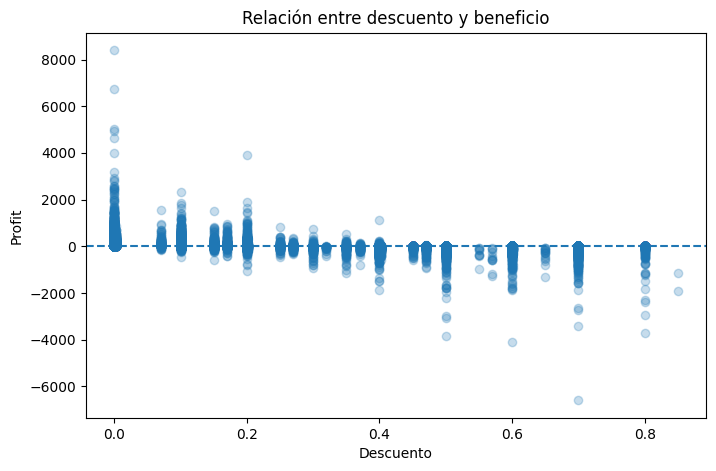

In [204]:
# Gráfico `discount` vs `profit`
plt.figure(figsize=(8, 5))

plt.scatter(
    df["discount"],
    df["profit"],
    alpha=0.25
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Relación entre descuento y beneficio"
)

plt.xlabel(
    "Descuento"
)

plt.ylabel(
    "Profit"
)

plt.show()

In [205]:
# Chequeo de los 2 shipping_cost=0
mask_shipping_cero = (
    df["shipping_cost"] == 0
)

print(
    "Registros con shipping_cost = 0:",
    f"{mask_shipping_cero.sum():,}"
)

display(
    df.loc[
        mask_shipping_cero,
        [
            "order_id",
            "order_date",
            "ship_mode",
            "market",
            "country",
            "product_id",
            "product_name",
            "quantity",
            "sales",
            "discount",
            "profit",
            "shipping_cost"
        ]
    ]
)

Registros con shipping_cost = 0: 2


,order_id,order_date,ship_mode,market,country,product_id,product_name,quantity,sales,discount,profit,shipping_cost
9827,MX-2012-140767,18/02/2012,Standard Class,LATAM,Brazil,OFF-BI-10000806,"Acco Index Tab, Economy",2,13,0.0,2.4,0.0
11846,MX-2012-134460,22/05/2012,Second Class,LATAM,Nicaragua,OFF-PA-10004155,"Eaton Computer Printout Paper, 8.5 x 11",3,61,0.0,1.8,0.0


In [206]:
discount_analisis = (
    df["discount"]
    .round(2)
)

analisis_descuento_profit = (
    df.assign(
        discount_analisis=discount_analisis
    )
    .groupby("discount_analisis")
    .agg(
        cantidad_registros=(
            "profit",
            "size"
        ),
        profit_promedio=(
            "profit",
            "mean"
        ),
        profit_mediano=(
            "profit",
            "median"
        ),
        porcentaje_perdidas=(
            "profit",
            lambda x:
                (x < 0).mean() * 100
        )
    )
    .reset_index()
)

display(
    analisis_descuento_profit.round(2)
)

,discount_analisis,cantidad_registros,profit_promedio,profit_mediano,porcentaje_perdidas
0,0.00,29470,62.05,18.22,0.04
1,0.07,150,140.99,88.71,20.00
2,0.10,4068,64.07,17.28,21.07
3,0.15,541,50.60,15.80,36.97
4,0.17,735,38.32,6.91,32.11
5,0.20,5039,23.24,6.20,20.88
6,0.25,198,4.04,0.82,49.49
7,0.27,388,-4.32,-0.03,50.77
8,0.30,340,-57.90,-24.32,82.65
9,0.32,27,-88.56,-46.98,100.00


## 5. Consistencia de identificadores de productos, pedidos y clientes

Se analiza la consistencia de los identificadores utilizados en el dataset para productos, pedidos y clientes.

El objetivo es detectar relaciones ambiguas entre identificadores y nombres que puedan afectar agrupaciones, métricas y la construcción posterior del sistema de recomendación.

En esta etapa únicamente se diagnostican y cuantifican las inconsistencias. No se modifican los identificadores originales.

In [207]:
product_id_a_nombres = (
    df.groupby("product_id")["product_name"]
    .nunique()
    .sort_values(ascending=False)
)

product_ids_multiples_nombres = (
    product_id_a_nombres[
        product_id_a_nombres > 1
    ]
)

filas_afectadas_product_id = (
    df["product_id"]
    .isin(product_ids_multiples_nombres.index)
    .sum()
)

print("CONSISTENCIA product_id → product_name\n")

print(
    f"product_id únicos: "
    f"{df['product_id'].nunique():,}"
)

print(
    "product_id asociados a más de un product_name:",
    f"{len(product_ids_multiples_nombres):,}"
)

print(
    "Filas asociadas a esos product_id:",
    f"{filas_afectadas_product_id:,}"
)

CONSISTENCIA product_id → product_name

product_id únicos: 10,292
product_id asociados a más de un product_name: 457
Filas asociadas a esos product_id: 4,392


In [208]:
product_name_a_ids = (
    df.groupby("product_name")["product_id"]
    .nunique()
    .sort_values(ascending=False)
)

product_names_multiples_ids = (
    product_name_a_ids[
        product_name_a_ids > 1
    ]
)

filas_afectadas_product_name = (
    df["product_name"]
    .isin(product_names_multiples_ids.index)
    .sum()
)

print("CONSISTENCIA product_name → product_id\n")

print(
    f"product_name únicos: "
    f"{df['product_name'].nunique():,}"
)

print(
    "product_name asociados a más de un product_id:",
    f"{len(product_names_multiples_ids):,}"
)

print(
    "Filas asociadas a esos nombres:",
    f"{filas_afectadas_product_name:,}"
)

CONSISTENCIA product_name → product_id

product_name únicos: 3,788
product_name asociados a más de un product_id: 1,944
Filas asociadas a esos nombres: 41,603


In [209]:
ids_ejemplo = (
    product_ids_multiples_nombres
    .head(5)
    .index
)

ejemplos_productos = (
    df.loc[
        df["product_id"].isin(ids_ejemplo),
        [
            "product_id",
            "product_name",
            "category",
            "sub_category",
            "market",
            "region",
            "country"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["product_id", "product_name"]
    )
)

display(ejemplos_productos)

,product_id,product_name,category,sub_category,market,region,country
4155,FUR-FU-10004960,"Deflect-O Photo Frame, Duo Pack",Furniture,Furnishings,EU,South,Spain
14456,FUR-FU-10004960,"Deflect-O Photo Frame, Duo Pack",Furniture,Furnishings,EU,North,Finland
24523,FUR-FU-10004960,"Deflect-O Photo Frame, Durable",Furniture,Furnishings,LATAM,North,Mexico
26195,FUR-FU-10004960,"Deflect-O Photo Frame, Durable",Furniture,Furnishings,LATAM,South,Brazil
37040,FUR-FU-10004960,"Deflect-O Photo Frame, Durable",Furniture,Furnishings,LATAM,Central,El Salvador
50478,FUR-FU-10004960,"Deflect-O Photo Frame, Durable",Furniture,Furnishings,LATAM,South,Peru
33122,FUR-FU-10004960,"Seth Thomas 12"" Clock w/ Goldtone Case",Furniture,Furnishings,US,West,United States
42929,FUR-FU-10004960,"Seth Thomas 12"" Clock w/ Goldtone Case",Furniture,Furnishings,US,East,United States
91,OFF-BI-10003708,Acco Four Pocket Poly Ring Binder with Label H...,Office Supplies,Binders,US,Central,United States
17196,OFF-BI-10003708,Acco Four Pocket Poly Ring Binder with Label H...,Office Supplies,Binders,US,West,United States


In [210]:
auditoria_clientes = (
    df.groupby("customer_name")
    .agg(
        mercados=("market", "nunique"),
        regiones=("region", "nunique"),
        paises=("country", "nunique"),
        estados=("state", "nunique"),
        pedidos=("order_id", "nunique")
    )
)

clientes_multi_market = (
    auditoria_clientes["mercados"] > 1
).sum()

clientes_multi_country = (
    auditoria_clientes["paises"] > 1
).sum()

clientes_multi_region = (
    auditoria_clientes["regiones"] > 1
).sum()

print("AUDITORÍA DE customer_name\n")

print(
    f"customer_name únicos: "
    f"{df['customer_name'].nunique():,}"
)

print(
    "Nombres presentes en más de un market:",
    f"{clientes_multi_market:,}"
)

print(
    "Nombres presentes en más de una region:",
    f"{clientes_multi_region:,}"
)

print(
    "Nombres presentes en más de un country:",
    f"{clientes_multi_country:,}"
)

AUDITORÍA DE customer_name

customer_name únicos: 795
Nombres presentes en más de un market: 795
Nombres presentes en más de una region: 795
Nombres presentes en más de un country: 795


In [211]:
auditoria_order_id = (
    df.groupby("order_id")
    .agg(
        clientes=("customer_name", "nunique"),
        mercados=("market", "nunique"),
        regiones=("region", "nunique"),
        paises=("country", "nunique"),
        fechas_pedido=("order_date", "nunique")
    )
)

order_ids_multi_cliente = (
    auditoria_order_id[
        auditoria_order_id["clientes"] > 1
    ]
)

order_ids_multi_market = (
    auditoria_order_id[
        auditoria_order_id["mercados"] > 1
    ]
)

order_ids_multi_country = (
    auditoria_order_id[
        auditoria_order_id["paises"] > 1
    ]
)

order_ids_multi_fecha = (
    auditoria_order_id[
        auditoria_order_id["fechas_pedido"] > 1
    ]
)

print("AUDITORÍA DE order_id\n")

print(
    f"order_id únicos: "
    f"{df['order_id'].nunique():,}"
)

print(
    "order_id asociados a más de un cliente:",
    f"{len(order_ids_multi_cliente):,}"
)

print(
    "order_id presentes en más de un market:",
    f"{len(order_ids_multi_market):,}"
)

print(
    "order_id presentes en más de un country:",
    f"{len(order_ids_multi_country):,}"
)

print(
    "order_id asociados a más de una fecha:",
    f"{len(order_ids_multi_fecha):,}"
)

AUDITORÍA DE order_id

order_id únicos: 25,035
order_id asociados a más de un cliente: 659
order_id presentes en más de un market: 37
order_id presentes en más de un country: 58
order_id asociados a más de una fecha: 659


In [212]:
ids_pedido_ejemplo = (
    order_ids_multi_cliente
    .head(10)
    .index
)

ejemplos_order_id = (
    df.loc[
        df["order_id"].isin(
            ids_pedido_ejemplo
        ),
        [
            "order_id",
            "order_date",
            "customer_name",
            "market",
            "region",
            "country",
            "product_id",
            "product_name"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "order_id",
            "customer_name",
            "market"
        ]
    )
)

display(ejemplos_order_id)

,order_id,order_date,customer_name,market,region,country,product_id,product_name
17628,AG-2012-2220,9/11/2012,Mike Vittorini,Africa,Africa,Algeria,FUR-HAR-10003548,"Harbour Creations Bag Chairs, Set of Two"
19712,AG-2012-2220,26/12/2012,Patrick O'Donnell,Africa,Africa,Algeria,TEC-HEW-10002304,"Hewlett Fax Machine, High-Speed"
19743,AG-2012-2220,26/12/2012,Patrick O'Donnell,Africa,Africa,Algeria,OFF-SAN-10002639,"Sanford Markers, Easy-Erase"
13045,CA-2012-9840,25/06/2012,Larry Blacks,Canada,Canada,Canada,OFF-BIC-10003841,"BIC Canvas, Water Color"
17235,CA-2012-9840,1/11/2012,Rick Reed,Canada,Canada,Canada,FUR-DEF-10001359,"Deflect-O Frame, Erganomic"
22022,CA-2013-3830,30/03/2013,Stewart Carmichael,Canada,Canada,Canada,OFF-TEN-10001129,"Tenex Shelving, Blue"
31658,CA-2013-3830,21/11/2013,Toby Swindell,Canada,Canada,Canada,OFF-GRE-10002561,"Green Bar Message Books, Premium"
31690,CA-2013-3830,21/11/2013,Toby Swindell,Canada,Canada,Canada,OFF-WIL-10000979,"Wilson Jones Hole Reinforcements, Recycled"
42346,CA-2014-1400,13/08/2014,Julie Kriz,Canada,Canada,Canada,TEC-CIS-10001661,"Cisco Signal Booster, VoIP"
42379,CA-2014-1400,13/08/2014,Julie Kriz,Canada,Canada,Canada,OFF-ACC-10003636,"Acco Binding Machine, Durable"


In [213]:
resumen_identificadores = pd.DataFrame({
    "problema": [
        "product_id con múltiples product_name",
        "product_name con múltiples product_id",
        "customer_name en múltiples markets",
        "customer_name en múltiples countries",
        "order_id con múltiples clientes",
        "order_id en múltiples markets",
        "order_id en múltiples countries",
        "order_id con múltiples fechas"
    ],
    "cantidad": [
        len(product_ids_multiples_nombres),
        len(product_names_multiples_ids),
        clientes_multi_market,
        clientes_multi_country,
        len(order_ids_multi_cliente),
        len(order_ids_multi_market),
        len(order_ids_multi_country),
        len(order_ids_multi_fecha)
    ]
})

display(resumen_identificadores)

,problema,cantidad
0,product_id con múltiples product_name,457
1,product_name con múltiples product_id,1944
2,customer_name en múltiples markets,795
3,customer_name en múltiples countries,795
4,order_id con múltiples clientes,659
5,order_id en múltiples markets,37
6,order_id en múltiples countries,58
7,order_id con múltiples fechas,659


### Conclusiones sobre la consistencia de identificadores

La auditoría evidencia que los identificadores originales presentan ambigüedades relevantes:

- Se detectaron **457 `product_id` asociados a más de un `product_name`**, afectando 4.392 filas.
- Se identificaron **1.944 `product_name` asociados a múltiples `product_id`**, afectando 41.603 filas.
- Los **795 valores únicos de `customer_name` aparecen en múltiples mercados, regiones y países**, por lo que el nombre del cliente no constituye un identificador global inequívoco.
- El dataset no contiene un `customer_id` real, por lo que cualquier identificación de usuario construida posteriormente debe considerarse un proxy y documentar esta limitación.
- Se detectaron **659 `order_id` asociados a múltiples clientes y múltiples fechas**, además de 37 identificadores presentes en varios mercados y 58 en varios países.

Estas inconsistencias no se corregirán de forma arbitraria debido a la ausencia de una fuente maestra que permita determinar los identificadores originales correctos.

Para las etapas posteriores del sistema de recomendación se deberán utilizar identificadores compuestos o proxies cuando resulte necesario, conservando siempre las columnas originales para mantener trazabilidad.

## 6. Decisiones de tratamiento y cuantificación de impacto

A partir de las auditorías realizadas, se define una estrategia explícita para cada problema detectado.

Las decisiones se clasifican en tres grupos:

- **Corregir:** existe evidencia suficiente para aplicar una transformación segura.
- **Conservar y documentar:** el valor es atípico o ambiguo, pero no existe evidencia suficiente para considerarlo erróneo.
- **Sin acción:** la auditoría no detectó problemas que requieran transformación.

Antes de aplicar cualquier tratamiento se cuantifica el número de registros afectados, manteniendo trazabilidad con respecto al dataset original.

In [214]:
# Filas afectadas por customer_name ambiguo
clientes_multi_market_idx = (
    auditoria_clientes[
        auditoria_clientes["mercados"] > 1
    ].index
)

filas_customer_ambiguo = (
    df["customer_name"]
    .isin(clientes_multi_market_idx)
    .sum()
)

# Filas afectadas por order_id con múltiples clientes
filas_order_id_multi_cliente = (
    df["order_id"]
    .isin(order_ids_multi_cliente.index)
    .sum()
)

# Filas afectadas por order_id con múltiples fechas
filas_order_id_multi_fecha = (
    df["order_id"]
    .isin(order_ids_multi_fecha.index)
    .sum()
)

print("FILAS AFECTADAS POR PROBLEMAS DE IDENTIDAD\n")

print(
    "product_id con múltiples nombres:",
    f"{filas_afectadas_product_id:,}"
)

print(
    "product_name con múltiples IDs:",
    f"{filas_afectadas_product_name:,}"
)

print(
    "customer_name ambiguo:",
    f"{filas_customer_ambiguo:,}"
)

print(
    "order_id con múltiples clientes:",
    f"{filas_order_id_multi_cliente:,}"
)

print(
    "order_id con múltiples fechas:",
    f"{filas_order_id_multi_fecha:,}"
)

FILAS AFECTADAS POR PROBLEMAS DE IDENTIDAD

product_id con múltiples nombres: 4,392
product_name con múltiples IDs: 41,603
customer_name ambiguo: 51,290
order_id con múltiples clientes: 2,701
order_id con múltiples fechas: 2,699


In [215]:
# Matriz de decisiones
decisiones_calidad = pd.DataFrame([
    {
        "problema": "sales almacenado como texto",
        "registros_afectados": len(df),
        "decision": "Corregir",
        "tratamiento": (
            "Eliminar separadores de miles y convertir a tipo numérico"
        ),
        "justificacion": (
            "La conversión fue validada sin generar valores perdidos"
        )
    },
    {
        "problema": "order_date almacenado como texto",
        "registros_afectados": len(df),
        "decision": "Corregir",
        "tratamiento": (
            "Convertir a datetime utilizando dayfirst=True"
        ),
        "justificacion": (
            "Los 51.290 registros se convierten correctamente"
        )
    },
    {
        "problema": "ship_date almacenado como texto",
        "registros_afectados": len(df),
        "decision": "Corregir",
        "tratamiento": (
            "Convertir a datetime utilizando dayfirst=True"
        ),
        "justificacion": (
            "Los 51.290 registros se convierten correctamente"
        )
    },
    {
        "problema": "Valores nulos",
        "registros_afectados": int(
            df.isna().any(axis=1).sum()
        ),
        "decision": "Sin acción",
        "tratamiento": "No se requiere imputación",
        "justificacion": (
            "No se detectaron valores nulos"
        )
    },
    {
        "problema": "Duplicados exactos",
        "registros_afectados": int(
            df.duplicated().sum()
        ),
        "decision": "Sin acción",
        "tratamiento": "No se eliminan registros",
        "justificacion": (
            "No se detectaron duplicados completos"
        )
    },
    {
        "problema": "Espacios inconsistentes en categóricas",
        "registros_afectados": int(
            auditoria_categoricas[
                [
                    "valores_vacios",
                    "solo_espacios",
                    "espacios_inicio_fin"
                ]
            ].sum().sum()
        ),
        "decision": "Sin acción",
        "tratamiento": (
            "No aplicar limpieza masiva de strings"
        ),
        "justificacion": (
            "No se detectaron inconsistencias de espacios"
        )
    },
    {
        "problema": "sales igual a cero",
        "registros_afectados": int(
            (sales_numeric == 0).sum()
        ),
        "decision": "Conservar y documentar",
        "tratamiento": "Mantener el registro",
        "justificacion": (
            "No existe evidencia suficiente para considerarlo erróneo"
        )
    },
    {
        "problema": "profit negativo",
        "registros_afectados": int(
            (df["profit"] < 0).sum()
        ),
        "decision": "Conservar y documentar",
        "tratamiento": "Mantener los registros",
        "justificacion": (
            "Representan operaciones comerciales con pérdida"
        )
    },
    {
        "problema": "shipping_cost igual a cero",
        "registros_afectados": int(
            (df["shipping_cost"] == 0).sum()
        ),
        "decision": "Conservar y documentar",
        "tratamiento": "Mantener los registros",
        "justificacion": (
            "Los casos inspeccionados no presentan incoherencias evidentes"
        )
    },
    {
        "problema": "Outliers numéricos",
        "registros_afectados": int(
            resumen_outliers["outliers"].sum()
        ),
        "decision": "Conservar y documentar",
        "tratamiento": (
            "No eliminar automáticamente por criterio IQR"
        ),
        "justificacion": (
            "Los valores extremos pueden corresponder a "
            "transacciones comerciales legítimas"
        )
    },
    {
        "problema": "product_id con múltiples product_name",
        "registros_afectados": int(
            filas_afectadas_product_id
        ),
        "decision": "Conservar y documentar",
        "tratamiento": (
            "Preservar IDs originales; usar clave compuesta "
            "en etapas posteriores cuando sea necesario"
        ),
        "justificacion": (
            "No existe fuente maestra para determinar el nombre correcto"
        )
    },
    {
        "problema": "product_name con múltiples product_id",
        "registros_afectados": int(
            filas_afectadas_product_name
        ),
        "decision": "Conservar y documentar",
        "tratamiento": (
            "Preservar valores originales"
        ),
        "justificacion": (
            "No puede determinarse de forma fiable un único ID correcto"
        )
    },
    {
        "problema": "customer_name no es identificador único",
        "registros_afectados": int(
            filas_customer_ambiguo
        ),
        "decision": "Conservar y documentar",
        "tratamiento": (
            "Preservar customer_name y utilizar un proxy "
            "contextual únicamente cuando el recomendador lo requiera"
        ),
        "justificacion": (
            "El dataset no posee customer_id y los nombres "
            "se repiten entre mercados y geografías"
        )
    },
    {
        "problema": "order_id asociado a múltiples clientes",
        "registros_afectados": int(
            filas_order_id_multi_cliente
        ),
        "decision": "Conservar y documentar",
        "tratamiento": (
            "Preservar order_id original y evitar asumir "
            "unicidad global"
        ),
        "justificacion": (
            "No existe información suficiente para reconstruir "
            "un identificador correcto"
        )
    }
])

display(decisiones_calidad)

,problema,registros_afectados,decision,tratamiento,justificacion
0,sales almacenado como texto,51290,Corregir,Eliminar separadores de miles y convertir a ti...,La conversión fue validada sin generar valores...
1,order_date almacenado como texto,51290,Corregir,Convertir a datetime utilizando dayfirst=True,Los 51.290 registros se convierten correctamente
2,ship_date almacenado como texto,51290,Corregir,Convertir a datetime utilizando dayfirst=True,Los 51.290 registros se convierten correctamente
3,Valores nulos,0,Sin acción,No se requiere imputación,No se detectaron valores nulos
4,Duplicados exactos,0,Sin acción,No se eliminan registros,No se detectaron duplicados completos
5,Espacios inconsistentes en categóricas,0,Sin acción,No aplicar limpieza masiva de strings,No se detectaron inconsistencias de espacios
6,sales igual a cero,1,Conservar y documentar,Mantener el registro,No existe evidencia suficiente para considerar...
7,profit negativo,12543,Conservar y documentar,Mantener los registros,Representan operaciones comerciales con pérdida
8,shipping_cost igual a cero,2,Conservar y documentar,Mantener los registros,Los casos inspeccionados no presentan incohere...
9,Outliers numéricos,26368,Conservar y documentar,No eliminar automáticamente por criterio IQR,Los valores extremos pueden corresponder a tra...


In [216]:
resumen_decisiones = (
    decisiones_calidad
    .groupby("decision")
    .agg(
        problemas=("problema", "count"),
        registros_reportados=(
            "registros_afectados",
            "sum"
        )
    )
)

display(resumen_decisiones)

,problemas,registros_reportados
decision,,
Conservar y documentar,8,138900
Corregir,3,153870
Sin acción,3,0


In [217]:
filas_originales = len(df)

filas_a_eliminar_por_calidad = 0

print("DECISIÓN SOBRE ELIMINACIÓN DE REGISTROS\n")

print(f"Filas originales: {filas_originales:,}")
print(
    "Filas justificadas para eliminación:",
    f"{filas_a_eliminar_por_calidad:,}"
)

print(
    "Filas esperadas después del tratamiento:",
    f"{filas_originales - filas_a_eliminar_por_calidad:,}"
)

DECISIÓN SOBRE ELIMINACIÓN DE REGISTROS

Filas originales: 51,290
Filas justificadas para eliminación: 0
Filas esperadas después del tratamiento: 51,290


### Estrategia de tratamiento definida

La auditoría permitió distinguir entre problemas que requieren transformación y problemas que deben conservarse y documentarse.

Las transformaciones justificadas son:

- conversión de `sales` a formato numérico;
- conversión de `order_date` y `ship_date` a formato `datetime`.

No se justifica eliminar registros por valores nulos, duplicados, outliers, pérdidas, ventas iguales a cero o costos de envío iguales a cero.

Las inconsistencias de identificadores de productos, clientes y pedidos se conservarán debido a la ausencia de una fuente maestra que permita reconstruir los identificadores correctos.

En las etapas posteriores del sistema de recomendación podrán utilizarse claves compuestas o proxies cuando resulte necesario, manteniendo siempre los valores originales y documentando sus limitaciones.

Por lo tanto, el proceso de limpieza no eliminará filas y se espera conservar las 51.290 observaciones originales.

## 7. Aplicación reproducible de las transformaciones

Se construye una copia del dataset original denominada `df_clean`, sobre la cual se aplican únicamente las transformaciones previamente justificadas.

El dataset original `df` se conserva sin modificaciones para mantener trazabilidad.

Las transformaciones aplicadas son:

- conversión de `sales` a formato numérico;
- conversión de `order_date` a `datetime`;
- conversión de `ship_date` a `datetime`.

No se eliminan registros ni se modifican identificadores, outliers o valores extremos legítimos.

In [218]:
df_clean = df.copy()

print("Dataset limpio creado como copia del original.")
print(f"Filas: {df_clean.shape[0]:,}")
print(f"Columnas: {df_clean.shape[1]}")

Dataset limpio creado como copia del original.
Filas: 51,290
Columnas: 21


In [219]:
df_clean["sales"] = pd.to_numeric(
    df_clean["sales"]
    .str.replace(",", "", regex=False),
    errors="coerce"
)

print(
    "Tipo final de sales:",
    df_clean["sales"].dtype
)

print(
    "Nulos en sales después de conversión:",
    df_clean["sales"].isna().sum()
)

Tipo final de sales: int64
Nulos en sales después de conversión: 0


In [220]:
df_clean["order_date"] = pd.to_datetime(
    df_clean["order_date"],
    dayfirst=True,
    errors="coerce"
)

df_clean["ship_date"] = pd.to_datetime(
    df_clean["ship_date"],
    dayfirst=True,
    errors="coerce"
)

print(
    "Tipo final de order_date:",
    df_clean["order_date"].dtype
)

print(
    "Tipo final de ship_date:",
    df_clean["ship_date"].dtype
)

print(
    "Nulos en order_date:",
    df_clean["order_date"].isna().sum()
)

print(
    "Nulos en ship_date:",
    df_clean["ship_date"].isna().sum()
)

Tipo final de order_date: datetime64[ns]
Tipo final de ship_date: datetime64[ns]
Nulos en order_date: 0
Nulos en ship_date: 0


In [221]:
print("CONTROL DE DIMENSIONES\n")

print(
    f"Filas originales: {len(df):,}"
)

print(
    f"Filas en df_clean: {len(df_clean):,}"
)

print(
    "Diferencia de filas:",
    len(df_clean) - len(df)
)

print(
    "Diferencia de columnas:",
    df_clean.shape[1] - df.shape[1]
)

CONTROL DE DIMENSIONES

Filas originales: 51,290
Filas en df_clean: 51,290
Diferencia de filas: 0
Diferencia de columnas: 0


In [222]:
comparacion_tipos = pd.DataFrame({
    "tipo_original": df.dtypes.astype(str),
    "tipo_df_clean": df_clean.dtypes.astype(str)
})

comparacion_tipos["cambio_tipo"] = (
    comparacion_tipos["tipo_original"]
    != comparacion_tipos["tipo_df_clean"]
)

display(comparacion_tipos)

,tipo_original,tipo_df_clean,cambio_tipo
order_id,object,object,False
order_date,object,datetime64[ns],True
ship_date,object,datetime64[ns],True
ship_mode,object,object,False
customer_name,object,object,False
segment,object,object,False
state,object,object,False
country,object,object,False
market,object,object,False
region,object,object,False


In [223]:
print("VERIFICACIÓN DE TRAZABILIDAD\n")

print(
    "Tipo original de sales:",
    df["sales"].dtype
)

print(
    "Tipo en df_clean:",
    df_clean["sales"].dtype
)

print(
    "Tipo original de order_date:",
    df["order_date"].dtype
)

print(
    "Tipo en df_clean:",
    df_clean["order_date"].dtype
)

print(
    "Tipo original de ship_date:",
    df["ship_date"].dtype
)

print(
    "Tipo en df_clean:",
    df_clean["ship_date"].dtype
)

VERIFICACIÓN DE TRAZABILIDAD

Tipo original de sales: object
Tipo en df_clean: int64
Tipo original de order_date: object
Tipo en df_clean: datetime64[ns]
Tipo original de ship_date: object
Tipo en df_clean: datetime64[ns]


In [224]:
transformaciones_aplicadas = pd.DataFrame({
    "variable": [
        "sales",
        "order_date",
        "ship_date"
    ],
    "tipo_original": [
        str(df["sales"].dtype),
        str(df["order_date"].dtype),
        str(df["ship_date"].dtype)
    ],
    "tipo_final": [
        str(df_clean["sales"].dtype),
        str(df_clean["order_date"].dtype),
        str(df_clean["ship_date"].dtype)
    ],
    "registros_afectados": [
        len(df_clean),
        len(df_clean),
        len(df_clean)
    ],
    "registros_perdidos": [
        int(df_clean["sales"].isna().sum()),
        int(df_clean["order_date"].isna().sum()),
        int(df_clean["ship_date"].isna().sum())
    ]
})

display(transformaciones_aplicadas)

,variable,tipo_original,tipo_final,registros_afectados,registros_perdidos
0,sales,object,int64,51290,0
1,order_date,object,datetime64[ns],51290,0
2,ship_date,object,datetime64[ns],51290,0


## 8. Validación final de calidad

Después de aplicar las transformaciones justificadas sobre `df_clean`, se realiza una auditoría final para comprobar que:

- se conservaron las dimensiones del dataset;
- no se generaron valores nulos;
- no se introdujeron duplicados;
- las conversiones de tipos fueron correctas;
- se mantiene la consistencia temporal;
- los rangos de las principales variables continúan siendo válidos;
- las columnas originales no fueron eliminadas ni alteradas innecesariamente.

El objetivo es comparar el estado inicial y final del dataset y verificar que el proceso de limpieza sea reproducible y trazable.

In [225]:
estado_final_calidad = pd.Series({
    "filas": len(df_clean),
    "columnas": df_clean.shape[1],
    "valores_nulos_totales": int(
        df_clean.isna().sum().sum()
    ),
    "columnas_con_nulos": int(
        (df_clean.isna().sum() > 0).sum()
    ),
    "duplicados_exactos": int(
        df_clean.duplicated().sum()
    )
})

display(
    estado_final_calidad.to_frame(
        "resultado"
    )
)

,resultado
filas,51290
columnas,21
valores_nulos_totales,0
columnas_con_nulos,0
duplicados_exactos,0


In [226]:
comparacion_calidad = pd.DataFrame({
    "antes": estado_inicial_calidad,
    "despues": estado_final_calidad
})

comparacion_calidad["diferencia"] = (
    comparacion_calidad["despues"]
    - comparacion_calidad["antes"]
)

display(comparacion_calidad)

,antes,despues,diferencia
filas,51290,51290,0
columnas,21,21,0
valores_nulos_totales,0,0,0
columnas_con_nulos,0,0,0
duplicados_exactos,0,0,0


In [227]:
validaciones_finales = pd.Series({
    "sales_nulos":
        df_clean["sales"].isna().sum(),

    "sales_negativos":
        (df_clean["sales"] < 0).sum(),

    "quantity_no_positiva":
        (df_clean["quantity"] <= 0).sum(),

    "discount_fuera_rango":
        (
            (df_clean["discount"] < 0)
            |
            (df_clean["discount"] > 1)
        ).sum(),

    "shipping_cost_negativo":
        (df_clean["shipping_cost"] < 0).sum(),

    "order_date_nulos":
        df_clean["order_date"].isna().sum(),

    "ship_date_nulos":
        df_clean["ship_date"].isna().sum(),

    "year_inconsistente":
        (
            df_clean["order_date"].dt.year
            != df_clean["year"]
        ).sum(),

    "envios_anteriores_pedido":
        (
            df_clean["ship_date"]
            < df_clean["order_date"]
        ).sum()
})

display(
    validaciones_finales.to_frame(
        "registros"
    )
)

,registros
sales_nulos,0
sales_negativos,0
quantity_no_positiva,0
discount_fuera_rango,0
shipping_cost_negativo,0
order_date_nulos,0
ship_date_nulos,0
year_inconsistente,0
envios_anteriores_pedido,0


In [228]:
tipos_esperados = pd.Series({
    "sales_es_numerico":
        pd.api.types.is_numeric_dtype(
            df_clean["sales"]
        ),

    "order_date_es_datetime":
        pd.api.types.is_datetime64_any_dtype(
            df_clean["order_date"]
        ),

    "ship_date_es_datetime":
        pd.api.types.is_datetime64_any_dtype(
            df_clean["ship_date"]
        )
})

display(
    tipos_esperados.to_frame(
        "validacion"
    )
)

,validacion
sales_es_numerico,True
order_date_es_datetime,True
ship_date_es_datetime,True


In [229]:
assert df_clean.shape == df.shape, \
    "Las dimensiones del dataset fueron alteradas."

assert df_clean.isna().sum().sum() == 0, \
    "Se generaron valores nulos durante la limpieza."

assert df_clean.duplicated().sum() == 0, \
    "Se generaron registros duplicados."

assert pd.api.types.is_numeric_dtype(
    df_clean["sales"]
), "sales no quedó en formato numérico."

assert pd.api.types.is_datetime64_any_dtype(
    df_clean["order_date"]
), "order_date no quedó en formato datetime."

assert pd.api.types.is_datetime64_any_dtype(
    df_clean["ship_date"]
), "ship_date no quedó en formato datetime."

assert (
    df_clean["order_date"].dt.year
    == df_clean["year"]
).all(), \
    "Existen inconsistencias entre year y order_date."

assert (
    df_clean["ship_date"]
    >= df_clean["order_date"]
).all(), \
    "Existen envíos anteriores a la fecha del pedido."

print(
    "Todas las validaciones finales fueron superadas correctamente."
)

Todas las validaciones finales fueron superadas correctamente.


In [230]:
resumen_final_limpieza = pd.DataFrame({
    "indicador": [
        "Filas originales",
        "Filas finales",
        "Filas eliminadas",
        "Columnas originales",
        "Columnas finales",
        "Nulos finales",
        "Duplicados finales",
        "Transformaciones aplicadas"
    ],
    "resultado": [
        len(df),
        len(df_clean),
        len(df) - len(df_clean),
        df.shape[1],
        df_clean.shape[1],
        int(df_clean.isna().sum().sum()),
        int(df_clean.duplicated().sum()),
        len(transformaciones_aplicadas)
    ]
})

display(resumen_final_limpieza)

,indicador,resultado
0,Filas originales,51290
1,Filas finales,51290
2,Filas eliminadas,0
3,Columnas originales,21
4,Columnas finales,21
5,Nulos finales,0
6,Duplicados finales,0
7,Transformaciones aplicadas,3


### Conclusiones finales de calidad de datos

El proceso de calidad permitió evaluar sistemáticamente las 51.290 observaciones y 21 variables del dataset original.

No se detectaron valores nulos, registros completamente duplicados ni inconsistencias de espacios en variables categóricas.

Las transformaciones necesarias se limitaron a la corrección de tipos de datos:

- `sales` fue convertida de texto a formato numérico sin generar valores perdidos;
- `order_date` fue convertida a `datetime`;
- `ship_date` fue convertida a `datetime`.

Las conversiones temporales conservaron consistencia con `year` y no se detectaron envíos anteriores a la fecha del pedido.

El análisis numérico identificó valores atípicos mediante el criterio IQR, así como operaciones con `profit` negativo, un registro con `sales = 0` y dos registros con `shipping_cost = 0`. Estos casos fueron conservados debido a que no existe evidencia suficiente para considerarlos errores de calidad y pueden representar operaciones comerciales legítimas.

También se identificaron limitaciones relevantes en los identificadores:

- 457 `product_id` están asociados a múltiples nombres de producto;
- 1.944 `product_name` están asociados a múltiples `product_id`;
- los 795 `customer_name` aparecen en múltiples contextos geográficos;
- el dataset no dispone de un `customer_id` inequívoco;
- 659 `order_id` están asociados a múltiples clientes y fechas.

Debido a la ausencia de una fuente maestra, estas ambigüedades no fueron corregidas arbitrariamente. Se conservaron los valores originales y se documentó la necesidad de utilizar claves compuestas o proxies en aquellas etapas del sistema de recomendación que requieran una identificación más robusta.

El tratamiento no eliminó registros ni columnas. El dataset preparado conserva las 51.290 filas y 21 variables originales, manteniendo trazabilidad completa entre `df` y `df_clean`.

Las principales limitaciones remanentes corresponden a la falta de identificadores globales inequívocos para clientes, productos y algunos pedidos. Estas limitaciones deberán considerarse durante la ingeniería de características y el modelado del sistema de recomendación.